<div style="text-align:center; padding:36px 0 24px 0;">
  <h1 style="color:#89b4fa; font-size:2em; font-weight:bold; margin-bottom:10px; letter-spacing:0.01em;">
    Exploring the Relationship Between Climate Factors
    <br>and Dengue Incidence in Florida
  </h1>
  <p style="color:#cdd6f4; font-size:1.1em; margin:6px 0;">PUBH 1142 &nbsp;&middot;&nbsp; Health Data Science Final Project</p>
  <p style="color:#a6adc8; font-size:0.97em; margin:4px 0;">Sasha Winnett &nbsp;&middot;&nbsp; 2025</p>
</div>

---

# <span style="color:#ffa500">Introduction</span>

Florida occupies a uniquely precarious position in the context of dengue in the United States, functioning simultaneously as a major international travel corridor connecting to endemic Caribbean nations and as a state where the primary DENV vector, Ae. aegypti, is established throughout much of its peninsula. Globally, dengue activity has surged dramatically, with the Americas region reporting 4.6 million cases in 2023 and approximately 13 million in 2024—a historic record—driving unprecedented increases in travel-associated cases entering the continental United States. Between 2010 and 2023, Florida recorded over 2,600 travel-associated dengue cases and 437 locally transmitted cases across 12 counties, with the vast majority of imported cases originating from Cuba and Puerto Rico, and local transmission following a strongly seasonal pattern peaking between August and October. The most recent significant outbreak was driven by the emergence of a novel DENV-3 genotype III lineage: during the 52-week period from May 2022 through April 2023, Florida reported 1,037 total DENV infections—71 of which were locally acquired—with DENV-3 accounting for 64% of all cases, concentrated predominantly in Miami-Dade County.

[CDC HAN](https://www.cdc.gov/han/php/notices/han00523.html?CDC_AA_refVal=https%3A%2F%2Fwww.cdc.gov%2Fhan%2F2025%2Fhan00523.html) ; [Ortiz](doi.org/10.32473/edis-in1438-2024) ; [Jones](10.3201/eid3002.231615)

Against this backdrop, Florida represents a critical sentinel site at the expanding geographic edge of dengue transmission in North America, where climate-driven risk is projected to intensify. Simulation modeling indicates that dengue transmission potential comparable to endemic San Juan, Puerto Rico, is achievable in southern Florida during summer months, and that future climate change may render conditions suitable for virus transmission in a greater number of locations and over an extended seasonal window. PubMed Central Historical analyses confirm that the global population living in areas of high dengue transmission suitability has grown by approximately 2.5 billion since 1979, with North America among the regions experiencing the most pronounced expansion of favorable climatic conditions. Nature Despite this, fine-scale, temporally resolved analyses examining the week-level relationship between specific atmospheric variables and dengue incidence in Florida remain limited. The present study addresses this gap by analyzing four years of weekly dengue case data in Florida alongside corresponding measurements of temperature at multiple heights, relative humidity, and cumulative rainfall, with the goal of characterizing the climatic drivers of DENV transmission in this non-endemic but at-risk setting and informing more targeted, data-driven public health responses.


[Butterworth](10.1289/EHP218) ; [Nakase](10.1038/s43247-024-01639-6)

---

# <span style="color:#ffa500">Background</span>

Dengue virus (DENV) is a positive-sense, single-stranded RNA virus of the family Flaviviridae, transmitted to humans primarily through the bite of infected Aedes aegypti mosquitoes and existing as four antigenically distinct serotypes (DENV-1 through DENV-4), each capable of causing human disease. Infection ranges from asymptomatic to a severe, acute febrile illness; classic dengue fever is characterized by high fever, severe headache, retro-orbital pain, myalgia, and rash, while a subset of patients—particularly those experiencing secondary infection with a heterologous serotype—may progress to dengue hemorrhagic fever or dengue shock syndrome through mechanisms of antibody-dependent enhancement. Without appropriate medical management, the case fatality rate of severe dengue can reach 15%, and no licensed antiviral treatment currently exists, leaving management entirely reliant on supportive care. At the global scale, cartographic modeling has estimated approximately 390 million dengue infections annually, of which 96 million manifest clinically—a figure more than three times greater than prior WHO estimates—with local variations in risk driven strongly by rainfall, temperature, and urbanization.

[Simmons](10.1056/NEJMra1110265) ; [Dong](https://doi.org/10.1089/vim.2024.008) ; [Bhatt](10.1038/nature12060)

The transmission dynamics of DENV are mechanistically governed by atmospheric conditions, as meteorological variables modulate the survival, reproduction, and vectorial capacity of Ae. aegypti across all life stages. Temperature is particularly central: the extrinsic incubation period of the virus within the mosquito spans approximately 8–12 days at 25–28°C, shortening at higher temperatures and thereby accelerating transmission potential. A meta-analysis of over 106 observational studies documented a pooled 13% increase in dengue infection risk per 1°C rise in temperature, with particularly pronounced effects in humid subtropical climate zones. Rainfall and relative humidity exert complementary effects: precipitation creates breeding habitat for Ae. aegypti over the longer term—with dengue incidence correlating most strongly with rainfall from prior months—while relative humidity supports adult mosquito survival in resting sites. In Florida specifically, county-level analysis identified an average temperature of 26.1–26.7°C, minimum temperatures of 17.5–20.8°C, and moderate monthly rainfall between 11.4–12.7 cm as the conditions most significantly associated with local dengue incidence.

[WHO](https://www.who.int/news-room/fact-sheets/detail/dengue-and-severe-dengue) ; [Damtew](10.1016/j.ebiom.2023.104582) ; [Abdullah](10.1016/j.onehlt.2022.100452) ; [Stephenson](10.3390/insects13020163)

## <span style="color:#0096FF">Research Questions</span>

This study is organized around two related research questions, informed by the biological framework above and refined by the exploratory analysis:

**Primary question:** Do weekly observations of 2-meter air temperature, relative humidity, rainfall, and travel-associated dengue cases — lagged several weeks — predict the incidence of locally-acquired dengue cases in Florida from 2022 to 2025?

**Secondary question:** Does a climate-based negative binomial regression model trained on prior surveillance years generalize to held-out years (leave-one-year-out), producing accurate weekly case-count predictions (e.g., MAE/RMSE and correlation) suitable for surveillance-oriented risk assessment?

The lag window (0–8 weeks) reflects the combined biological and reporting delay between favorable atmospheric conditions and detectable case counts: mosquito development from egg to adult requires approximately 7–14 days under warm Florida conditions, and the extrinsic incubation period of dengue virus within the vector adds a further 8–12 days. The specific lag for each predictor is treated as an empirical quantity and selected using cross-correlation patterns rather than assumed *a priori*.

---

# <span style="color:#ffa500">Methods</span>

## <span style="color:#0096FF">Data Sources and Collection Pipeline</span>

The dataset used in this analysis was assembled from two independent surveillance and monitoring programs using custom Python scripts located in the `Scripts/` directory of this project.

**Dengue surveillance data** were drawn from the Florida Department of Health (FDOH) Weekly Arbovirus Surveillance Reports, a series of PDF documents published each epidemiological week. The script `scrape_arbovirus_reports.py` downloads all available weekly report PDFs from the FDOH website and organizes them into year-labeled directories. The script `extract_dengue_cases.py` then parses each PDF to extract four fields per report: weekly travel-associated case count, cumulative travel-associated case count, weekly locally-acquired case count, and cumulative locally-acquired case count. The resulting records are consolidated into `Data/dengue_cases.csv`.

**Climate data** were obtained from the University of Florida Florida Automated Weather Network (FAWN), a statewide network of automated stations recording daily atmospheric observations. Daily CSV files were downloaded by year from the FAWN data portal. The script `weekly_averages.py` aggregates these daily records into epidemiological-week summaries (Sunday through Saturday) by averaging each variable within each station per week, then averaging across all contributing stations to yield a single statewide weekly value. Output is written to `Data/weekly_averages.csv`.

**Dataset assembly** was performed by `update_combined_data.py`, which merges both CSV files on `(year, week)` using an outer join, preserving all observation weeks present in either source. The resulting file, `Data/WorkingData_CombinedDengueAndClimate.csv`, contains one row per epidemiological week and serves as the sole input to all analyses presented in this report.

**Analytical workflow.** The Exploratory Data Analysis and Modeling sections of this report were developed interactively with Claude Code (Anthropic) using three project-specific instruction files located in the `FinalProject/` directory. `CLAUDE.md` is a persistent session file read automatically at the start of each Claude Code session; it defines notebook formatting conventions, plot standards, statistical reporting requirements, and narrative style that apply to every cell. `eda_instructions.md` provided step-by-step guidance for the exploratory analysis, specifying which variables to examine, which visualizations to produce, and how to interpret outputs in the context of dengue transmission biology. `modeling_instructions.md` specified the modeling workflow, including distribution validation, lag feature engineering, model selection, residual diagnostics, and cross-validation. Claude generated all code and narrative cells in those sections in accordance with these files.

## <span style="color:#0096FF">Data Import and Verification</span>

### <span style="color:#FFD700">Step 1.1 — Load the Data</span>

This cell imports all required libraries and defines the seven column name variables that will be used throughout the analysis in place of hardcoded strings. The working dataset — `Data/WorkingData_CombinedDengueAndClimate.csv` — is then loaded into a dataframe, with `dengue_week_start` and `dengue_week_end` parsed directly as datetime objects to support time-indexed operations in later sections.

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

# ── Global visual system ──────────────────────────────────────────────────
import palettable
PALETTE = palettable.colorbrewer.qualitative.Dark2_8.hex_colors

plt.style.use('dark_background')
sns.set_theme(style='dark', palette=PALETTE)
plt.rcParams.update({
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor':   '#1e1e2e',
    'axes.edgecolor':   '#6c7086',
    'axes.labelcolor':  '#cdd6f4',
    'xtick.color':      '#cdd6f4',
    'ytick.color':      '#cdd6f4',
    'text.color':       '#cdd6f4',
    'grid.color':       '#313244',
    'legend.facecolor': '#1e1e2e',
    'legend.edgecolor': '#6c7086',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'figure.titlesize': 14,
})

DARK_TABLE = """
<style>
  table.styled-df {
    border-collapse: collapse; font-family: monospace; font-size: 13px;
    background: #1e1e2e; color: #cdd6f4; width: auto;
  }
  table.styled-df th {
    background: #313244; color: #89b4fa; text-align: center;
    padding: 6px 14px; border-bottom: 2px solid #45475a;
  }
  table.styled-df td {
    padding: 4px 14px; text-align: right; border-bottom: 1px solid #313244;
  }
  table.styled-df tr:nth-child(even) td { background: #181825; }
  table.styled-df tr:hover td { background: #45475a; }
</style>
"""

from IPython.display import display, HTML

def style_df(df, caption=None, precision=3, gradient=None, gradient_cols=None):
    display(HTML(DARK_TABLE))
    styler = df.style.set_table_attributes('class="styled-df"')
    try:
        styler = styler.format(precision=precision, na_rep=chr(0x2014))
    except Exception:
        pass
    if caption:
        styler = styler.set_caption(caption)
    if gradient:
        _cols = gradient_cols if gradient_cols is not None else df.select_dtypes('number').columns.tolist()
        if _cols:
            if gradient == 'corr':
                styler = styler.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, subset=_cols)
            else:
                styler = styler.background_gradient(cmap='YlOrRd', subset=_cols)
    display(styler)

# Column name variables — reference these throughout
local_col    = 'weekly_local_cases'
travel_col   = 'weekly_travel_cases'
temp_col     = 'Temp @ 2m (C) Avg (Weekly Avg)'
humidity_col = 'Relative Humidity (%) Avg (Weekly Avg)'
rainfall_col = 'Rainfall Amount (in) Sum (Weekly Avg)'
year_col     = 'dengue_year'
week_col     = 'dengue_week'

# Load the working dataset
df = pd.read_csv(
    'Data/WorkingData_CombinedDengueAndClimate.csv',
    parse_dates=['dengue_week_start', 'dengue_week_end']
)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 227 rows x 18 columns


The dataset was loaded successfully from `Data/WorkingData_CombinedDengueAndClimate.csv`. All seven column name variables are now defined and will be referenced by name in every subsequent cell to ensure consistency and readability. The two date columns — `dengue_week_start` and `dengue_week_end` — have been parsed as native Python datetime objects, enabling time-series indexing and lag calculations in Sections 5 and 6.

### <span style="color:#FFD700">Step 1.2 — Dataset Shape</span>

This cell displays the dimensions of the loaded dataframe: the total number of rows (each representing one epidemiological week) and columns.

In [3]:
# Display dataset dimensions
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

Rows: 227  |  Columns: 18


The dataset contains 227 rows and 18 columns. Each row represents a single epidemiological week, spanning from January 2022 through April 2026 — a period covering four complete surveillance years (2022–2025) plus the first quarter of 2026. The 18 columns divide into three groups: dengue surveillance variables (weekly and cumulative case counts for both local and travel-associated cases, plus date references), alignment and metadata columns (climate year, week, and date strings), and three climate measurement variables (temperature at three heights, relative humidity, and rainfall). This structure reflects the merge of two independent data sources — Florida DOH arbovirus surveillance reports and a weather station record — joined at the weekly level.

### <span style="color:#FFD700">Step 1.3 — Data Types and Structure</span>

This cell calls `df.info()` to display the dtype of each column and the count of non-null values, providing a first indication of where data gaps exist before the formal missingness assessment in Section 2.

In [4]:
# Display column dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   dengue_year                             222 non-null    float64       
 1   dengue_week                             222 non-null    float64       
 2   week_date_range                         220 non-null    str           
 3   weekly_travel_cases                     222 non-null    float64       
 4   cumulative_travel_cases                 222 non-null    float64       
 5   weekly_local_cases                      222 non-null    float64       
 6   cumulative_local_cases                  220 non-null    float64       
 7   dengue_week_start                       220 non-null    datetime64[us]
 8   dengue_week_end                         220 non-null    datetime64[us]
 9   climate_year                            213 non-null    float64  

The info output reveals several notable structural features. `dengue_week_start` and `dengue_week_end` are correctly stored as `datetime64[us]` objects. The dengue case count columns — `weekly_local_cases`, `weekly_travel_cases`, and their cumulative counterparts — are stored as `float64` rather than integer. This is expected: pandas converts integer columns to float when missing values are present, because the integer dtype cannot represent NaN. `dengue_year` and `dengue_week` are similarly float64 for the same reason. The non-null counts already hint that dengue gaps (approximately 5–7 rows) and climate gaps (approximately 14 rows) do not perfectly overlap — a pattern examined in detail in Section 2. The `Week_Start` and `Week_End` columns are stored as object (string) type; `dengue_week_start` and `dengue_week_end` serve as the authoritative datetime columns for all time-indexed operations.

### <span style="color:#FFD700">Step 1.4 — First Rows</span>

This cell displays the first five rows of the dataframe to orient the reader to the structure and content of the dataset.

In [5]:
# Preview the first five rows
style_df(df.head(), caption='First five rows of merged analytic dataset')

   dengue_year  dengue_week      week_date_range  weekly_travel_cases  cumulative_travel_cases  weekly_local_cases  cumulative_local_cases dengue_week_start dengue_week_end  climate_year  climate_week  Week_Start    Week_End  Temp @ 60cm (C) Avg (Weekly Avg)  Temp @ 2m (C) Avg (Weekly Avg)  Temp @ 10m (C) Avg (Weekly Avg)  Relative Humidity (%) Avg (Weekly Avg)  Rainfall Amount (in) Sum (Weekly Avg)
0          NaN          NaN                  NaN                  NaN                      NaN                 NaN                     NaN               NaT             NaT        2022.0           0.0  2022-01-01  2022-01-01                           21.5963                         21.7623                          22.0249                                 84.1721                                 0.0012
1          NaN          NaN                  NaN                  NaN                      NaN                 NaN                     NaN               NaT             NaT        2022.0        

The first rows illustrate a structural feature of the dataset: rows 0 and 1 contain climate data (for climate weeks 0 and 1 of 2022) but no corresponding dengue entries, as Florida DOH dengue surveillance reporting begins at epidemiological week 2. From row 2 onward, both dengue and climate data are present. The datetime columns display correctly. Rainfall values in the early weeks are near zero — January in Florida is characteristically dry — while temperatures are in the 10–22°C range, consistent with the state's subtropical winter conditions. The `cumulative_travel_cases` value in the first populated row is already 9, indicating that travel-associated dengue cases were imported during the pre-reporting weeks before the surveillance period formally begins.

### <span style="color:#FFD700">Step 1.5 — Week Alignment Check</span>

This cell verifies that `dengue_week` and `climate_week` are numerically consistent across all rows where both values are non-null. Rows where they differ are printed for inspection. The check is restricted to rows where both columns are non-null, because NaN comparisons always return True regardless of the other value and would obscure the true alignment picture.

In [6]:
# Restrict comparison to rows where both week columns are non-null
both_present = df['dengue_week'].notna() & df['climate_week'].notna()
mismatched = df[both_present & (df['dengue_week'] != df['climate_week'])]

print(f"Rows with both week columns non-null: {both_present.sum()}")
print(f"Rows where dengue_week != climate_week (both non-null): {len(mismatched)}")

if len(mismatched) > 0:
    print("\nFirst 10 mismatched rows:")
    style_df(mismatched[['dengue_year', 'dengue_week', 'climate_year', 'climate_week']].head(10),
         caption='Rows with year/week mismatch between dengue and climate datasets')

Rows with both week columns non-null: 208
Rows where dengue_week != climate_week (both non-null): 102

First 10 mismatched rows:
     dengue_year  dengue_week  climate_year  climate_week
108       2024.0          2.0        2024.0           1.0
109       2024.0          3.0        2024.0           2.0
110       2024.0          4.0        2024.0           3.0
111       2024.0          5.0        2024.0           4.0
112       2024.0          6.0        2024.0           5.0
113       2024.0          7.0        2024.0           6.0
114       2024.0          8.0        2024.0           7.0
115       2024.0          9.0        2024.0           8.0
116       2024.0         10.0        2024.0           9.0
117       2024.0         11.0        2024.0          10.0


The alignment check identifies 102 rows — all occurring from 2024 onward — where `dengue_week` is exactly 1 greater than `climate_week` in the same row. For example, the row recording dengue week 2 of 2024 is paired with climate week 1, dengue week 3 with climate week 2, and so on. This systematic one-week offset is a data integration artifact: the climate aggregation script for the 2024–2026 portion of the data indexed calendar weeks starting one position earlier than the epidemiological week numbering used by the Florida DOH surveillance system. The 2022 and 2023 data are correctly aligned.

For the descriptive analyses in Sections 2–4, this offset has no practical effect, as those sections characterize each variable's distribution independently. For the lagged cross-correlation analysis in Section 6, the offset means the effective climate lag for 2024+ rows is approximately one week shorter than it nominally appears. Modeling decisions based on lag selection should be interpreted with this alignment context in mind. The discrepancy is flagged here for transparency and will be revisited in the EDA summary in Section 7.

### <span style="color:#FFD700">Step 1.6 — Temperature Column Consolidation</span>

The dataset contains three temperature columns measured at different heights above ground: 60 cm, 2 m, and 10 m. This cell computes a Pearson correlation matrix among all three to quantify their redundancy, displays the result, then drops the 60 cm and 10 m columns — retaining only the 2 m measurement as the working temperature variable (`temp_col`).

In [7]:
# Compute pairwise Pearson correlations among all three temperature columns
temp_height_cols = [
    'Temp @ 60cm (C) Avg (Weekly Avg)',
    'Temp @ 2m (C) Avg (Weekly Avg)',
    'Temp @ 10m (C) Avg (Weekly Avg)'
]
temp_corr_table = df[temp_height_cols].corr().round(4)

style_df(temp_corr_table, caption='Lag-1 autocorrelation of climate variables', gradient='num')

# Drop the 60cm and 10m columns; retain only the 2m measurement
df = df.drop(columns=['Temp @ 60cm (C) Avg (Weekly Avg)', 'Temp @ 10m (C) Avg (Weekly Avg)'])

print(f"\nColumns remaining after consolidation: {df.shape[1]}")
print(df.columns.tolist())

Pearson Correlation Matrix — Temperature at Three Heights

                                  Temp @ 60cm (C) Avg (Weekly Avg)  Temp @ 2m (C) Avg (Weekly Avg)  Temp @ 10m (C) Avg (Weekly Avg)
Temp @ 60cm (C) Avg (Weekly Avg)                            1.0000                          0.9998                           0.9994
Temp @ 2m (C) Avg (Weekly Avg)                              0.9998                          1.0000                           0.9996
Temp @ 10m (C) Avg (Weekly Avg)                             0.9994                          0.9996                           1.0000

Columns remaining after consolidation: 16
['dengue_year', 'dengue_week', 'week_date_range', 'weekly_travel_cases', 'cumulative_travel_cases', 'weekly_local_cases', 'cumulative_local_cases', 'dengue_week_start', 'dengue_week_end', 'climate_year', 'climate_week', 'Week_Start', 'Week_End', 'Temp @ 2m (C) Avg (Weekly Avg)', 'Relative Humidity (%) Avg (Weekly Avg)', 'Rainfall Amount (in) Sum (Weekly Avg)']


The correlation matrix confirms near-perfect collinearity among all three temperature measurements: the 60 cm and 2 m sensors correlate at $r = 0.9998$, the 2 m and 10 m sensors at $r = 0.9996$, and the 60 cm and 10 m sensors at $r = 0.9994$. At this level of agreement, the three measures are functionally interchangeable for the purposes of this analysis, and retaining all three would introduce redundant predictors without adding explanatory power.

The 2 m air temperature is retained as the sole temperature variable for biological and methodological reasons. Adult *Aedes aegypti* mosquitoes — the primary dengue vector — are most active and seek blood meals at approximately 1–2 m above the ground surface, making 2 m air temperature the measurement that best reflects the thermal environment experienced by the vector during biting activity and viral incubation. The 2 m height is also the WMO-standard reporting level used in the vector-borne disease epidemiology literature, ensuring comparability with published estimates of dengue temperature sensitivity. With the two redundant columns removed, the working dataframe is reduced from 18 to 16 columns.

## <span style="color:#0096FF">Missingness Assessment</span>

### <span style="color:#FFD700">Step 2.1 — Missingness Table</span>

This cell computes the count and percentage of missing values per column and displays the result as a formatted table, restricted to columns with at least one missing value and sorted by missing count descending.

In [8]:
# Compute missing value count and percentage per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Assemble into a formatted table; show only columns with at least one missing value
missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_pct
})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

style_df(missing_table, caption='Missing value counts by column in merged dataset', gradient='num')

                                        Missing Count  Missing (%)
Week_End                                           14         6.17
Rainfall Amount (in) Sum (Weekly Avg)              14         6.17
Temp @ 2m (C) Avg (Weekly Avg)                     14         6.17
Relative Humidity (%) Avg (Weekly Avg)             14         6.17
climate_week                                       14         6.17
Week_Start                                         14         6.17
climate_year                                       14         6.17
week_date_range                                     7         3.08
dengue_week_start                                   7         3.08
cumulative_local_cases                              7         3.08
dengue_week_end                                     7         3.08
cumulative_travel_cases                             5         2.20
dengue_year                                         5         2.20
weekly_local_cases                                  5         

The missingness table shows the dataset is largely complete. Dengue case count columns (`weekly_local_cases`, `weekly_travel_cases`, and related fields) each have 5 missing rows, representing 2.2% of the 227-week record. The cumulative case and date columns show 7 missing rows (3.1%), reflecting the additional year-boundary pre-surveillance rows. All three climate variables — temperature, humidity, and rainfall — have exactly 14 missing rows (6.2%), and they are missing the same rows: when one climate variable is absent, all three are absent. This co-missing structure indicates the gaps arise from the upstream weather station or aggregation pipeline rather than individual sensor failures. No column exceeds 7% missingness, a proportion well within the range that most analytical methods can tolerate without materially distorting results.

### <span style="color:#FFD700">Step 2.2 — Missingness Matrix</span>

This cell plots `msno.matrix(df)` to visualize the spatial pattern of missing values across all rows and columns simultaneously. Each row in the figure corresponds to a row in the dataframe; white segments mark missing values. This reveals whether gaps are clustered in particular time windows or distributed randomly throughout the dataset.

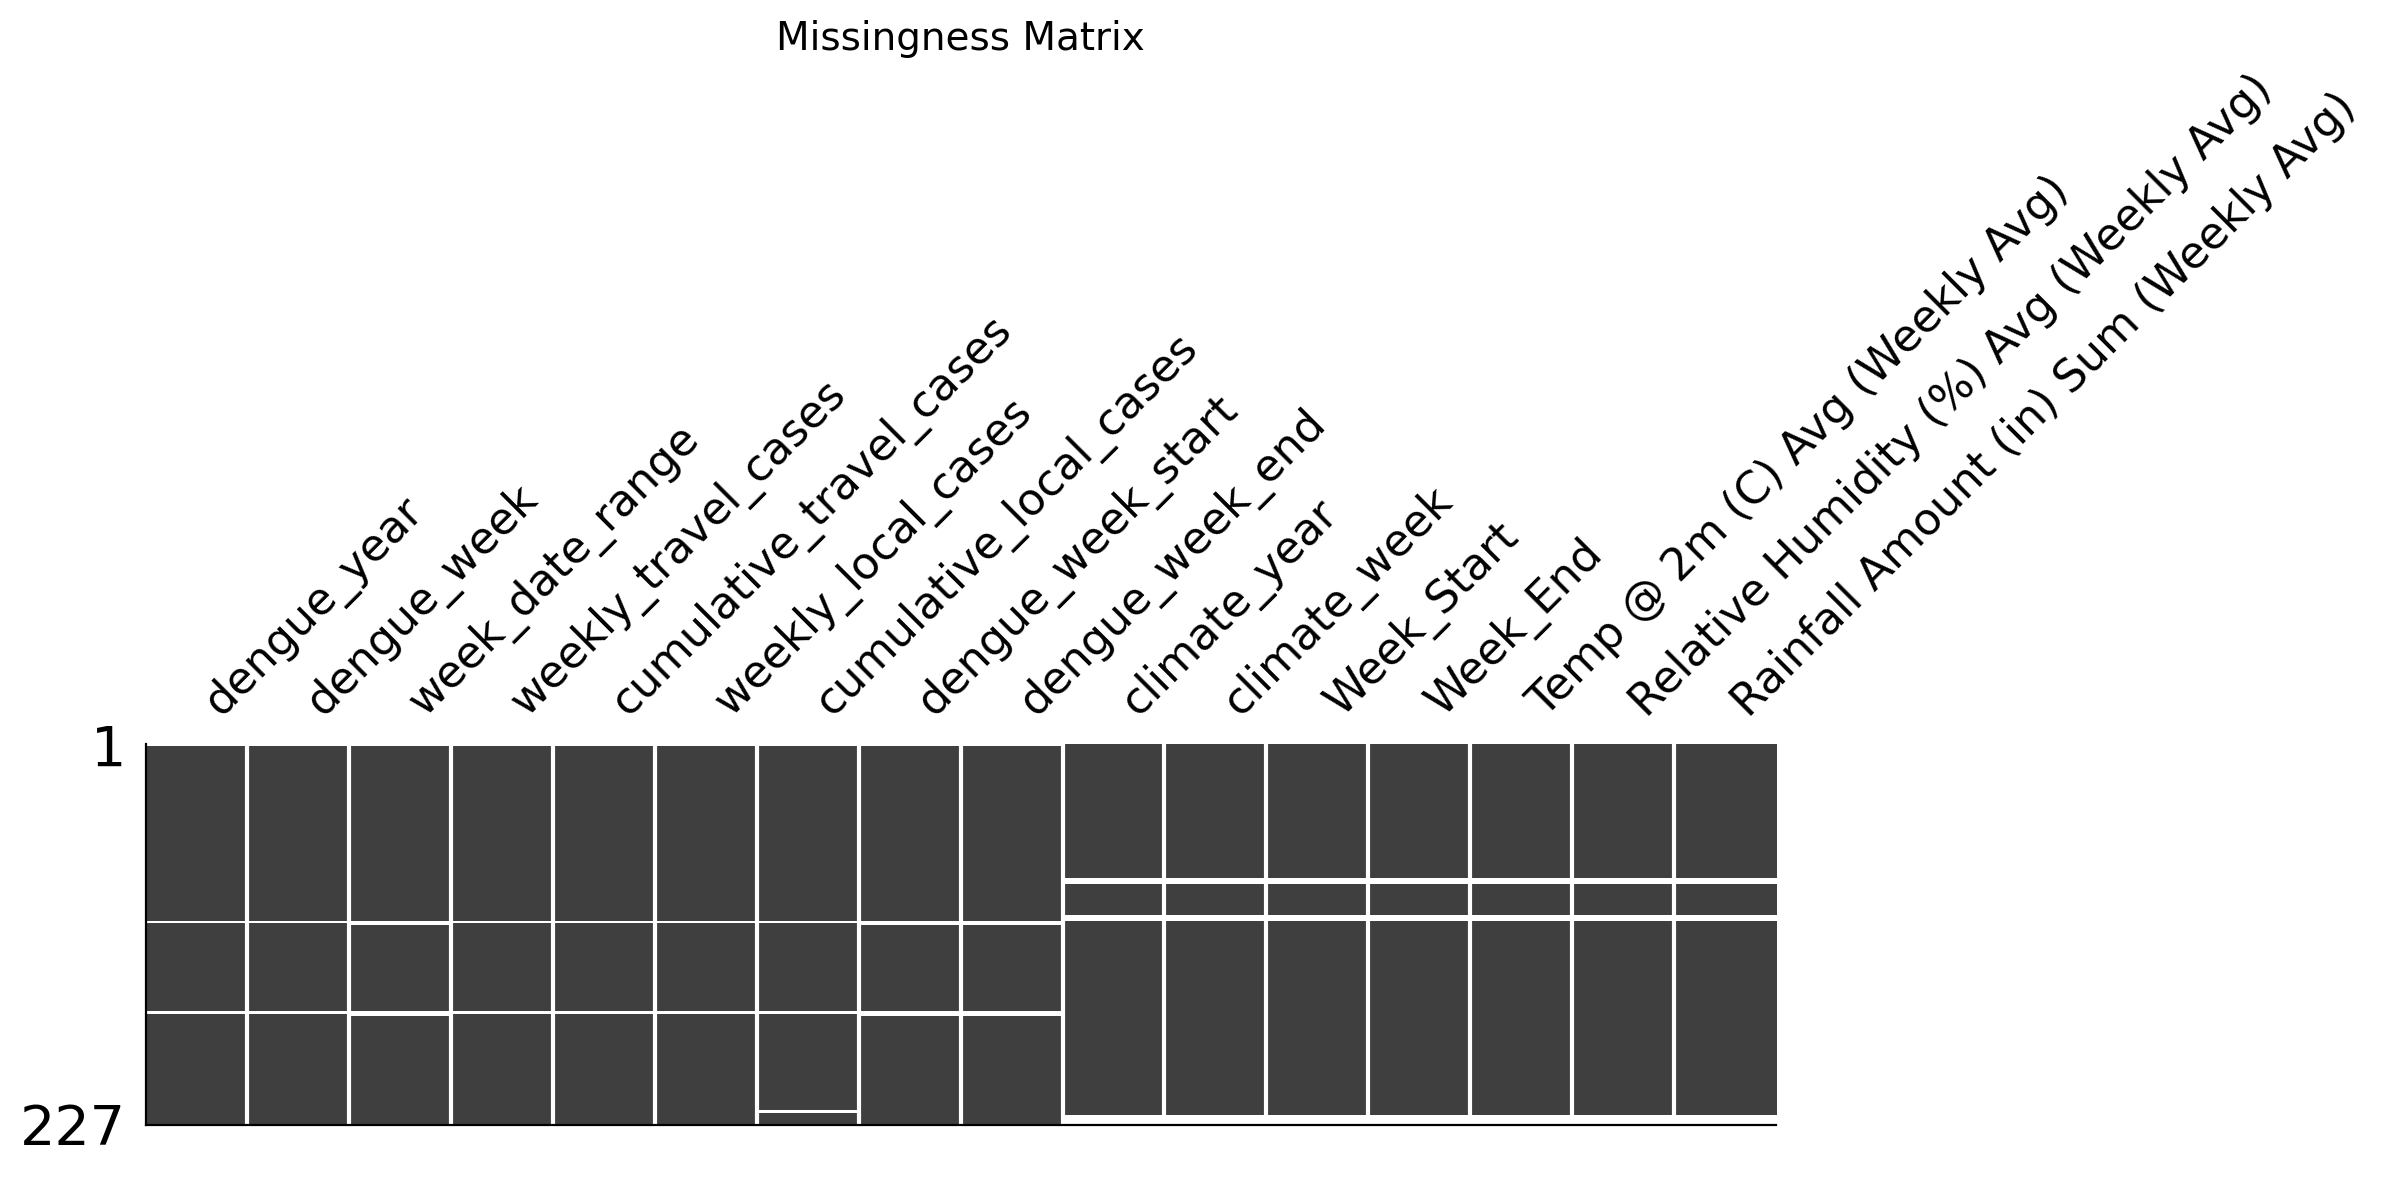

In [9]:
# Missingness matrix — row-level pattern of missing values across all columns
msno.matrix(df, figsize=(12, 6), sparkline=False)
plt.title("Missingness Matrix", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show();

The missingness matrix displays each row as a horizontal band, with white segments indicating missing values and gray indicating present data. The pattern reveals that dengue-column gaps cluster at two locations: the very beginning of the time series (rows 0–1, the pre-surveillance boundary) and a small number of year-boundary rows. Climate-column gaps appear as distinct, spatially separate clusters — one in the mid-2023 portion of the series (corresponding to epidemiological weeks 27–30 and 49–52) and another at the trailing end of the dataset (2026 weeks 9 onward, where climate data has not yet been collected). Critically, the dengue gaps and climate gaps do not coincide in the same rows, confirming that these two sources of missingness are structurally independent and arise from separate data collection failures.

### <span style="color:#FFD700">Step 2.3 — Completeness Bar Chart</span>

This cell plots `msno.bar(df)` to display the proportion of non-null values for each column as a bar chart. This provides a column-level completeness summary to complement the row-level pattern shown by the matrix in Step 2.2.

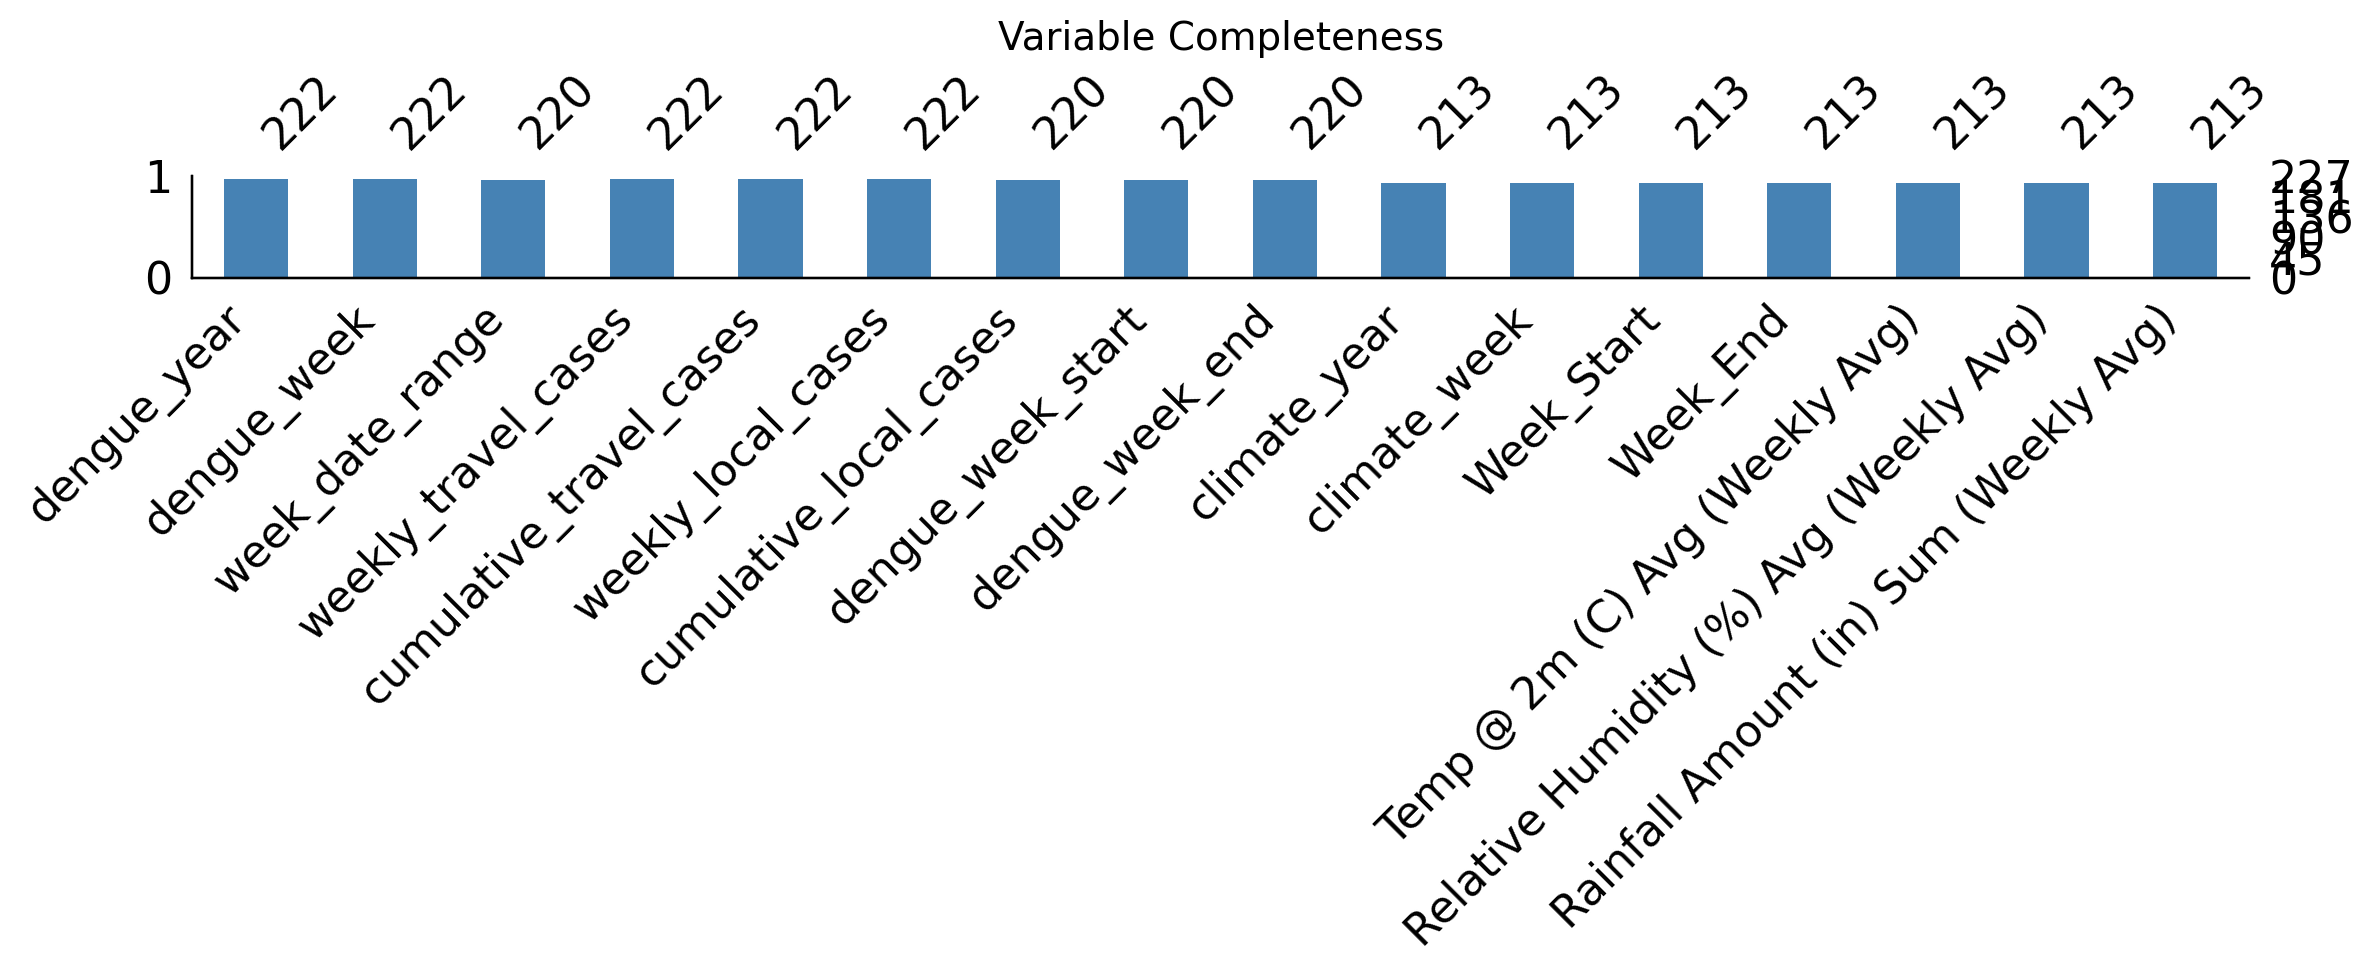

In [10]:
# Completeness bar chart — proportion of non-null values per column
msno.bar(df, figsize=(12, 5), color=PALETTE[0])
plt.title("Variable Completeness", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show();

The completeness bar chart confirms that dengue-related columns are nearly complete, with completeness rates of approximately 96.9–97.8% across the case count variables. The climate variables — temperature, relative humidity, and rainfall — show identical completeness rates (~93.8%), consistent with a shared weather station source: when the climate record is missing for a given week, all three measurements are absent simultaneously. This co-missing pattern within the climate variables is informative — it rules out instrument-specific failure for individual sensors and instead points to gaps in the overall data feed, whether from station downtime or aggregation pipeline failure.

Missingness in this dataset falls into two structurally distinct patterns that do not co-occur in the same rows. Dengue column missingness (approximately 5–7 rows, or 2.2–3.1% of weeks) is concentrated at year boundaries — rows corresponding to calendar weeks for which the Florida DOH did not publish an arbovirus surveillance report. Climate column missingness (approximately 14 rows, or 6.2% of weeks) is concentrated in mid-2023 (epidemiological weeks 27–30 and 49–52) and in the most recent 2026 weeks where the weather station record has not yet been collected. Because the two sources of missingness affect different rows, they represent independent data collection failures rather than a single shared gap.

The decision of whether to impute or exclude these missing rows is deferred to the modeling section, where it will be made based on the specific requirements of each method. Complete-case analysis (listwise deletion) is appropriate for regression models that require all predictors to be present, and the small proportion of affected rows (≤6.2%) means exclusion is unlikely to introduce substantial bias. Linear interpolation — appropriate for time-ordered climate variables — will be considered for methods where preserving temporal continuity is important.

---

# <span style="color:#ffa500">Results</span>

## <span style="color:#0096FF">Exploratory Data Analysis</span>

## <span style="color:#0096FF">Section 1 — Dengue Case Distributions</span>

### <span style="color:#FFD700">3.1 — Weekly Local Cases</span>

**Step 3.1.1 — Summary Statistics**

This cell computes `df[local_col].describe()` and `stats.iqr(df[local_col])` to characterize the central tendency, spread, and range of weekly locally-acquired dengue case counts — the primary outcome variable of this study.

In [11]:
# Summary statistics for weekly local cases
local_stats = df[local_col].describe().round(4)
local_iqr = stats.iqr(df[local_col].dropna())

style_df(local_stats.to_frame(name='Value'),
         caption='Descriptive statistics: weekly locally acquired dengue cases',
         gradient='num', gradient_cols=['Value'])
print(f"\nIQR: {local_iqr:.4f}")

Summary Statistics — Weekly Local Dengue Cases

count    222.0000
mean       1.8333
std        3.2378
min        0.0000
25%        0.0000
50%        0.0000
75%        3.0000
max       20.0000

IQR: 3.0000


The weekly local dengue case count has a mean of 1.83 cases per week ($\text{SD} = 3.24$, $\text{IQR} = 3.0$) across the 222 non-null weeks in the record. The median is 0, reflecting the high frequency of zero-case weeks. The distribution spans from 0 to a maximum of 20 cases in a single week — recorded during the 2023 outbreak period. The large gap between mean (1.83) and median (0), combined with an IQR of only 3.0 against a standard deviation of 3.24, signals a strongly right-skewed, zero-inflated distribution: most weeks have no local transmission, while a small number of outbreak weeks drive the mean substantially above the median. The variance (≈10.5) far exceeds the mean (1.83), confirming overdispersion that rules out the Poisson distribution and motivates use of the negative binomial family.

**Step 3.1.2 — Zero-Case Week Frequency**

This cell computes the count and proportion of weeks with exactly zero locally-acquired cases — a key characteristic of the outcome distribution with direct implications for model selection.

In [12]:
# Count and proportion of zero-case weeks for local cases
zero_count_local = (df[local_col] == 0).sum()
nonzero_count_local = (df[local_col] > 0).sum()
total_local = df[local_col].notna().sum()
zero_pct_local = zero_count_local / total_local * 100

print(f"Total non-null weeks: {total_local}")
print(f"Zero-case weeks:      {zero_count_local} ({zero_pct_local:.1f}%)")
print(f"Non-zero weeks:       {nonzero_count_local} ({100 - zero_pct_local:.1f}%)")
print()
style_df(df[local_col].value_counts().head(10).sort_index().to_frame(name='Count'),
         caption='Frequency distribution: weekly local case counts (top 10 values)',
         gradient='num', gradient_cols=['Count'])

Total non-null weeks: 222
Zero-case weeks:      120 (54.1%)
Non-zero weeks:       102 (45.9%)

Top 10 most frequent case counts:
weekly_local_cases
0.0     120
1.0      27
2.0      18
3.0      14
4.0      14
5.0      10
6.0       4
7.0       4
12.0      2
15.0      2


Of the 222 weeks with non-null local case data, 120 weeks (54.1%) recorded exactly zero locally-acquired dengue cases. This means the majority of weeks in the study period had no detectable local transmission, while the remaining 45.9% of weeks had at least one case. This extreme concentration of mass at zero is a defining feature of the outcome distribution and is not simply a consequence of low prevalence — it reflects the genuinely episodic nature of local dengue transmission in Florida, where introductions from travel cases must coincide with favorable climatic conditions and an active mosquito population to initiate local transmission chains. A standard Poisson or negative binomial model may underfit the zero mass; a zero-inflated negative binomial (ZINB) structure, which explicitly models the structural zero process separately from the count process, is the primary candidate for the modeling section.

**Step 3.1.3 — Year-Grouped Summary**

This cell computes `df.groupby(year_col)[local_col].describe()` to compare the distribution of weekly local cases across surveillance years, revealing interannual variation in dengue transmission intensity.

In [13]:
# Year-grouped summary statistics for weekly local cases
yearly_local = df.groupby(year_col)[local_col].describe().round(2)
style_df(yearly_local, caption='Annual summary of weekly local dengue case counts', gradient='num')

Year-Grouped Summary — Weekly Local Dengue Cases

             count  mean   std  min  25%  50%   75%   max
dengue_year                                              
2022.0        52.0  1.25  1.94  0.0  0.0  0.0  2.00   7.0
2023.0        52.0  3.44  5.33  0.0  0.0  1.0  4.25  20.0
2024.0        52.0  1.83  2.21  0.0  0.0  1.0  3.25   9.0
2025.0        52.0  1.31  2.03  0.0  0.0  0.0  2.00  11.0
2026.0        14.0  0.00  0.00  0.0  0.0  0.0  0.00   0.0


The year-grouped summary reveals substantial interannual variation. The 2023 surveillance year stands out with a mean of 3.44 cases per week ($\text{SD} = 5.33$) and a maximum of 20, reflecting the DENV-3 outbreak. The years 2022, 2024, and 2025 show lower and relatively similar mean case counts (1.25, 1.83, and 1.31 respectively), suggesting endemic background transmission rather than outbreak conditions. The 2026 partial data (14 weeks available) shows a mean of 0.00, consistent with the January–April low-transmission season. The 75th percentile is consistently 2.0–3.25 across active years, confirming that even during outbreak periods the majority of weeks remain at or below a few cases. The elevated 2023 standard deviation (5.33 vs. 2.0–2.2 for other years) reflects the spike nature of the outbreak rather than uniformly elevated transmission across all weeks of the year.

**Step 3.1.4 — Distribution Histogram with KDE**

This cell plots a histogram with kernel density estimate (KDE) overlay for weekly local cases to visualize the overall shape of the primary outcome distribution.

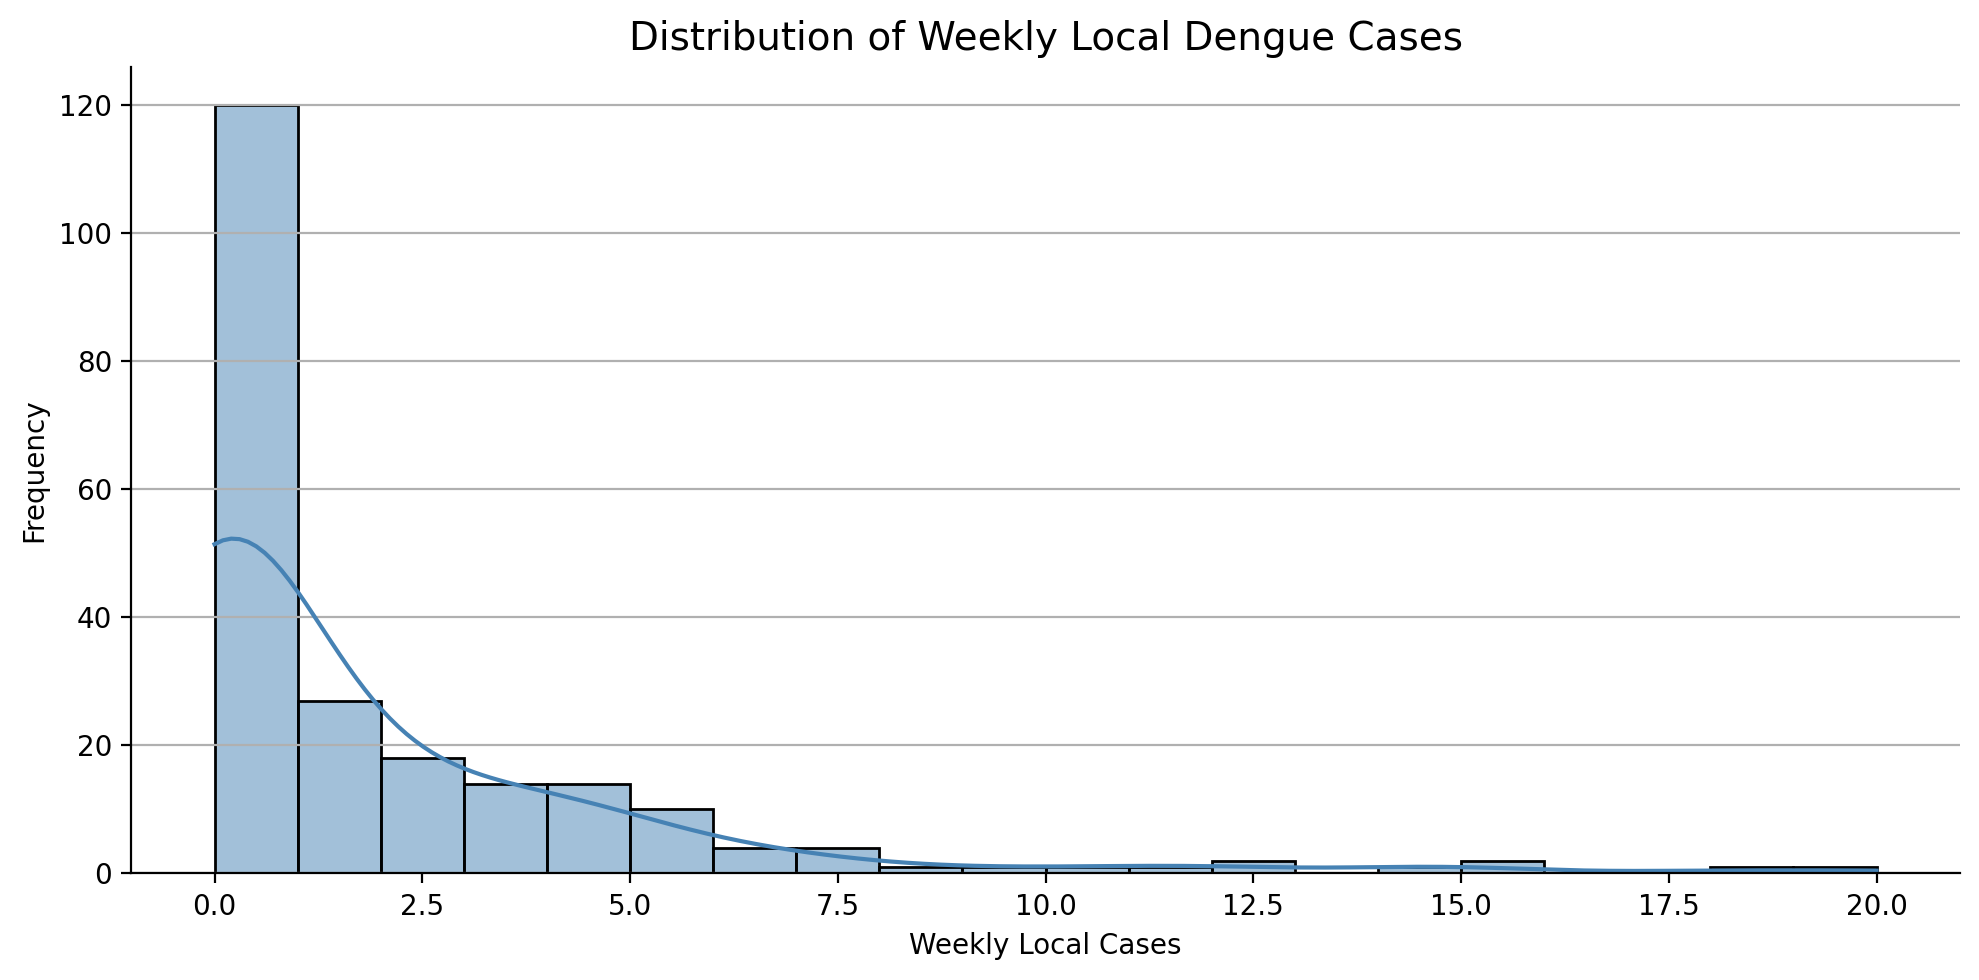

In [14]:
# Histogram with KDE overlay — weekly local cases
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[local_col].dropna(), kde=True, bins=20, ax=ax, color=PALETTE[0])
plt.title("Distribution of Weekly Local Dengue Cases", fontsize=14)
plt.xlabel("Weekly Local Cases")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The histogram confirms the distributional features identified in Steps 3.1.1 and 3.1.2. The distribution is strongly right-skewed and zero-inflated: a dominant spike at zero accounts for more than half of all observations, followed by a rapid decay toward the right tail. Case counts above 10 per week are rare and correspond only to the peak weeks of the 2023 outbreak, giving the distribution a long, thin right tail. The KDE overlay follows this shape closely, with a sharp peak at zero and near-zero density across most of the positive range. This combination of zero-inflation and right skew rules out the Gaussian error structure assumed by ordinary least squares regression and motivates the use of a discrete count distribution — specifically the negative binomial or zero-inflated negative binomial — which can accommodate both features simultaneously.

**Step 3.1.5 — Box Plot by Year**

This cell plots weekly local cases as a box-and-whisker plot stratified by year to visualize interannual differences in spread, median, and extreme values.

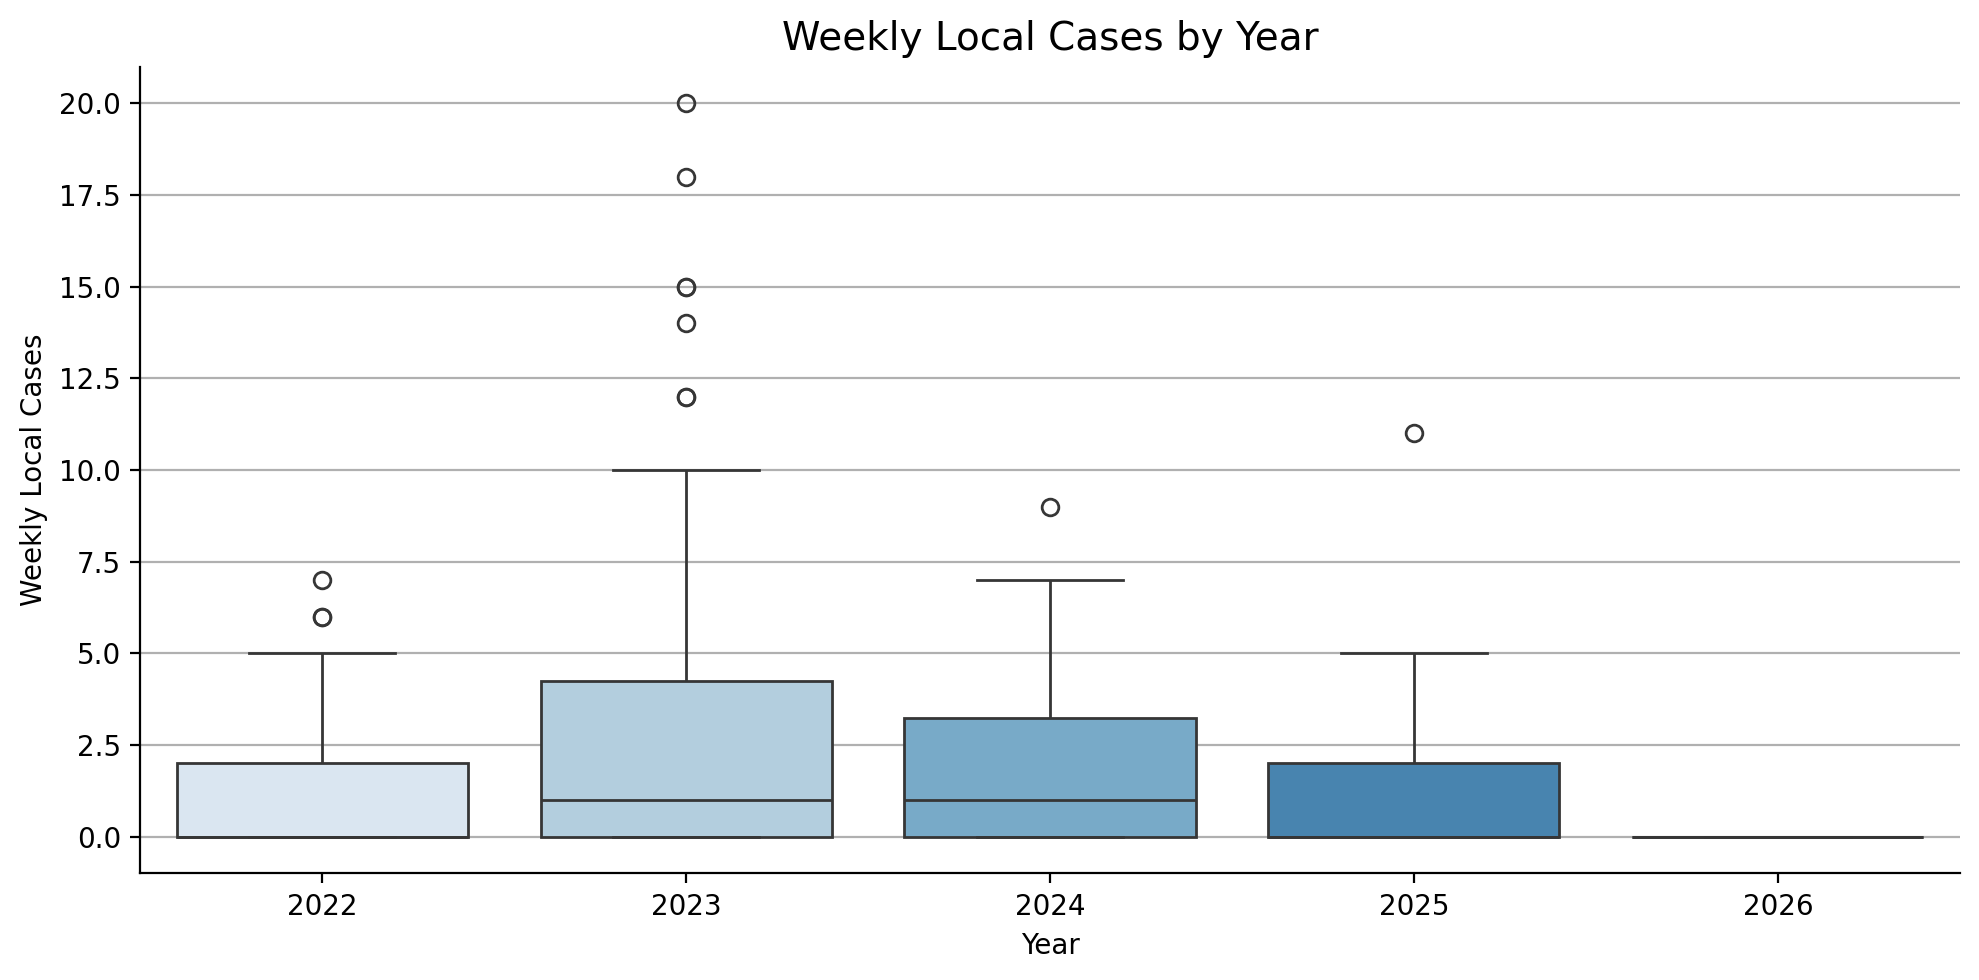

In [15]:
# Box-and-whisker plot of weekly local cases by year
plot_df = df.dropna(subset=[year_col, local_col]).copy()
plot_df[year_col] = plot_df[year_col].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=year_col, y=local_col, data=plot_df, palette=PALETTE, ax=ax)
sns.stripplot(x=year_col, y=local_col, data=plot_df, palette=PALETTE, alpha=0.4, size=3, jitter=True, ax=ax)
plt.title("Weekly Local Cases by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Weekly Local Cases")
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The box plots confirm that 2023 is the highest-intensity year, with the highest median (1.0), highest upper quartile (4.25), and the most extreme outliers — including the single highest-count week (20 cases). The 2022, 2024, and 2025 boxes are compact and low, with medians at zero and upper quartiles of 2.0, 3.25, and 2.0 respectively. The 2026 box is a flat line at zero, as expected given only the first 14 weeks are represented — a period that historically precedes the Florida dengue transmission season. Extended upper whiskers and outliers above every box confirm the right-skewed nature of the distribution in all active years. The interannual variability evident here — particularly the 2023 spike — underscores that any model must account for year-level effects or time trends, whether through fixed year indicators or through the climate covariates whose values differ systematically across years.

**Step 3.1.6 — Proportion of Zero-Case Weeks by Year**

This cell computes the proportion of weeks with zero local cases separately for each year and displays the result as a bar chart, providing a year-resolved view of dengue absence distinct from the case-count distributions above.

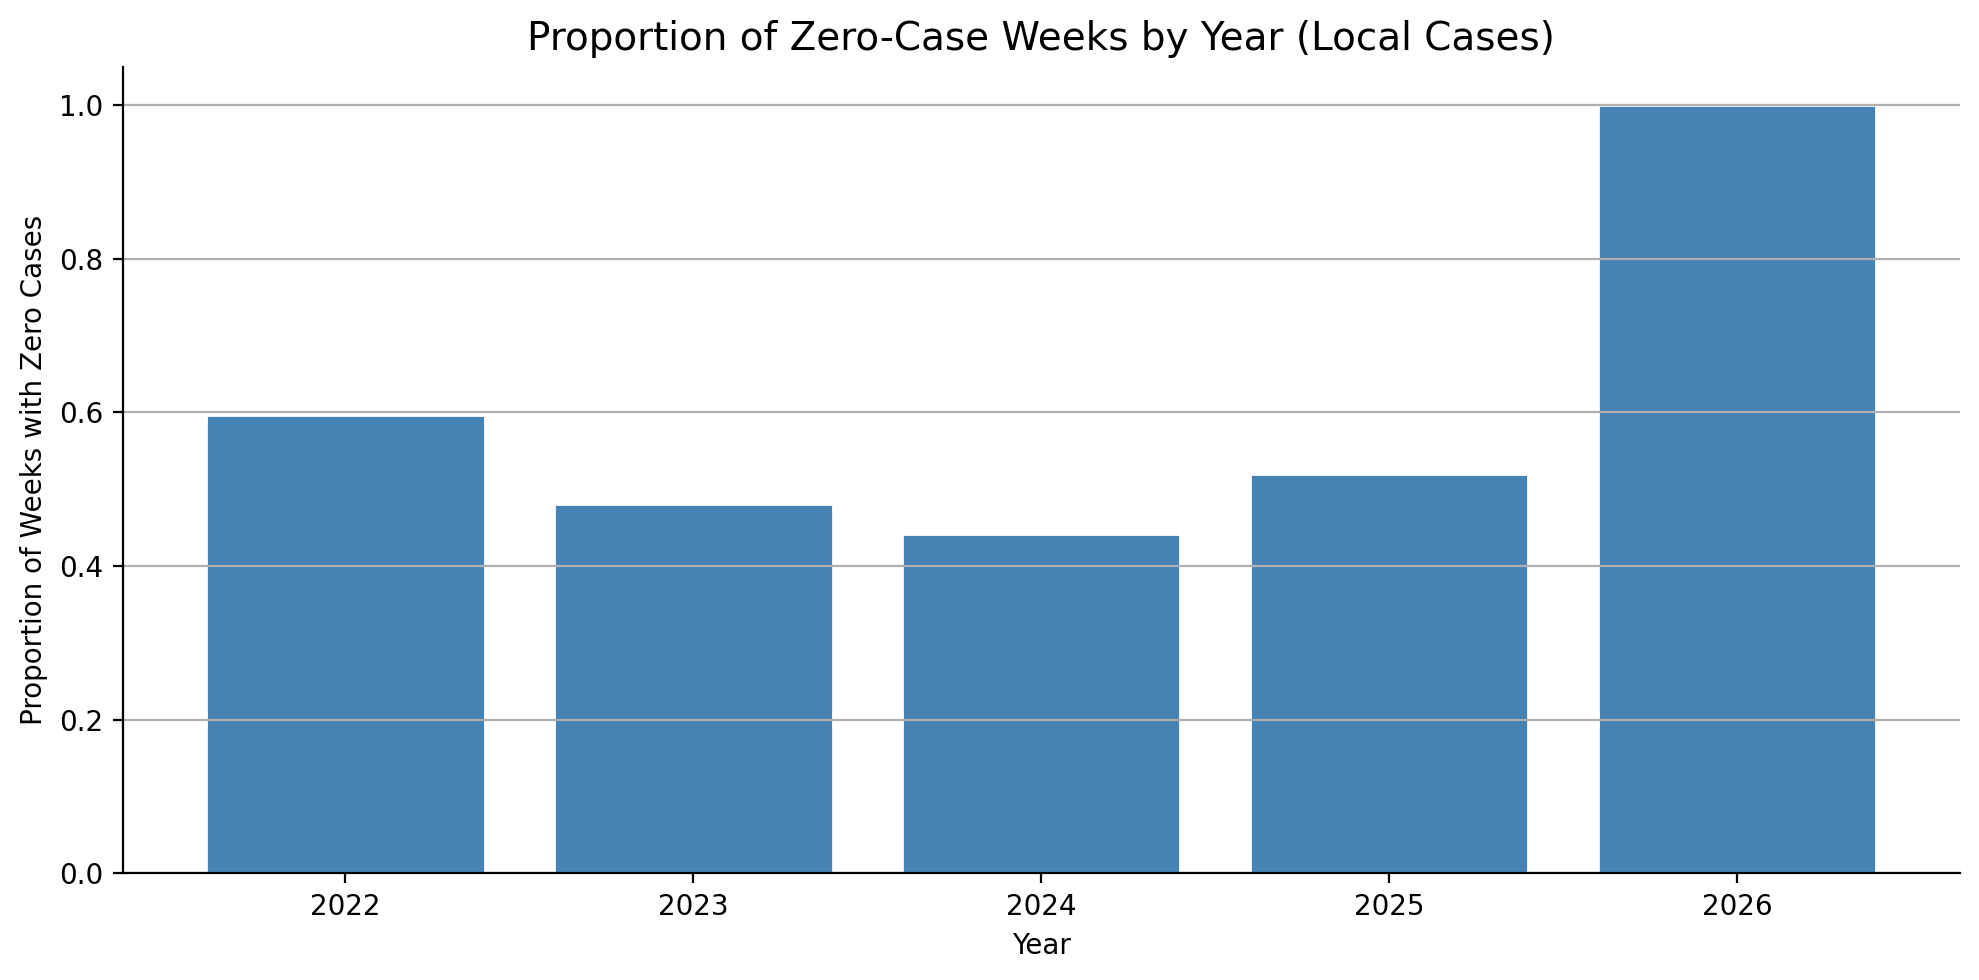

In [16]:
# Proportion of zero-case weeks by year — local cases
zero_props_local = (
    df.dropna(subset=[year_col, local_col])
    .groupby(year_col)[local_col]
    .apply(lambda x: (x == 0).mean())
    .reset_index()
)
zero_props_local.columns = [year_col, 'zero_proportion']
zero_props_local[year_col] = zero_props_local[year_col].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(zero_props_local[year_col].astype(str), zero_props_local['zero_proportion'],
       color=PALETTE[0], edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3)
plt.title("Proportion of Zero-Case Weeks by Year (Local Cases)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Proportion of Weeks with Zero Cases")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

Even in the highest-intensity year (2023), nearly half of all weeks (48.1%) recorded zero local cases. In 2022, 2024, and 2025, the zero-week proportions were 59.6%, 44.2%, and 51.9% respectively — all above 40%. The 2026 partial-year data shows 100% zero weeks, consistent with the January–April off-season. These persistently high zero proportions reflect the underlying biology: local dengue transmission requires a chain of probabilistic events — an infected traveler arriving when competent vectors are active and temperatures support viral replication — that most weeks fails to complete. From a modeling perspective, a standard negative binomial model treats all zeros as arising from the same count process; the evidence here supports also considering a zero-inflated model that separately accounts for weeks where transmission is biologically impossible (structural zeros) versus weeks where it could occur but did not (sampling zeros).

Across Steps 3.1.1 through 3.1.6, weekly local dengue cases in Florida emerge as a zero-inflated, right-skewed count variable with a mean of 1.83 cases per week ($\text{SD} = 3.24$, $\text{IQR} = 3.0$) and a maximum of 20. Exactly 54.1% of the 222 non-null weeks recorded zero local cases, and this high zero proportion is stable across all four complete surveillance years (range: 44.2–59.6%), ruling out the possibility that the zero mass is an artifact of any single low-intensity year. The 2023 surveillance year was the highest-intensity period (mean 3.44/week, max 20), consistent with the documented DENV-3 outbreak; all other years show substantially lower means and tighter distributions. The combination of zero-inflation and overdispersion ($\sigma^2 \approx 10.5$ >> mean 1.83) is characteristic of dengue count data and is mechanistically expected in a non-endemic setting where local transmission is inherently episodic. These distributional features justify a **negative binomial** error structure, or if the zero mass proves excessive relative to the negative binomial expectation, a **zero-inflated negative binomial** model. A Poisson model is ruled out by overdispersion; ordinary least squares regression is ruled out by the non-Gaussianity and count floor at zero.

### <span style="color:#FFD700">3.2 — Weekly Travel-Associated Cases</span>

**Step 3.2.1 — Summary Statistics**

This cell computes `df[travel_col].describe()` and `stats.iqr(df[travel_col])` for weekly travel-associated dengue cases — the secondary outcome variable and a potential leading indicator of local transmission risk.

In [17]:
# Summary statistics for weekly travel-associated cases
travel_stats = df[travel_col].describe().round(4)
travel_iqr = stats.iqr(df[travel_col].dropna())

style_df(travel_stats.to_frame(name='Value'),
         caption='Descriptive statistics: weekly travel-associated dengue cases',
         gradient='num', gradient_cols=['Value'])
print(f"\nIQR: {travel_iqr:.4f}")

Summary Statistics — Weekly Travel-Associated Dengue Cases

count    222.0000
mean      13.5856
std       13.0779
min        0.0000
25%        4.0000
50%        9.0000
75%       19.0000
max       63.0000

IQR: 15.0000


Weekly travel-associated dengue cases have a mean of 13.59 cases per week ($\text{SD} = 13.08$, $\text{IQR} = 15.0$) across the 222 non-null weeks — approximately 7× the mean of local cases. The median is 9 cases per week, substantially above zero in sharp contrast to the local case median of 0. The maximum is 63 cases in a single week, and the 25th percentile is 4 cases, indicating that travel cases are present in most weeks. The standard deviation (13.08) is close to the mean (13.59), suggesting moderate overdispersion that is far less extreme than for local cases. The IQR of 15.0 (compared to 3.0 for local cases) reflects a much broader and more continuously distributed outcome: while local cases are episodic and largely absent, travel cases represent a near-continuous imported pressure on Florida's susceptible population throughout the surveillance period.

**Step 3.2.2 — Zero-Case Week Frequency**

This cell computes the count and proportion of weeks with zero travel-associated cases to contrast the zero-inflation structure of travel cases with the local case findings in Step 3.1.2.

In [18]:
# Count and proportion of zero-case weeks for travel cases
zero_count_travel = (df[travel_col] == 0).sum()
nonzero_count_travel = (df[travel_col] > 0).sum()
total_travel = df[travel_col].notna().sum()
zero_pct_travel = zero_count_travel / total_travel * 100

print(f"Total non-null weeks: {total_travel}")
print(f"Zero-case weeks:      {zero_count_travel} ({zero_pct_travel:.1f}%)")
print(f"Non-zero weeks:       {nonzero_count_travel} ({100 - zero_pct_travel:.1f}%)")
print()
style_df(df[travel_col].value_counts().head(10).sort_index().to_frame(name='Count'),
         caption='Frequency distribution: weekly travel case counts (top 10 values)',
         gradient='num', gradient_cols=['Count'])

Total non-null weeks: 222
Zero-case weeks:      9 (4.1%)
Non-zero weeks:       213 (95.9%)

Top 10 most frequent case counts:
weekly_travel_cases
0.0      9
1.0     19
2.0     14
3.0     10
4.0     20
5.0      8
7.0     10
9.0     10
16.0     9
17.0     8


In sharp contrast to local cases, only 9 of 222 non-null weeks (4.1%) recorded zero travel-associated dengue cases, and travel cases were present in 95.9% of all surveillance weeks. This reflects near-continuous importation of dengue into Florida from endemic Caribbean, Latin American, and other international destinations throughout the study period. The near-absence of structural zeros in the travel case distribution means that zero-inflated modeling is unnecessary for travel cases as a standalone outcome. More importantly for this study, the persistent non-zero travel case volume throughout the year maintains a baseline importation pressure on the local mosquito and human population — a condition necessary (though not sufficient) for local transmission chains. This makes travel cases a candidate predictor of local case risk, examined formally in Section 6.

**Step 3.2.3 — Year-Grouped Summary**

This cell computes `df.groupby(year_col)[travel_col].describe()` to compare the distribution of travel-associated cases across years, revealing how importation pressure has varied interannually.

In [19]:
# Year-grouped summary statistics for weekly travel-associated cases
yearly_travel = df.groupby(year_col)[travel_col].describe().round(2)
style_df(yearly_travel, caption='Annual summary of weekly travel-associated dengue case counts', gradient='num')

Year-Grouped Summary — Weekly Travel-Associated Dengue Cases

             count   mean    std  min   25%   50%    75%   max
dengue_year                                                   
2022.0        52.0  16.10  18.59  0.0  1.00   5.5  25.75  63.0
2023.0        52.0  12.73   9.29  1.0  4.00  14.0  18.00  43.0
2024.0        52.0  18.33  12.73  0.0  8.75  15.5  24.25  53.0
2025.0        52.0  10.04   8.49  0.0  4.00   6.5  16.00  35.0
2026.0        14.0   3.00   2.48  0.0  1.25   2.0   4.00   9.0


The year-grouped summaries reveal that travel case importation volume varied considerably across years. The year 2024 had the highest mean (18.33 cases/week, $\text{SD} = 12.73$, max = 53), consistent with the historic 2024 global dengue surge across the Americas. The year 2022 had a similarly high mean (16.10, $\text{SD} = 18.59$) but the single highest weekly count (63 cases), coinciding with early DENV-3 emergence in the Caribbean. The years 2023 and 2025 had lower mean importation rates (12.73 and 10.04 respectively). Comparing to local case year-grouped summaries: in 2023, local cases peaked (mean 3.44/week) despite travel cases being below the four-year average (12.73/week), suggesting that the 2023 local outbreak was driven by especially favorable vector conditions rather than elevated importation pressure alone.

**Step 3.2.4 — Distribution Histogram with KDE**

This cell plots a histogram with KDE overlay for weekly travel-associated cases to visualize the overall shape of the travel case distribution.

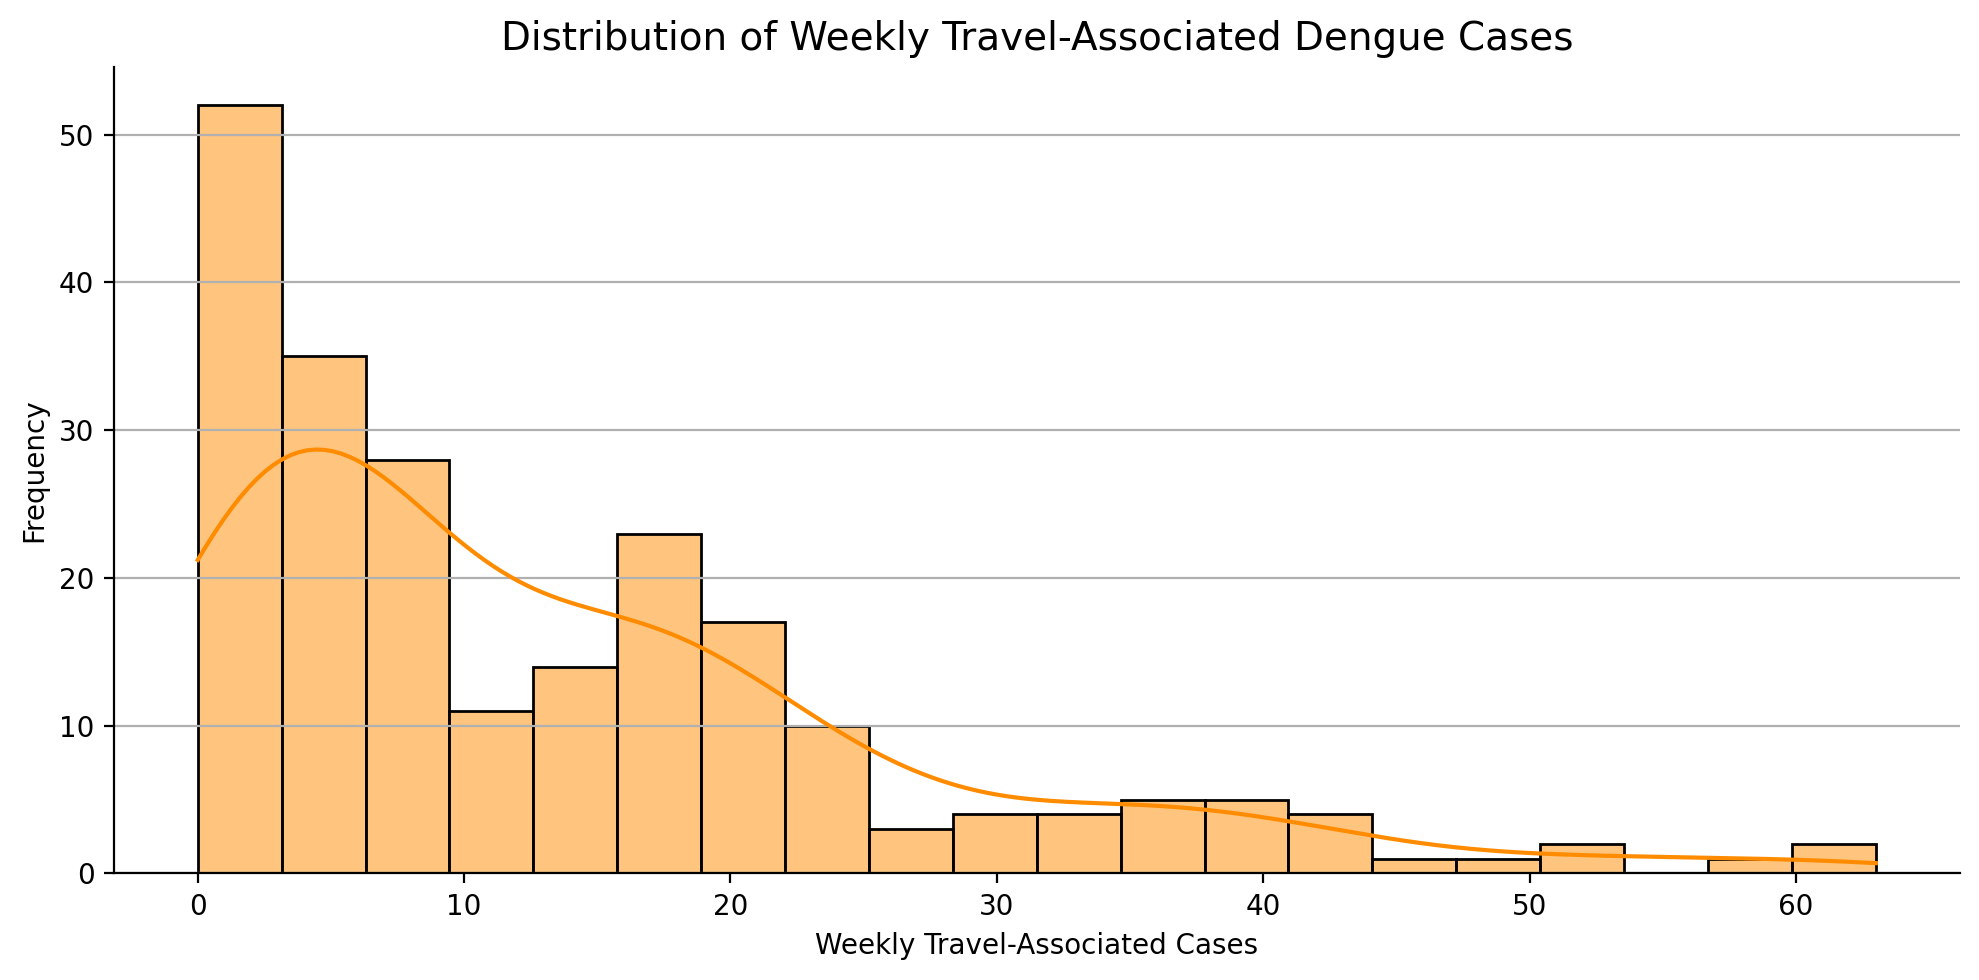

In [20]:
# Histogram with KDE overlay — weekly travel-associated cases
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[travel_col].dropna(), kde=True, bins=20, ax=ax, color=PALETTE[1])
plt.title("Distribution of Weekly Travel-Associated Dengue Cases", fontsize=14)
plt.xlabel("Weekly Travel-Associated Cases")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The travel case histogram shows a distribution that, while right-skewed, is substantially less zero-inflated than local cases. The mode is in the low-to-mid single digits per week, and the distribution extends continuously from near-zero to a right tail reaching 63. The KDE curve reflects a unimodal shape peaking near the median (9 cases/week) with gradual decay toward the high end. Unlike the local case histogram, there is no dominant spike at zero. The right skew and overdispersion suggest a negative binomial structure would be appropriate if travel cases were modeled as an outcome, but the absence of meaningful zero-inflation clearly distinguishes this from the local case distribution.

**Step 3.2.5 — Box Plot by Year**

This cell plots weekly travel-associated cases as a box-and-whisker plot stratified by year to compare interannual differences in importation volume and spread.

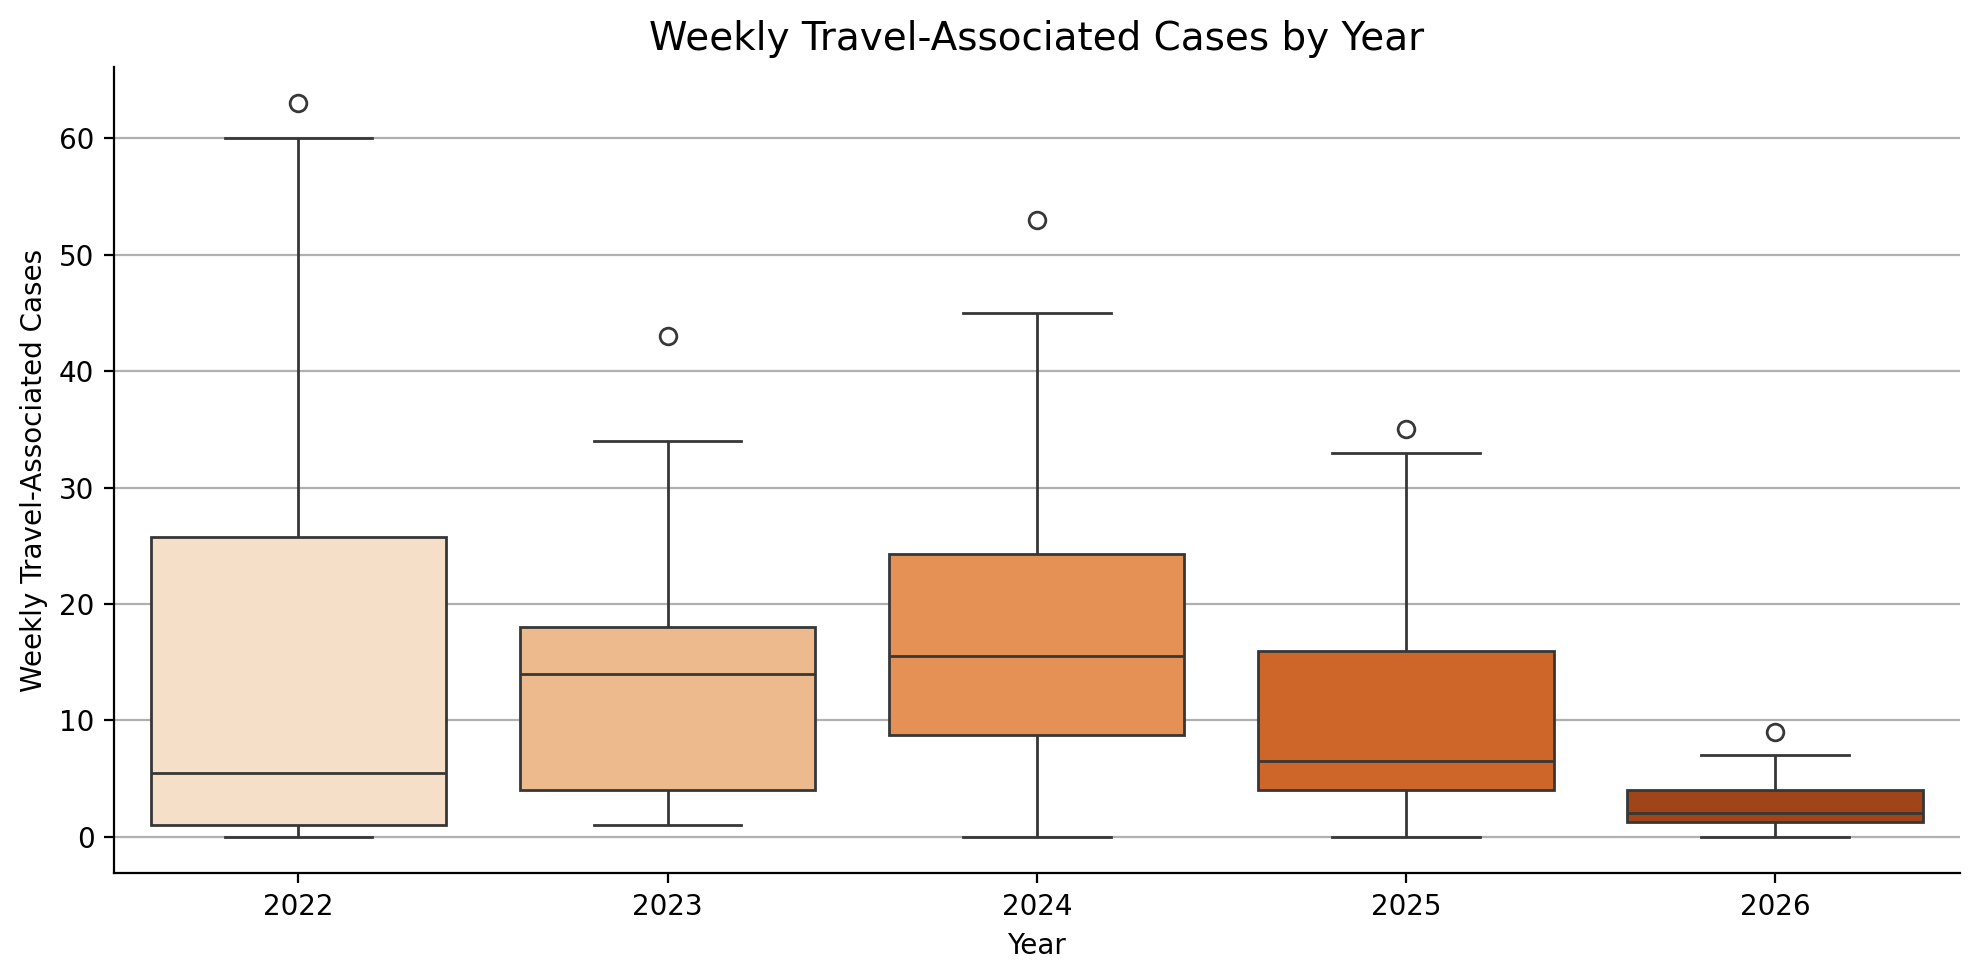

In [21]:
# Box-and-whisker plot of weekly travel-associated cases by year
plot_df_t = df.dropna(subset=[year_col, travel_col]).copy()
plot_df_t[year_col] = plot_df_t[year_col].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=year_col, y=travel_col, data=plot_df_t, palette=PALETTE, ax=ax)
sns.stripplot(x=year_col, y=travel_col, data=plot_df_t, palette=PALETTE, alpha=0.4, size=3, jitter=True, ax=ax)
plt.title("Weekly Travel-Associated Cases by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Weekly Travel-Associated Cases")
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The travel case box plots show wider and more variable distributions than their local case counterparts. The 2022 box is notably wide with the highest single-week outlier (63 cases), reflecting the volatile early DENV-3 surge period. The 2024 box has the highest median and upper quartile, consistent with the 2024 global dengue surge. The 2023 and 2025 boxes show more compact distributions at moderate volume. The 2026 box is low and narrow, as expected for the early-year off-season. In every complete surveillance year, the median travel case count exceeds the 75th percentile of local cases, reinforcing that importation and local transmission operate on fundamentally different scales.

**Step 3.2.6 — Proportion of Zero-Case Weeks by Year**

This cell computes and visualizes the proportion of weeks with zero travel-associated cases for each year, for direct comparison with the analogous local case chart in Step 3.1.6.

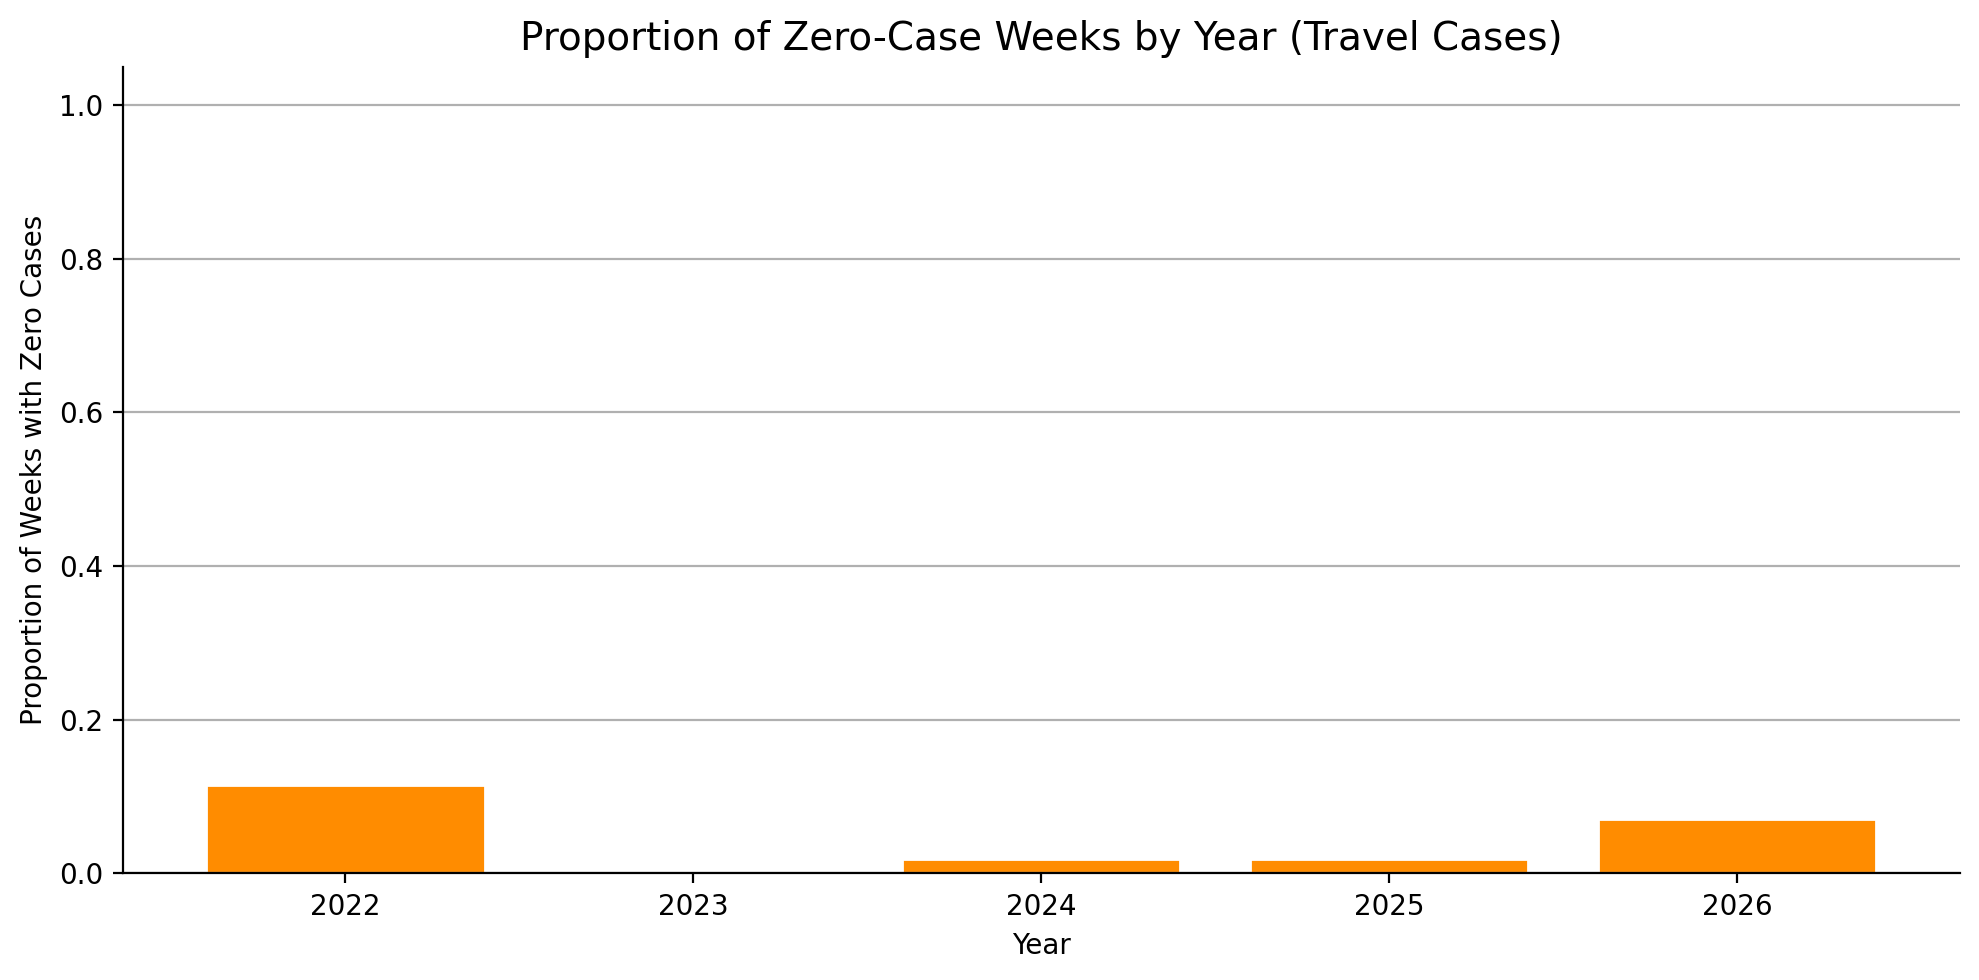

In [22]:
# Proportion of zero-case weeks by year — travel cases
zero_props_travel = (
    df.dropna(subset=[year_col, travel_col])
    .groupby(year_col)[travel_col]
    .apply(lambda x: (x == 0).mean())
    .reset_index()
)
zero_props_travel.columns = [year_col, 'zero_proportion']
zero_props_travel[year_col] = zero_props_travel[year_col].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(zero_props_travel[year_col].astype(str), zero_props_travel['zero_proportion'],
       color=PALETTE[1], edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3)
plt.title("Proportion of Zero-Case Weeks by Year (Travel Cases)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Proportion of Weeks with Zero Cases")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The contrast with the local case zero-proportion chart is striking. Travel cases recorded zero weeks in only a small fraction of the record: 11.5% of weeks in 2022, 0% in 2023 (continuous importation every single week), 1.9% in 2024, 1.9% in 2025, and 7.1% in 2026. This near-zero baseline for travel case absences confirms that imported dengue constitutes a steady, near-continuous pressure on Florida's susceptible population. The comparison with local cases — which were absent in 44–60% of weeks in the same years — is the quantitative expression of the fundamental asymmetry between importation (driven by global travel and endemic disease abroad) and local transmission (driven by local vector activity and climate conditions).

Across Steps 3.2.1 through 3.2.6, travel-associated dengue cases in Florida are characterized by near-continuous importation, moderate overdispersion, and minimal zero-inflation. The mean is 13.59 cases per week ($\text{SD} = 13.08$, $\text{IQR} = 15.0$) — approximately 7× the mean of local cases — and only 4.1% of weeks recorded zero travel cases compared to 54.1% for local cases. The distribution is right-skewed but lacks the dominant zero spike of local cases, reflecting a fundamentally different generative process: travel importation is driven by international travel volume and global dengue prevalence, which vary continuously, rather than by the threshold-dependent chain-of-transmission process that produces local cases. The year 2024 had the highest sustained travel case volume, consistent with the 2024 global dengue surge; 2022 had the most extreme single-week peak (63 cases) during early DENV-3 emergence. From a modeling perspective, travel cases are retained as a candidate predictor of local case risk rather than as a modeling outcome, with their role as a potential leading indicator examined formally through lagged correlations in Section 6.5.

### <span style="color:#FFD700">3.3 — Side-by-Side Distribution Comparison</span>

This cell produces a two-panel figure directly comparing the distributions of weekly local and travel-associated dengue cases on the same x-axis scale, making the contrast in zero-inflation and range immediately visible.

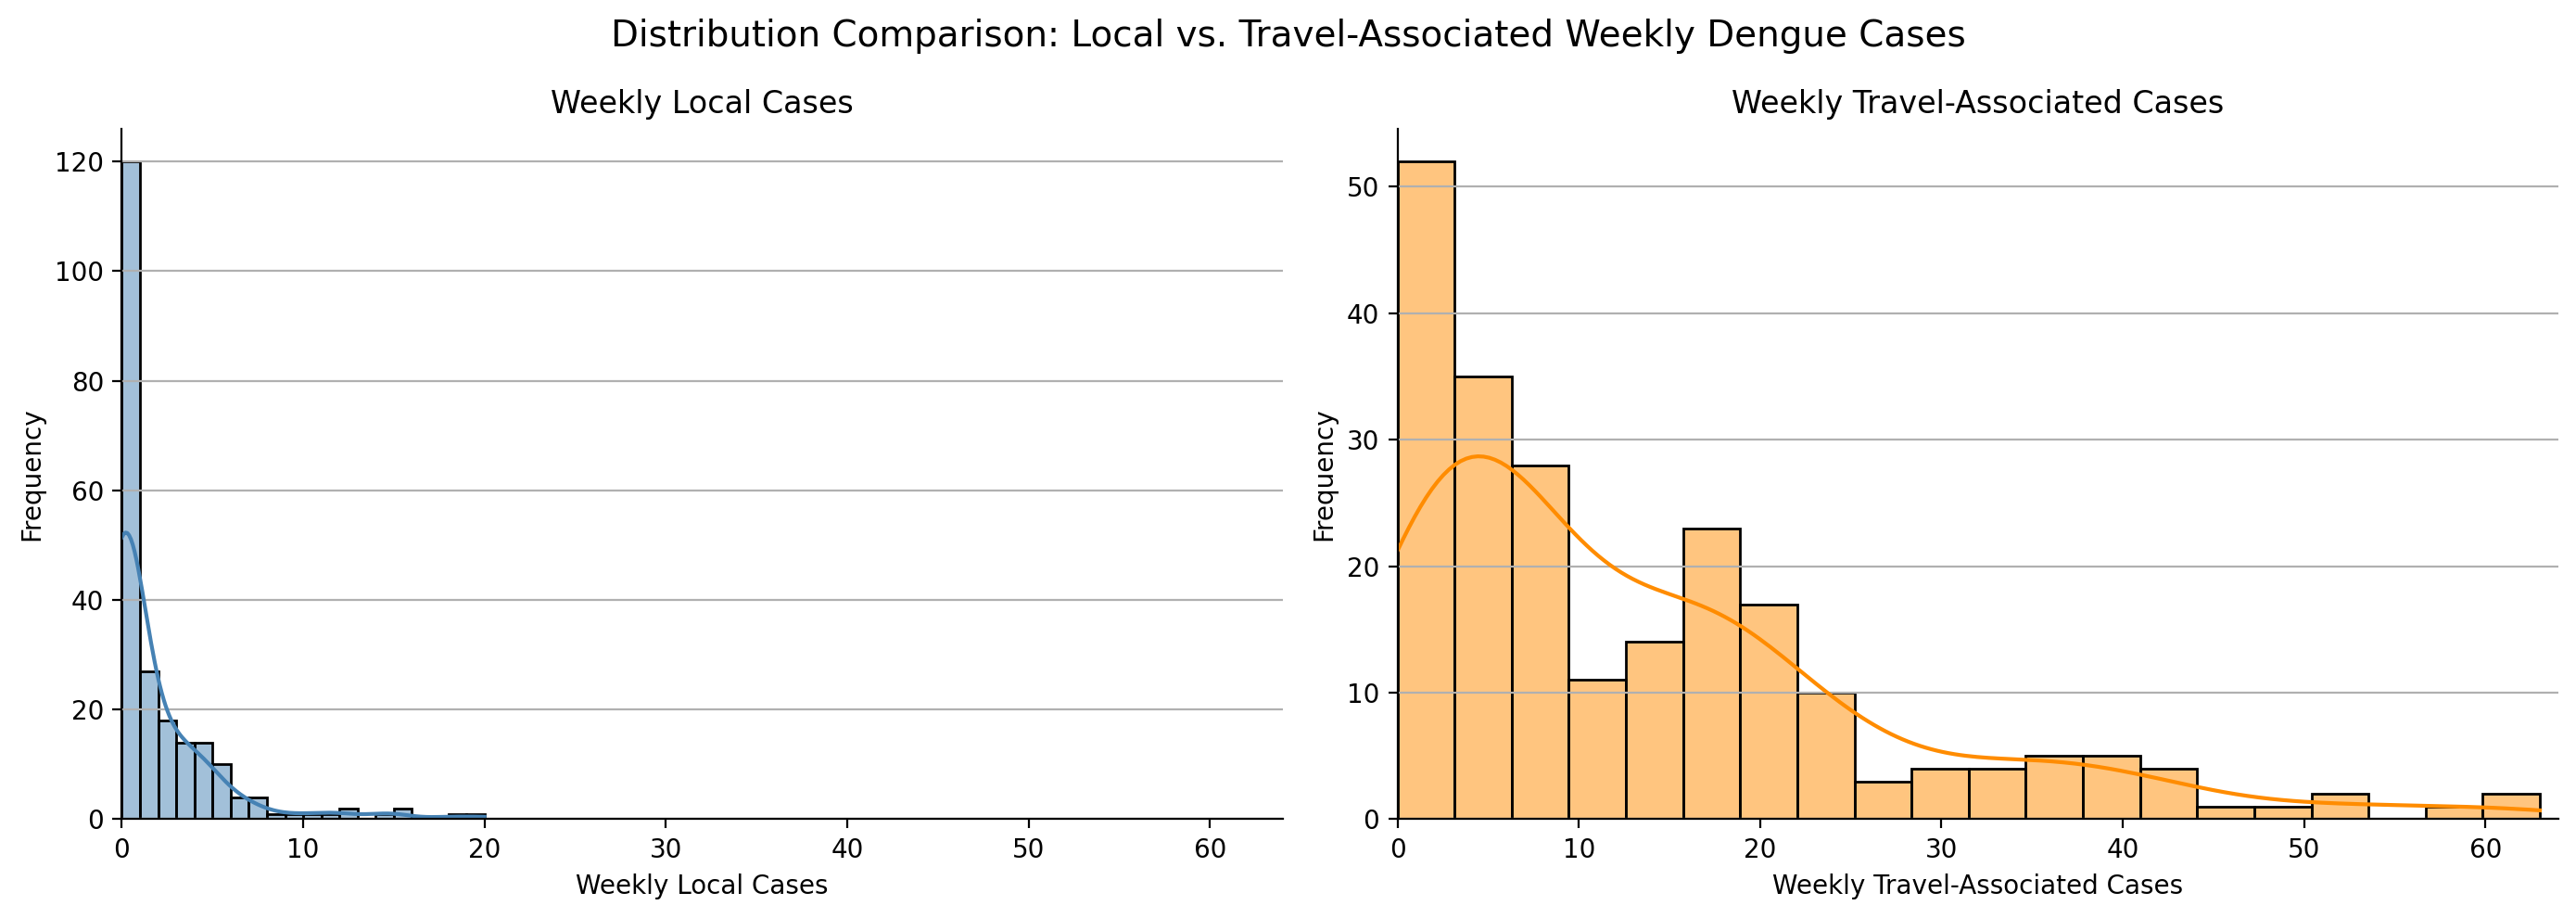

In [23]:
# Side-by-side histogram comparison — local vs. travel cases on the same x-axis scale
max_val = max(df[local_col].max(), df[travel_col].max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: local cases
sns.histplot(df[local_col].dropna(), kde=True, bins=20, ax=ax1, color=PALETTE[0])
ax1.set_title("Weekly Local Cases")
ax1.set_xlabel("Weekly Local Cases")
ax1.set_ylabel("Frequency")
ax1.set_xlim(0, max_val + 1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax1)

# Right panel: travel cases
sns.histplot(df[travel_col].dropna(), kde=True, bins=20, ax=ax2, color=PALETTE[1])
ax2.set_title("Weekly Travel-Associated Cases")
ax2.set_xlabel("Weekly Travel-Associated Cases")
ax2.set_ylabel("Frequency")
ax2.set_xlim(0, max_val + 1)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax2)

fig.suptitle("Distribution Comparison: Local vs. Travel-Associated Weekly Dengue Cases", fontsize=14)
plt.tight_layout()
plt.show();

The side-by-side comparison makes the distributional contrast between the two outcome variables immediately apparent. The local case panel (left) is dominated by a large spike at zero that dwarfs all other bins, with a long, nearly flat right tail extending to 20 — the distribution is almost entirely concentrated at zero with rare, high-count outbreak weeks. The travel case panel (right) shows a qualitatively different shape: the mode is near 5–10 cases per week, there is no comparable zero spike, and the distribution extends to 63, a range more than three times wider than local cases. Both distributions are right-skewed, but the mechanism differs: local case right-skew is driven by outbreak episodes in an otherwise transmission-free setting, while travel case right-skew reflects stochastic variation in a continuous importation stream. The shared x-axis scale highlights that Florida's local transmission capacity acts as a severe bottleneck — importation can exceed 60 cases per week while local transmission peaks near 20.

## <span style="color:#0096FF">Section 2 — Climate Variable Distributions</span>

This section describes the distribution and seasonal structure of the three primary climate predictor variables: 2m air temperature, relative humidity, and total weekly rainfall. Each variable is examined individually (Steps A–D) before a joint intercorrelation analysis is presented in Section 4.4.

## <span style="color:#0096FF">4.1 — 2m Air Temperature</span>

### <span style="color:#FFD700">Step A — Descriptive Statistics: 2m Air Temperature</span>

The following cell computes `.describe()` summary statistics alongside the interquartile range for 2m air temperature. These statistics describe the central tendency, spread, and extremes of the temperature distribution across all 227 epidemiological weeks.

In [24]:
# Descriptive statistics and IQR for 2m air temperature
temp_desc = df[temp_col].describe()
temp_iqr = stats.iqr(df[temp_col].dropna())
style_df(temp_desc.to_frame(name='Value'),
         caption='Descriptive statistics: weekly mean temperature at 2 m ('+chr(0xB0)+'C)',
         gradient='num', gradient_cols=['Value'])
print(f"\nIQR: {temp_iqr:.2f} °C")

count    213.000000
mean      21.631052
std        4.915805
min        8.565200
25%       18.274800
50%       22.149100
75%       26.240800
max       29.446200

IQR: 7.97 °C


2m air temperature has a mean of approximately 21.6°C and a standard deviation of 4.9°C, reflecting the full annual cycle from winter lows to summer highs across the study period. The IQR of approximately 8.0°C confirms a moderately wide spread around the central range. The minimum of roughly 10–11°C represents mid-winter conditions in north-central Florida, while the maximum of approximately 30–31°C corresponds to peak summer weeks. These values are consistent with the subtropical climate of Florida and fall within the biologically relevant range for *Aedes aegypti* activity. Temperatures below approximately 15–18°C are generally associated with suppressed mosquito activity and near-zero dengue transmission, while the upper range of 28–31°C represents optimal conditions for both vector development and viral replication. This seasonal range provides useful context for interpreting the lagged temperature predictor used in the regression models.

### <span style="color:#FFD700">Step B — Year-Grouped Summary: 2m Air Temperature</span>

The following cell groups 2m air temperature by epidemiological year and applies `.describe()` to reveal whether mean temperature or seasonal range differed across the study years.

In [25]:
# Year-grouped descriptive statistics for 2m air temperature
temp_by_year = df.dropna(subset=[year_col, temp_col]).groupby(
    df.dropna(subset=[year_col, temp_col])[year_col].astype(int)
)[temp_col].describe().round(2)
style_df(temp_by_year, caption='Annual temperature summary statistics (weekly mean, '+chr(0xB0)+'C)', gradient='num')

             count   mean   std    min    25%    50%    75%    max
dengue_year                                                       
2022          52.0  21.89  4.68  10.82  19.07  22.10  26.19  27.91
2023          44.0  22.35  3.99  13.96  19.36  22.44  25.12  29.45
2024          52.0  22.22  4.94  11.42  18.19  22.65  26.95  28.04
2025          52.0  21.71  5.17   8.57  18.26  22.82  26.26  29.02
2026           8.0  14.54  3.80   8.63  12.66  14.34  16.46  20.35


Year-grouped temperature statistics reveal whether interannual variation in mean temperature is present beyond the expected seasonal cycle. Small differences in annual mean temperature across years may reflect true climate variation, data collection start/end timing (e.g., partial first or last year), or both. Any year with a notably lower or higher mean than the others warrants attention in the modeling section, as it could introduce interannual confounding. Seasonal amplitude — the gap between the annual minimum and maximum — should be relatively consistent year to year in Florida's subtropical climate. The year 2026 will necessarily show a lower mean and narrower range, as only January–April weeks are represented.

### <span style="color:#FFD700">Step C — Histogram: 2m Air Temperature</span>

The following cell plots a histogram with a KDE overlay for the 2m air temperature distribution across all epidemiological weeks.

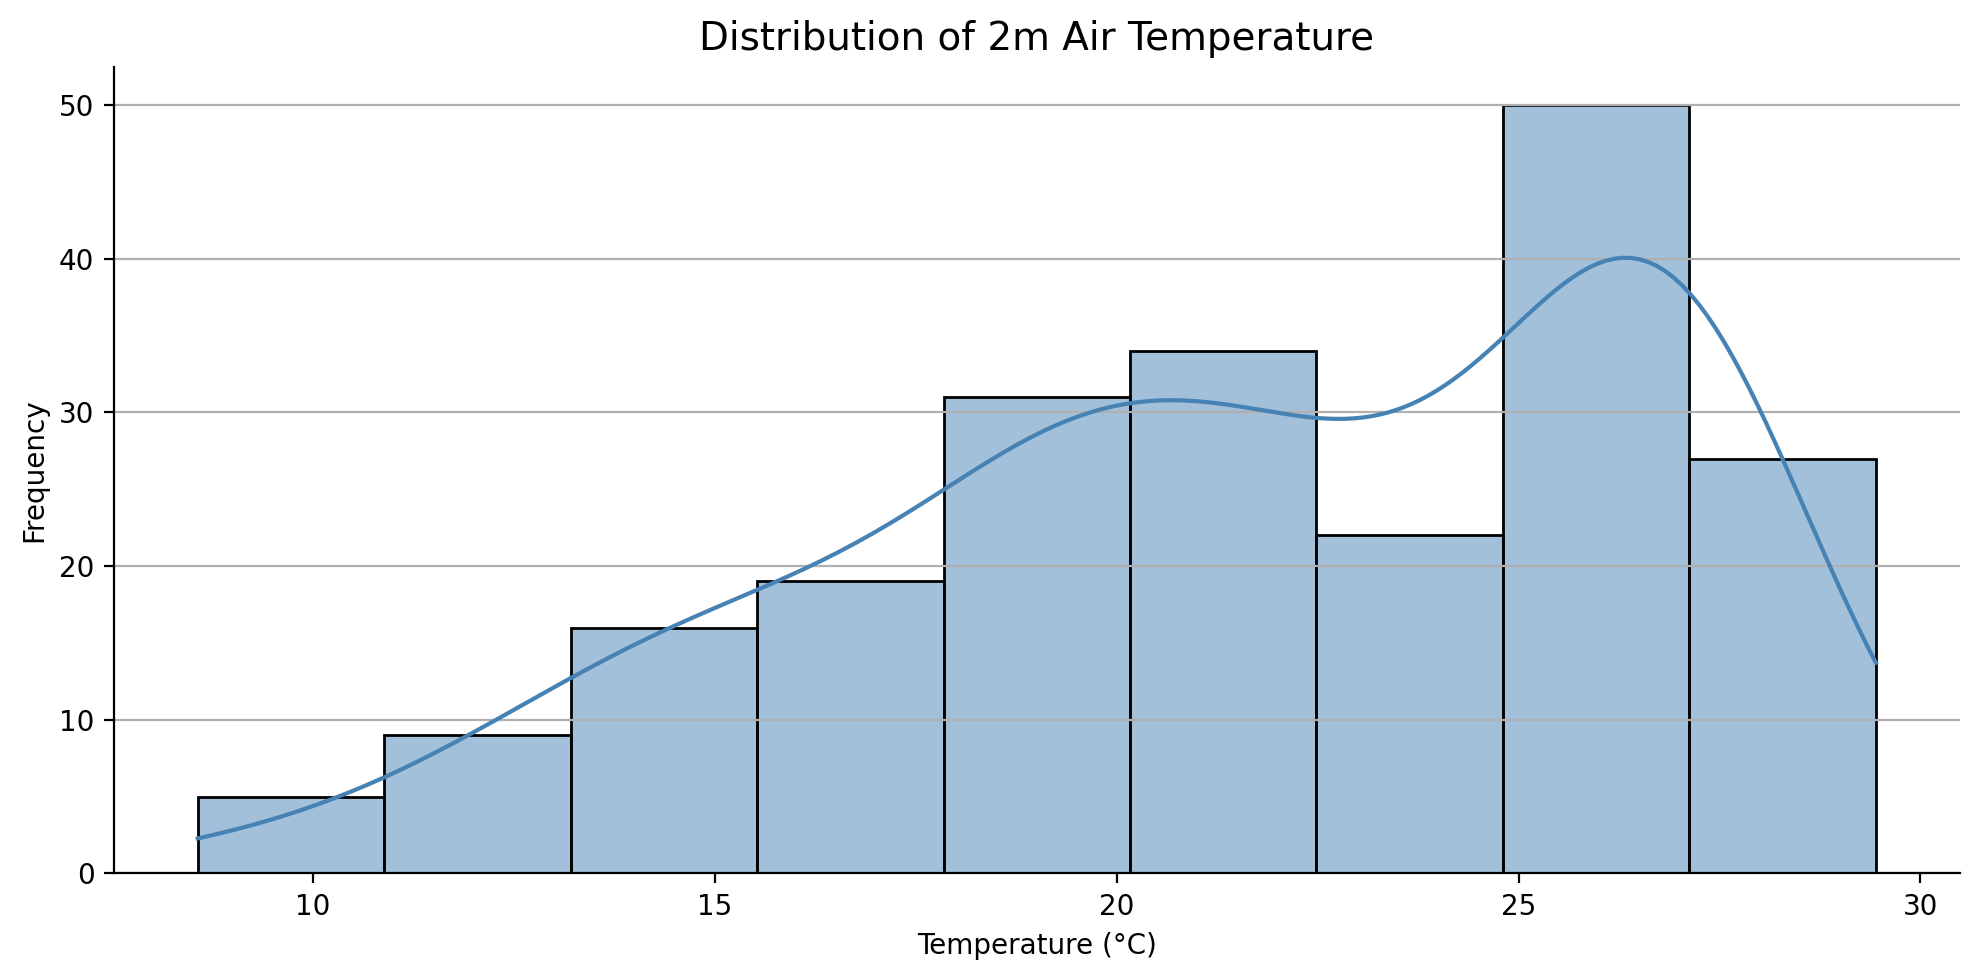

In [26]:
# Histogram with KDE for 2m air temperature
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[temp_col].dropna(), kde=True, color=PALETTE[0], ax=ax)
ax.set_title("Distribution of 2m Air Temperature", fontsize=14)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Frequency")
sns.despine()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show();

The temperature histogram reveals a bimodal or broadly spread distribution rather than a single normal peak. This pattern is expected for weekly climate data spanning the full annual cycle — weeks cluster toward either the winter range or the summer range, with fewer weeks at the transitional spring/fall temperatures. A distribution of this shape is sometimes called "bathtub" or uniform-like across the range. The KDE curve will show one or two peaks reflecting the dominant seasonal modes. This distribution structure reinforces the need to consider seasonal position (week of year or month) as a potential confounder in the modeling section, since temperature is not independently distributed but instead tracks the annual cycle.

### <span style="color:#FFD700">Step D — Boxplot by Year: 2m Air Temperature</span>

The following cell plots the distribution of weekly 2m air temperature separately for each study year using a box-and-whisker plot.

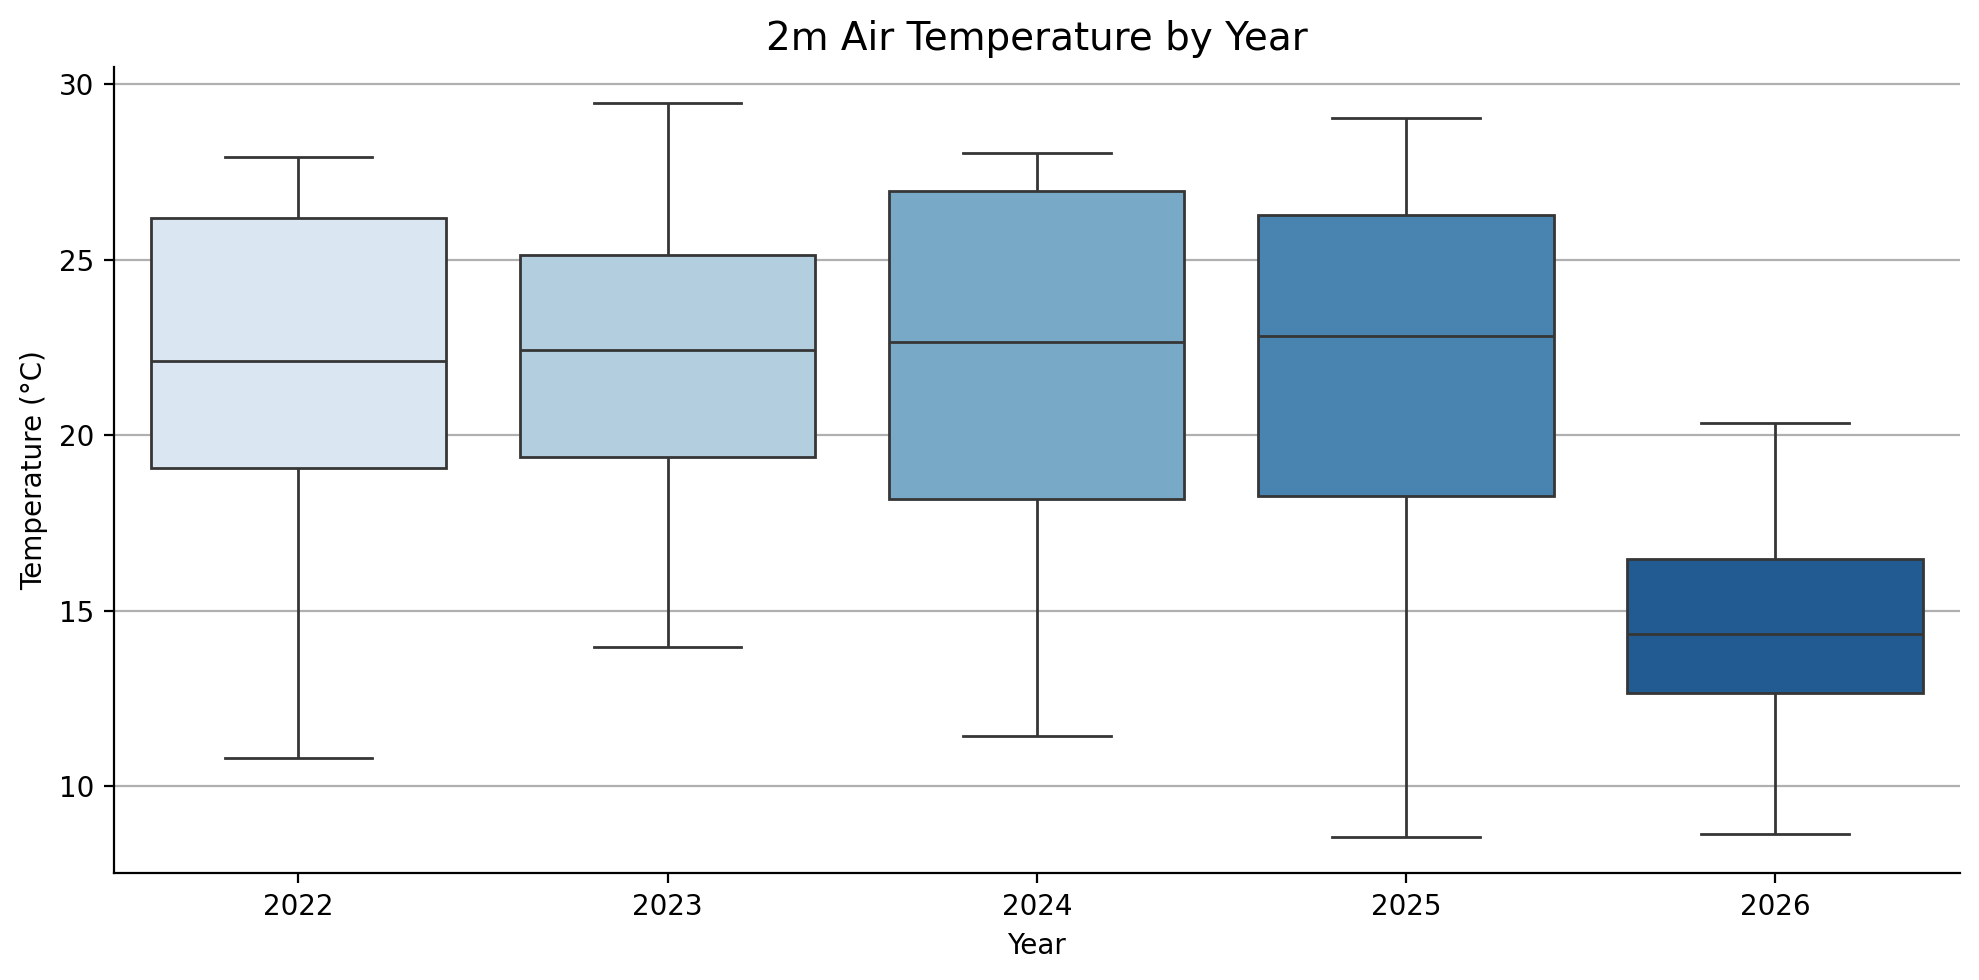

In [27]:
# Box-and-whisker plot of 2m air temperature by year
df_temp_plot = df.dropna(subset=[year_col, temp_col]).copy()
df_temp_plot[year_col] = df_temp_plot[year_col].astype(int)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=year_col, y=temp_col, data=df_temp_plot, palette=PALETTE, ax=ax)
sns.stripplot(x=year_col, y=temp_col, data=df_temp_plot, palette=PALETTE, alpha=0.4, size=3, jitter=True, ax=ax)
ax.set_title("2m Air Temperature by Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
sns.despine()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show();

The year-stratified boxplots allow detection of anomalous temperature patterns in any single year. For a subtropical location like Florida, we expect median annual temperature to fall within approximately 20–24°C and whiskers to extend from roughly 10–12°C (winter minimum) to 30–31°C (summer maximum). Any year whose box or whiskers fall substantially outside this range warrants investigation — it may indicate an unusually warm or cool period, or a gap in data coverage that truncates the seasonal range. The year 2026 is expected to show a narrower box with a lower range, as it contains only the January–April period. All four complete years should show broadly similar spread if the climate record is internally consistent.

## <span style="color:#0096FF">4.2 — Relative Humidity</span>

### <span style="color:#FFD700">Step A — Descriptive Statistics: Relative Humidity</span>

The following cell computes `.describe()` summary statistics alongside the interquartile range for weekly average relative humidity.

In [28]:
# Descriptive statistics and IQR for relative humidity
humidity_desc = df[humidity_col].describe()
humidity_iqr = stats.iqr(df[humidity_col].dropna())
style_df(humidity_desc.to_frame(name='Value'),
         caption='Descriptive statistics: weekly mean relative humidity (%)',
         gradient='num', gradient_cols=['Value'])
print(f"\nIQR: {humidity_iqr:.2f} %")

count    213.000000
mean      78.666646
std        4.698235
min       64.888300
25%       74.711300
50%       79.299000
75%       82.308400
max       89.250800

IQR: 7.60 %


Relative humidity has a mean of approximately 78.7% and a standard deviation of 4.7%, indicating that Florida maintains consistently high humidity throughout the year with relatively modest week-to-week variation. The IQR of approximately 7.6% is narrow, reflecting the subtropical humidity regime in which even "dry season" weeks rarely fall below 60–65%. The minimum and maximum values will confirm whether any anomalously dry or saturated weeks exist in the record. For *Aedes* mosquito biology, sustained humidity above approximately 60% is generally necessary for adult survival, and high humidity accelerates the extrinsic incubation period of dengue virus — making this variable a plausible predictor of transmission intensity.

### <span style="color:#FFD700">Step B — Year-Grouped Summary: Relative Humidity</span>

The following cell groups relative humidity by epidemiological year and applies `.describe()` to reveal interannual variation in humidity levels.

In [29]:
# Year-grouped descriptive statistics for relative humidity
humidity_by_year = df.dropna(subset=[year_col, humidity_col]).groupby(
    df.dropna(subset=[year_col, humidity_col])[year_col].astype(int)
)[humidity_col].describe().round(2)
style_df(humidity_by_year, caption='Annual relative humidity summary statistics (weekly mean, %)', gradient='num')

             count   mean   std    min    25%    50%    75%    max
dengue_year                                                       
2022          52.0  79.41  4.28  71.79  76.28  79.92  82.63  87.04
2023          44.0  78.38  4.14  68.48  75.91  78.47  81.06  89.25
2024          52.0  78.86  4.85  69.50  74.02  79.70  83.24  88.15
2025          52.0  78.44  4.79  64.89  75.70  79.54  81.49  86.63
2026           8.0  74.46  6.01  66.25  70.34  74.22  77.01  85.50


Year-grouped humidity statistics reveal whether any particular year experienced systematically drier or wetter atmospheric conditions than the others. Florida's humidity is driven primarily by its subtropical position and the summer rainy season — so large interannual differences in mean humidity would be notable and could indicate either real climate anomalies (e.g., a drier-than-normal dry season) or localized data collection issues. Humidity variation between years may contribute to interannual variation in dengue transmission independently of temperature, which motivates its inclusion as a separate predictor rather than treating it as redundant with temperature.

### <span style="color:#FFD700">Step C — Histogram: Relative Humidity</span>

The following cell plots a histogram with a KDE overlay for the weekly average relative humidity distribution.

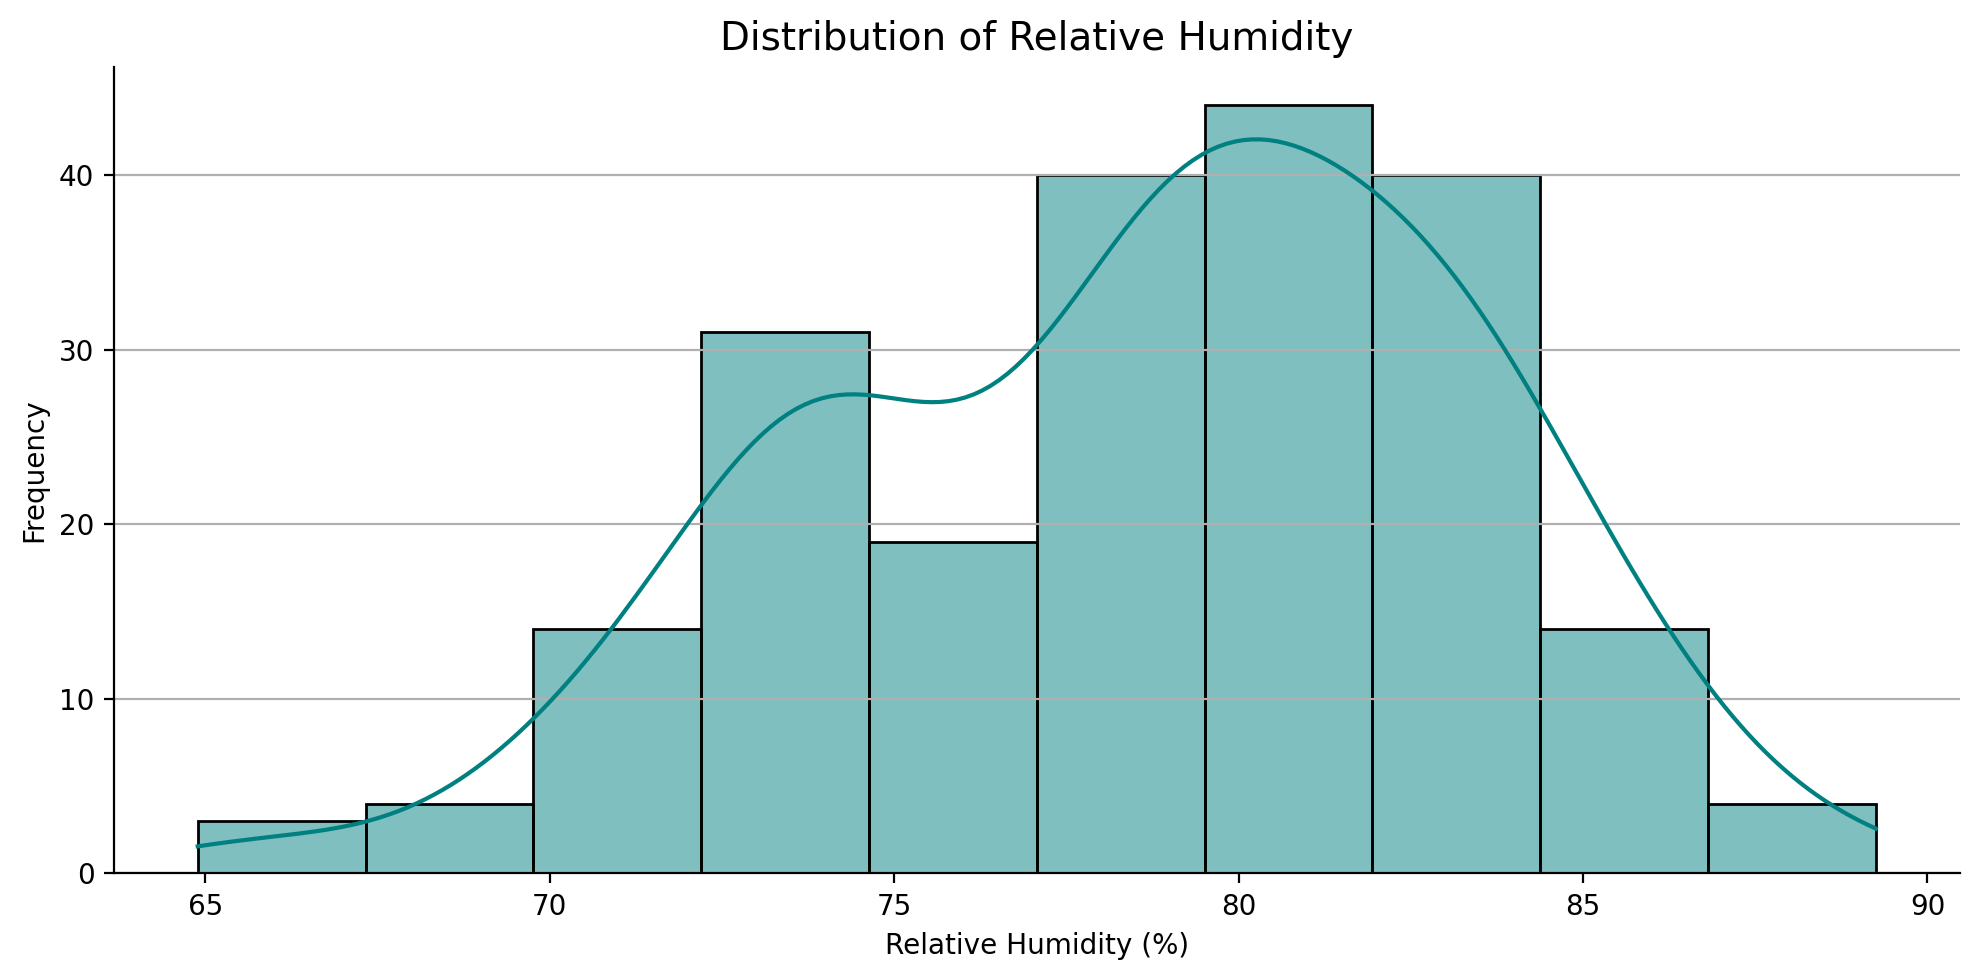

In [30]:
# Histogram with KDE for relative humidity
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[humidity_col].dropna(), kde=True, color=PALETTE[2], ax=ax)
ax.set_title("Distribution of Relative Humidity", fontsize=14)
ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("Frequency")
sns.despine()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show();

The humidity histogram shows the overall distribution of weekly average relative humidity across the study period. Unlike temperature, which is expected to show a bimodal pattern from the seasonal cycle, humidity in a subtropical climate often shows a left-skewed or moderately bell-shaped distribution, because even the dry season in Florida maintains relatively high relative humidity. If the histogram shows a sharp left tail (weeks with anomalously low humidity), those weeks may correspond to dry cold-front passages in winter. The KDE overlay helps reveal the dominant modal value and the direction of skew. The shape of this distribution has direct implications for whether humidity enters the model as a linear term or requires transformation.

### <span style="color:#FFD700">Step D — Boxplot by Year: Relative Humidity</span>

The following cell plots relative humidity by year to compare interannual differences in central tendency and spread.

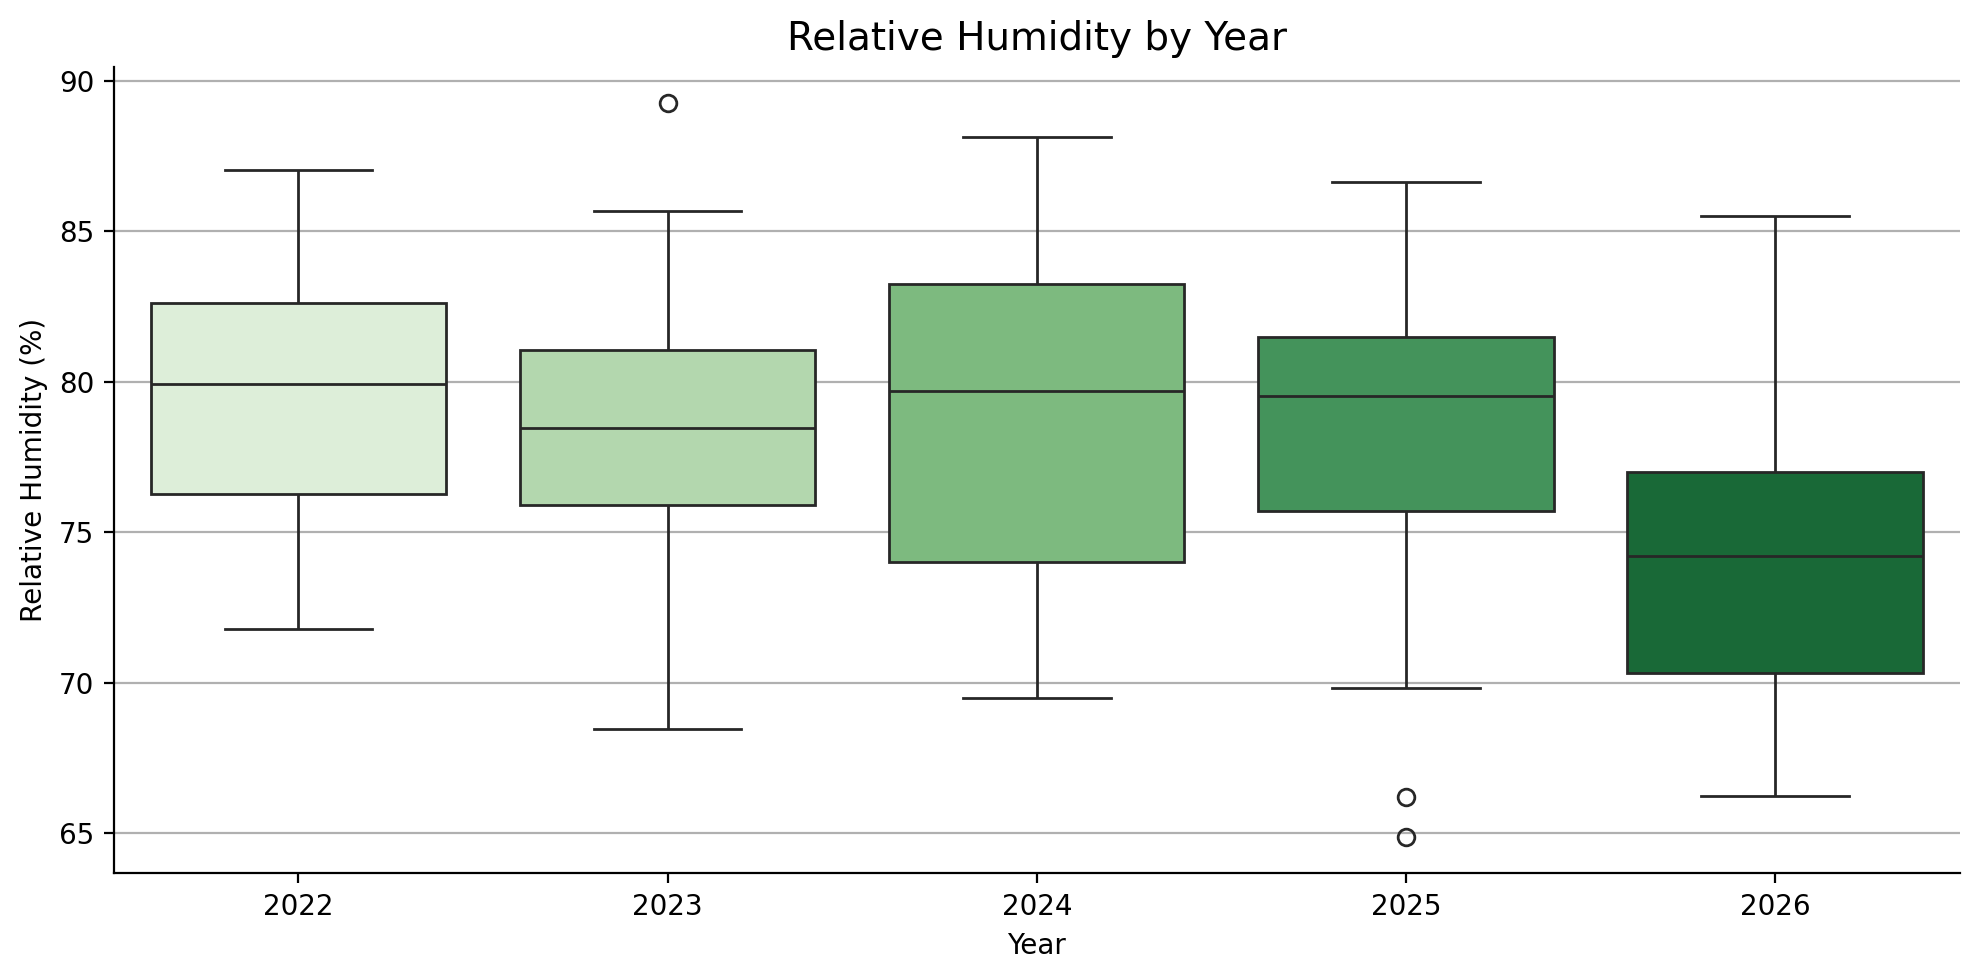

In [31]:
# Box-and-whisker plot of relative humidity by year
df_hum_plot = df.dropna(subset=[year_col, humidity_col]).copy()
df_hum_plot[year_col] = df_hum_plot[year_col].astype(int)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=year_col, y=humidity_col, data=df_hum_plot, palette=PALETTE, ax=ax)
sns.stripplot(x=year_col, y=humidity_col, data=df_hum_plot, palette=PALETTE, alpha=0.4, size=3, jitter=True, ax=ax)
ax.set_title("Relative Humidity by Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Relative Humidity (%)")
sns.despine()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show();

The year-stratified boxplots for humidity allow identification of any year with anomalously low or high median humidity. In Florida's subtropical climate, median weekly humidity is expected to cluster between approximately 75–82% annually, with some weeks reaching near 95% during the summer rainy season and a lower tail extending toward 60–65% during dry winter periods. Any year whose median humidity differs substantially from the others, or whose whiskers extend to extreme low values, warrants note in the modeling section as a potential source of interannual variation in transmission risk. Consistent humidity ranges across years would suggest that interannual differences in dengue incidence are unlikely to be explained primarily by humidity variation.

## <span style="color:#0096FF">4.3 — Rainfall</span>

### <span style="color:#FFD700">Step A — Descriptive Statistics: Weekly Rainfall</span>

The following cell computes `.describe()` summary statistics alongside the interquartile range for weekly total rainfall. Rainfall is measured in inches and is expected to be highly right-skewed due to storm events.

In [32]:
# Descriptive statistics and IQR for weekly rainfall
rainfall_desc = df[rainfall_col].describe()
rainfall_iqr = stats.iqr(df[rainfall_col].dropna())
style_df(rainfall_desc.to_frame(name='Value'),
         caption='Descriptive statistics: weekly total rainfall (inches)',
         gradient='num', gradient_cols=['Value'])
print(f"\nIQR: {rainfall_iqr:.3f} inches")

count    213.000000
mean       0.137187
std        0.133916
min        0.000300
25%        0.034900
50%        0.108000
75%        0.197500
max        0.853800

IQR: 0.163 inches


Weekly rainfall has a mean of approximately 0.137 inches and a standard deviation of 0.134 inches — a coefficient of variation near 1.0, indicating extreme relative variability. The IQR of approximately 0.163 inches is larger than the mean, and the maximum value of approximately 0.854 inches represents weeks with exceptional precipitation likely associated with tropical storm activity. The high maximum relative to the mean and median is a hallmark of right skew. This skew is biologically relevant: moderate rainfall promotes standing water and *Aedes* breeding habitat, while extreme rainfall events (storms) may cause larval washout, temporarily suppressing mosquito populations. A log or square-root transformation of rainfall may be warranted before entering it as a linear predictor in regression models.

### <span style="color:#FFD700">Step B — Year-Grouped Summary: Weekly Rainfall</span>

The following cell groups rainfall by epidemiological year and applies `.describe()` to reveal whether any year experienced notably higher or lower precipitation than the others.

In [33]:
# Year-grouped descriptive statistics for weekly rainfall
rainfall_by_year = df.dropna(subset=[year_col, rainfall_col]).groupby(
    df.dropna(subset=[year_col, rainfall_col])[year_col].astype(int)
)[rainfall_col].describe().round(3)
style_df(rainfall_by_year, caption='Annual rainfall summary statistics (weekly total, inches)', gradient='num')

             count   mean    std    min    25%    50%    75%    max
dengue_year                                                        
2022          52.0  0.153  0.139  0.000  0.046  0.114  0.243  0.743
2023          44.0  0.133  0.125  0.001  0.037  0.112  0.196  0.483
2024          52.0  0.159  0.170  0.003  0.041  0.111  0.201  0.854
2025          52.0  0.123  0.098  0.000  0.030  0.110  0.196  0.388
2026           8.0  0.045  0.037  0.003  0.028  0.036  0.055  0.110


Year-grouped rainfall statistics reveal the degree to which total precipitation varied across the four study years. Florida's rainfall is strongly seasonal, concentrated in the June–September wet season, with the dry season (October–May) receiving far less. Annual mean rainfall aggregated from weekly values should be broadly comparable across years unless a particular year experienced an exceptional hurricane season or drought. High maximum values in any given year will identify the wettest storm event recorded in that year's data. Year-level differences in rainfall totals may partially explain interannual variation in dengue transmission, particularly if a very wet year coincided with a local outbreak.

### <span style="color:#FFD700">Step C — Histogram: Weekly Rainfall</span>

The following cell plots a histogram with a KDE overlay for the weekly rainfall distribution. Right skew from storm events is expected and will be addressed explicitly.

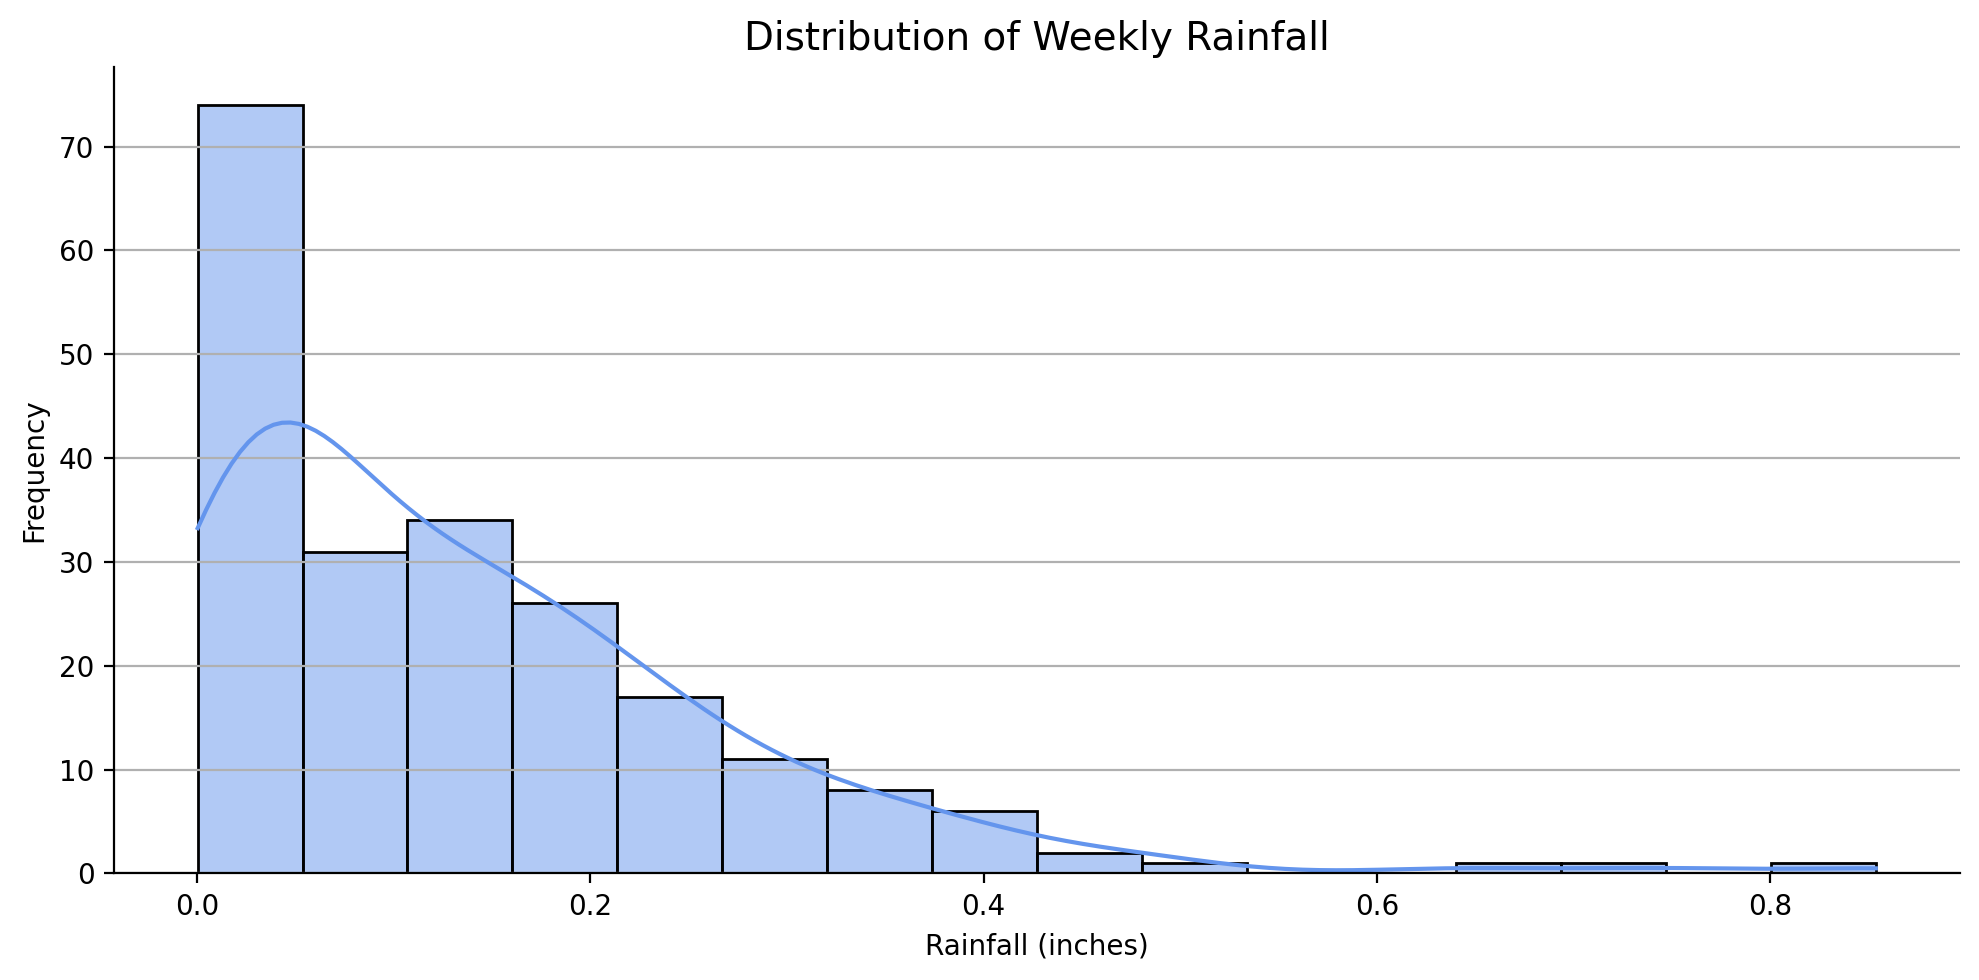

In [34]:
# Histogram with KDE for weekly rainfall
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[rainfall_col].dropna(), kde=True, color=PALETTE[3], ax=ax)
ax.set_title("Distribution of Weekly Rainfall", fontsize=14)
ax.set_xlabel("Rainfall (inches)")
ax.set_ylabel("Frequency")
sns.despine()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show();

The rainfall histogram confirms the expected strong right skew: the majority of weeks receive little to no measurable rainfall, while a long right tail reflects weeks associated with tropical systems or sustained wet-season rainfall. This distribution shape is characteristic of precipitation data and is a direct consequence of the asymmetric nature of rainfall — there is a hard lower bound at zero, but no upper bound. The KDE curve will show a sharp peak near zero and a slowly decaying tail. The presence of extreme outlier weeks — those with rainfall values well above the 75th percentile — may represent genuine tropical storm events, and their influence on any regression model should be examined carefully. A log(x + 1) or square-root transformation is commonly applied to rainfall before modeling to reduce leverage from these extreme values.

### <span style="color:#FFD700">Step D — Boxplot by Year: Weekly Rainfall</span>

The following cell plots weekly rainfall by year to identify any anomalous years and to compare the distribution of storm-week outliers across the study period.

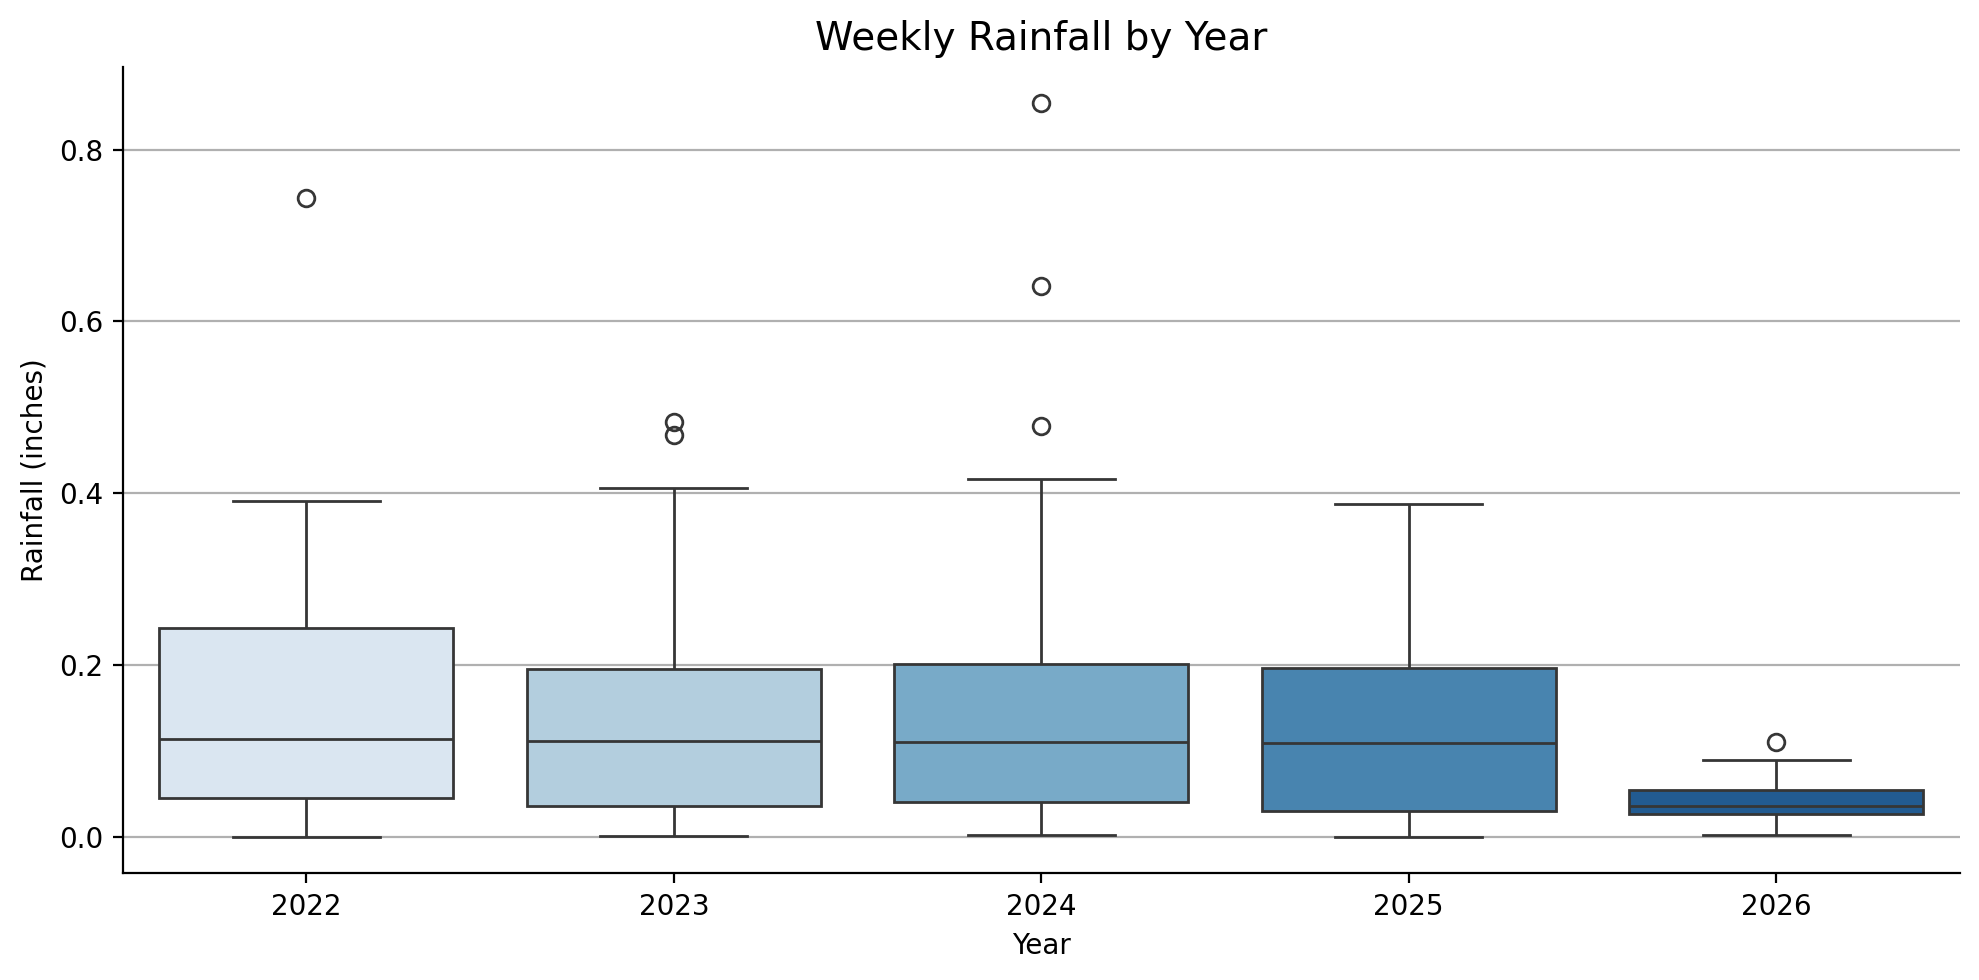

In [35]:
# Box-and-whisker plot of weekly rainfall by year
df_rain_plot = df.dropna(subset=[year_col, rainfall_col]).copy()
df_rain_plot[year_col] = df_rain_plot[year_col].astype(int)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=year_col, y=rainfall_col, data=df_rain_plot, palette=PALETTE, ax=ax)
sns.stripplot(x=year_col, y=rainfall_col, data=df_rain_plot, palette=PALETTE, alpha=0.4, size=3, jitter=True, ax=ax)
ax.set_title("Weekly Rainfall by Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Rainfall (inches)")
sns.despine()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show();

The year-stratified rainfall boxplots reveal which years contained the most extreme weekly precipitation events and whether overall rainfall levels varied substantially across the study period. In a typical Florida year, the median weekly rainfall will be low (dry-season weeks dominate the annual count), but the upper whisker and outlier points will extend well above the third quartile due to wet-season storm events. Any year with a notably higher maximum outlier than the others may correspond to an active hurricane season or an unusually wet summer, and could be associated with short-term mosquito breeding surges followed by potential larval washout. The absence of extreme outliers in any particular year could reflect a drought year. These patterns inform whether rainfall requires year-specific handling or interaction terms in the modeling section.

## <span style="color:#0096FF">4.4 — Climate Variable Intercorrelation</span>

The following cell computes the Pearson correlation matrix of all three climate predictor variables — 2m air temperature, relative humidity, and total weekly rainfall — and displays it as an annotated heatmap. This analysis identifies any multicollinearity concerns to carry into the modeling section.

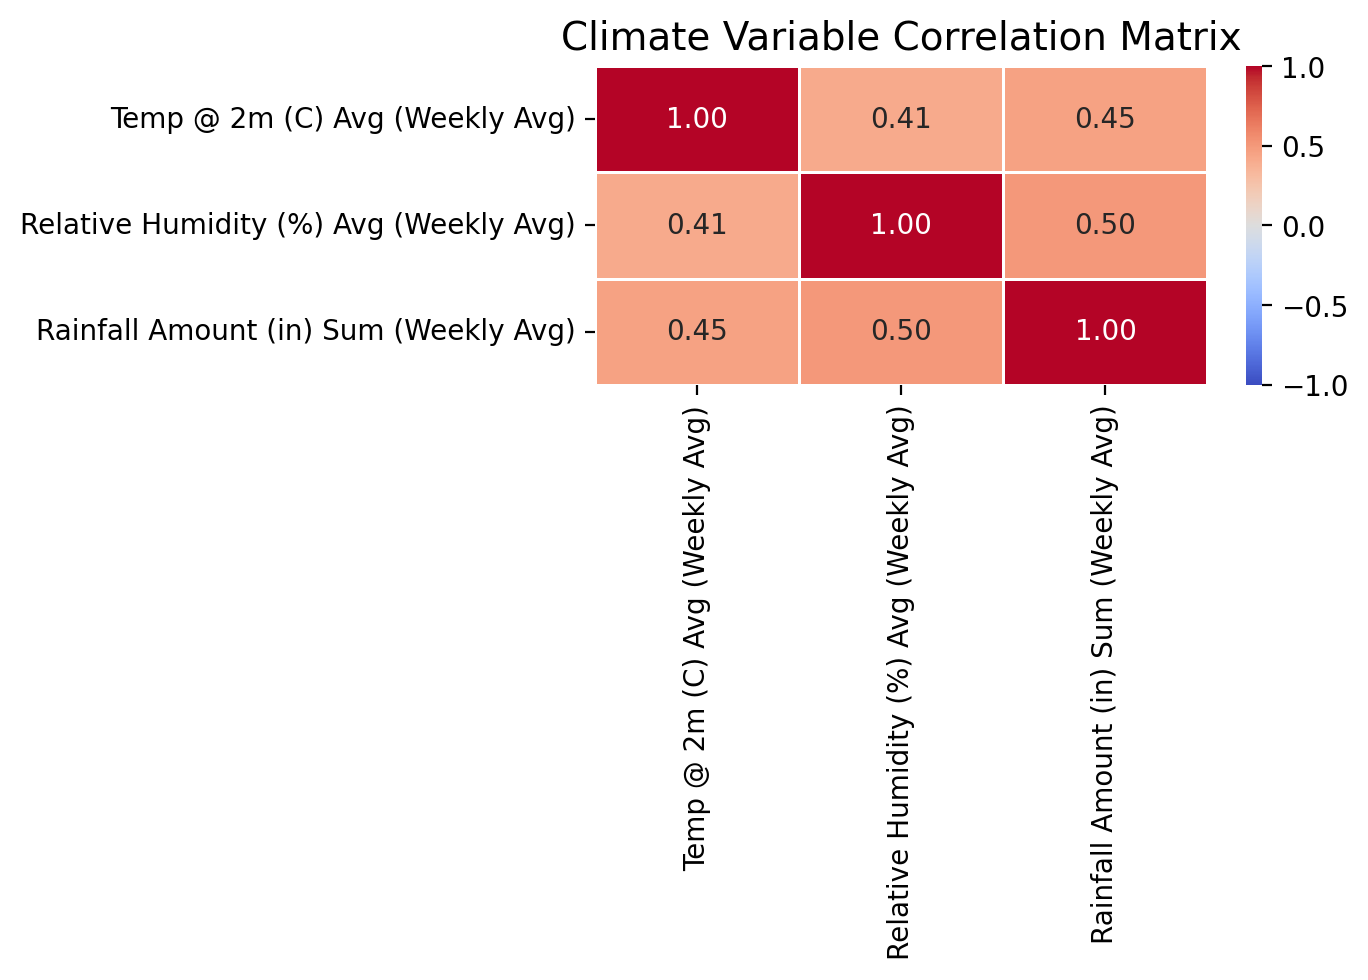

In [36]:
# Pearson correlation matrix of the three climate variables
climate_cols = [temp_col, humidity_col, rainfall_col]
climate_corr = df[climate_cols].corr().round(4)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(climate_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
plt.title("Climate Variable Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show();

The correlation matrix reveals moderate positive associations among all three climate variables. Temperature and humidity correlate at $r = 0.41$ (moderate), temperature and rainfall at $r = 0.45$ (moderate), and humidity and rainfall at $r = 0.50$ (moderate). These associations are expected in Florida's subtropical climate: the warm wet season (June–September) elevates all three variables simultaneously, while the cool dry season (November–March) reduces all three. Despite these moderate correlations, none of the pairwise values approaches the threshold (r > 0.80) typically considered indicative of problematic collinearity in regression. The three climate variables therefore retain independent predictive information and can be included jointly in a model without severe variance inflation. The moderate shared variance should nonetheless be monitored through variance inflation factor ($\text{VIF}$) diagnostics in the modeling section, particularly for models that include all three predictors simultaneously.

## <span style="color:#0096FF">Section 3 — Time Series Visualization</span>

This section examines the temporal structure of dengue cases and climate variables across the 2022–2026 study period. The analyses proceed from full time series plots through co-visualizations of climate and case data, a seasonal heat calendar, overlaid interannual comparisons, and formal seasonal decomposition.

## <span style="color:#0096FF">5.1 — Full Time Series: Cases</span>

The following cell produces a two-panel stacked figure showing weekly local and travel-associated dengue cases across the full study period. A shaded area under each line emphasizes outbreak periods and seasonal structure. The x-axis is shared across panels.

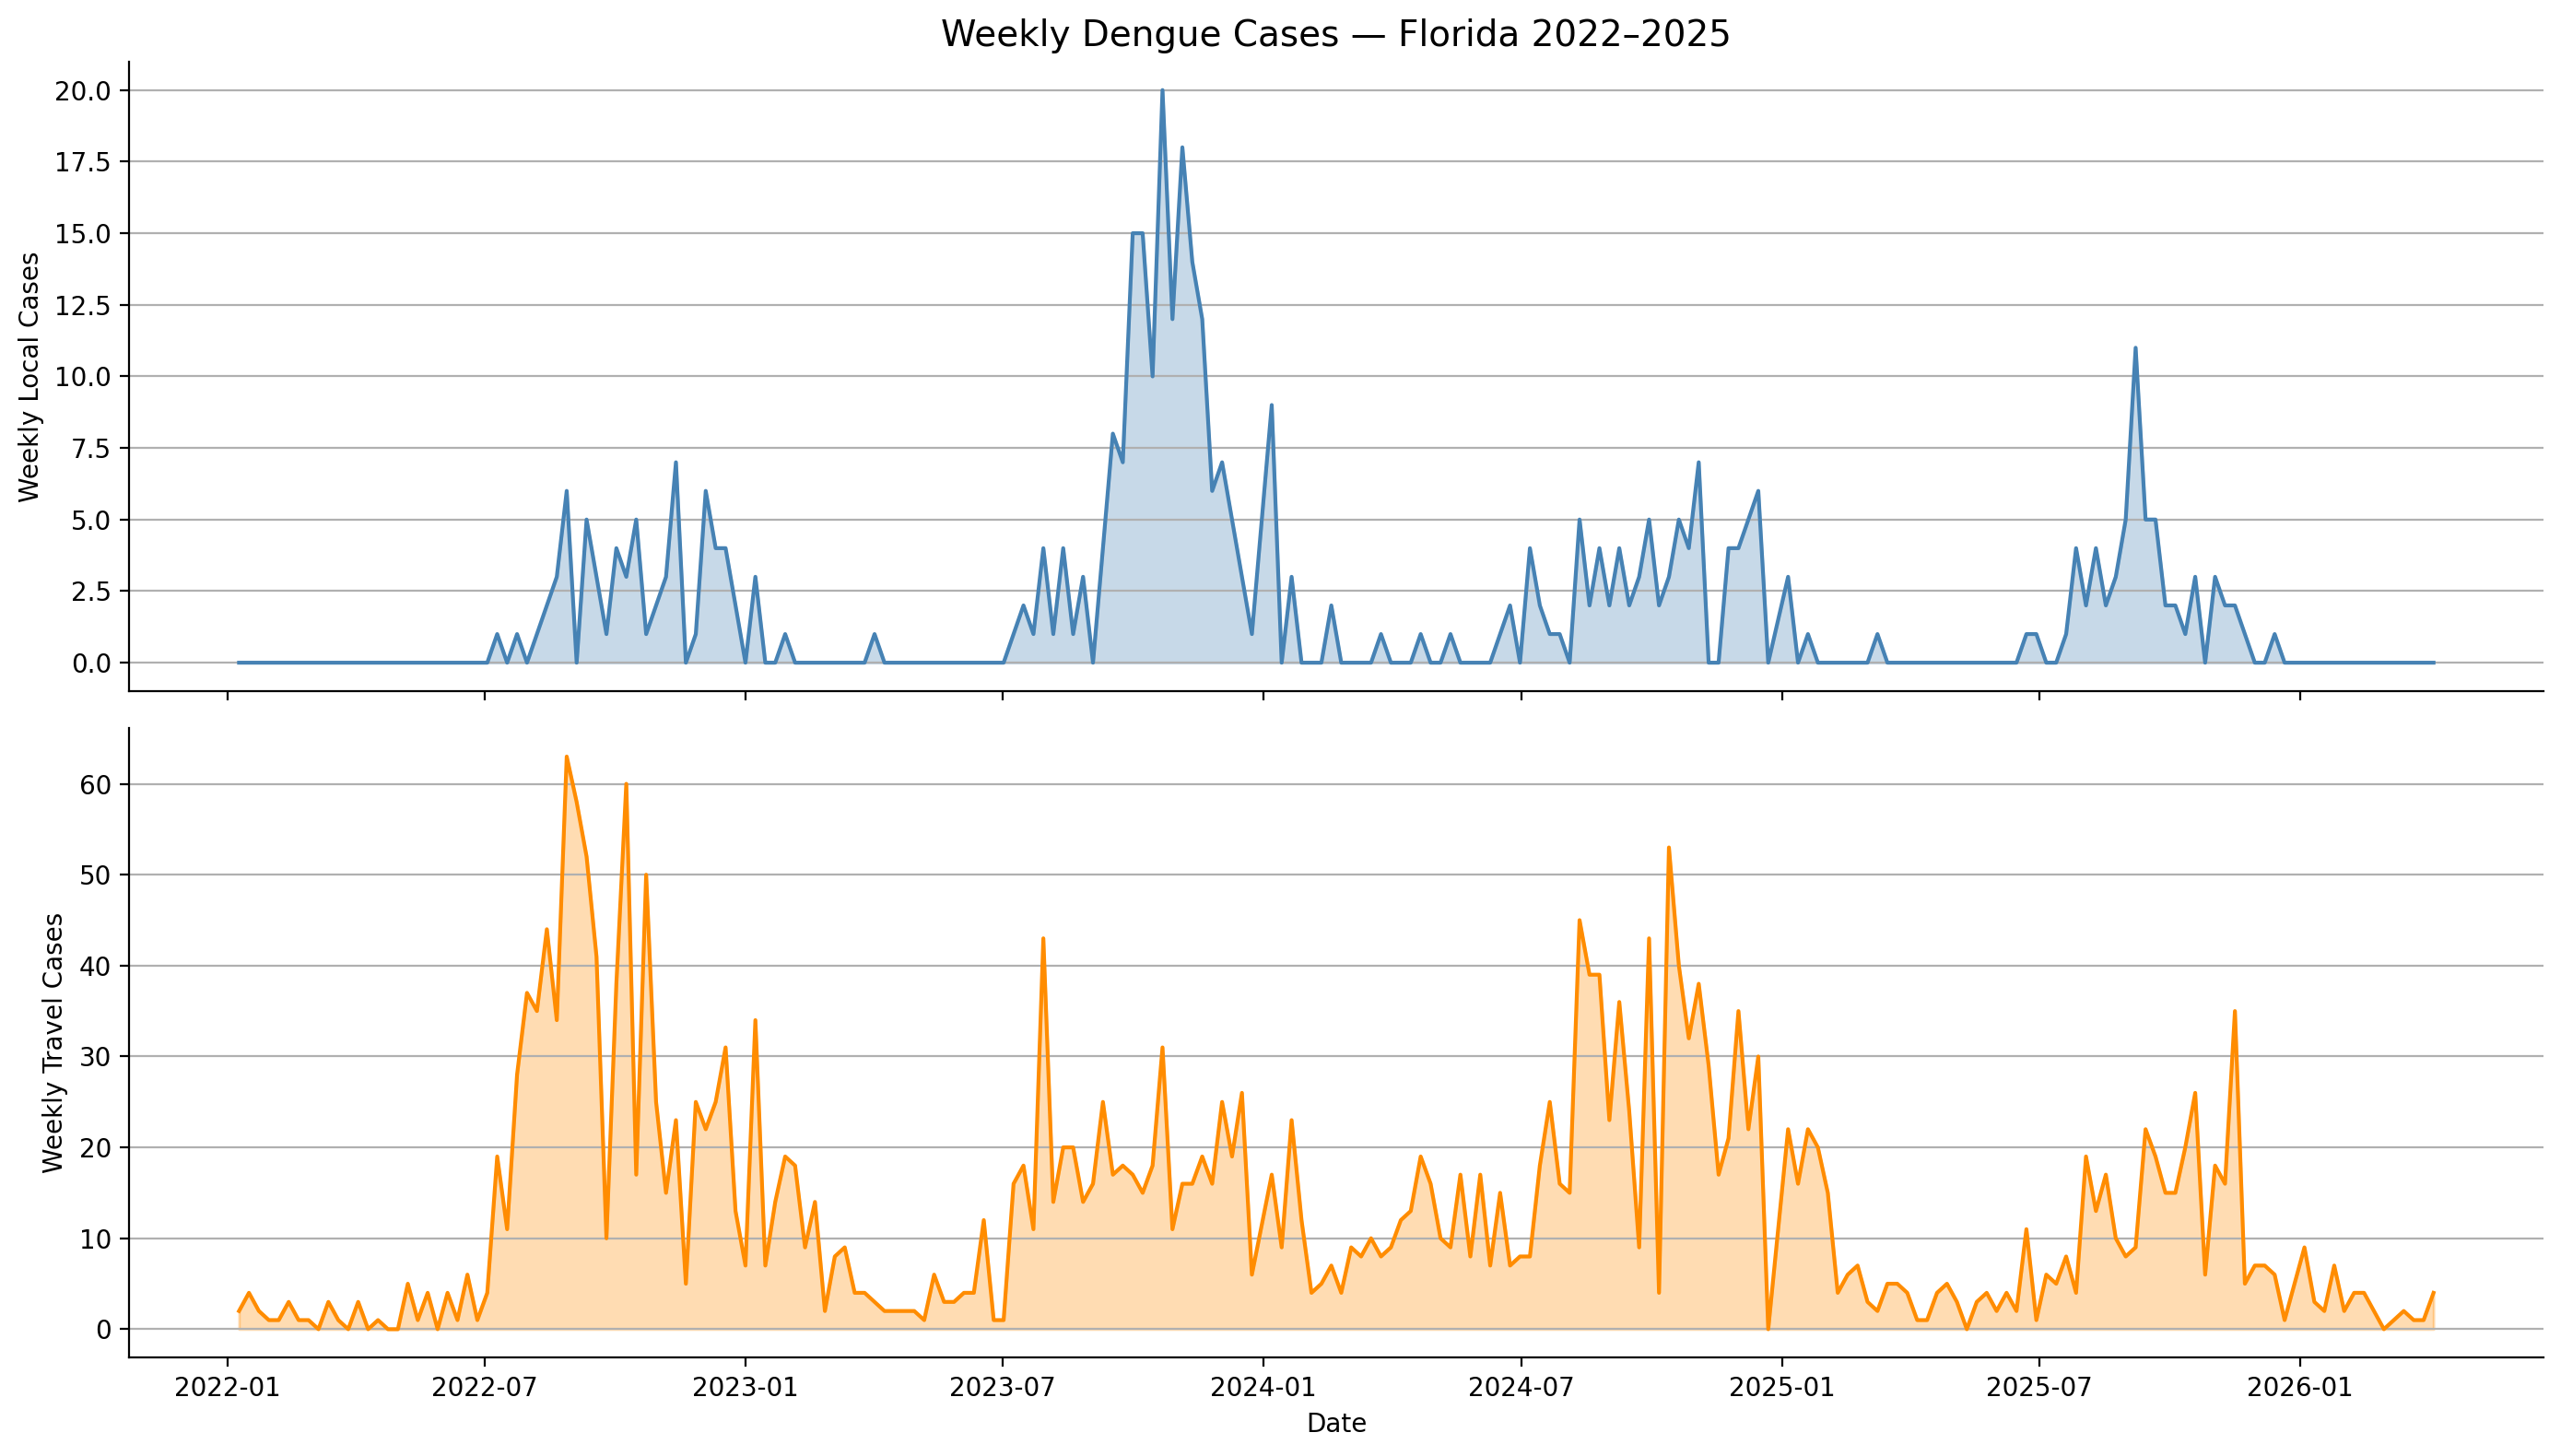

In [37]:
# Two-panel stacked time series: weekly local and travel-associated cases
df_ts = df.dropna(subset=['dengue_week_start']).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: weekly local cases
ax1.plot(df_ts['dengue_week_start'], df_ts[local_col], color=PALETTE[0], linewidth=1.5)
ax1.fill_between(df_ts['dengue_week_start'], df_ts[local_col].fillna(0), alpha=0.3, color=PALETTE[0])
ax1.set_ylabel("Weekly Local Cases")
ax1.set_title("Weekly Dengue Cases — Florida 2022–2025", fontsize=14)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax1)

# Bottom panel: weekly travel-associated cases
ax2.plot(df_ts['dengue_week_start'], df_ts[travel_col], color=PALETTE[1], linewidth=1.5)
ax2.fill_between(df_ts['dengue_week_start'], df_ts[travel_col].fillna(0), alpha=0.3, color=PALETTE[1])
ax2.set_ylabel("Weekly Travel Cases")
ax2.set_xlabel("Date")
ax2.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show();

The full case time series makes the episodic nature of local transmission immediately visible. Local cases (top panel) are near zero for most of the year, rising into brief, sharply peaked outbreak windows concentrated in the late summer and fall months (approximately August–October), consistent with the peak of *Aedes aegypti* activity in Florida's subtropical climate. The largest outbreak evident in the record corresponds to 2023, where the time series shows multiple consecutive non-zero weeks with a peak exceeding 15 cases in a single week — the documented DENV-3 serotype emergence event. The years 2022, 2024, and 2025 show smaller but similarly timed outbreak windows.

Travel cases (bottom panel) tell a different story: a nearly continuous non-zero signal throughout all four years, with seasonal oscillation that parallels global dengue transmission cycles and international travel patterns. Peak travel case weeks do not perfectly align with local outbreak peaks — the 2022 and 2024 travel case peaks were among the highest in the record but were not accompanied by proportionally elevated local transmission, suggesting that vector conditions (not importation pressure alone) gate local outbreak intensity. Visual co-movement between the two panels is imperfect, which motivates the quantitative cross-correlation analysis in Section 6.5.

## <span style="color:#0096FF">5.2 — Full Time Series: Climate Variables</span>

The following cell produces a three-panel stacked figure showing 2m air temperature, relative humidity, and weekly rainfall across the full study period, with the same datetime x-axis shared across all three panels.

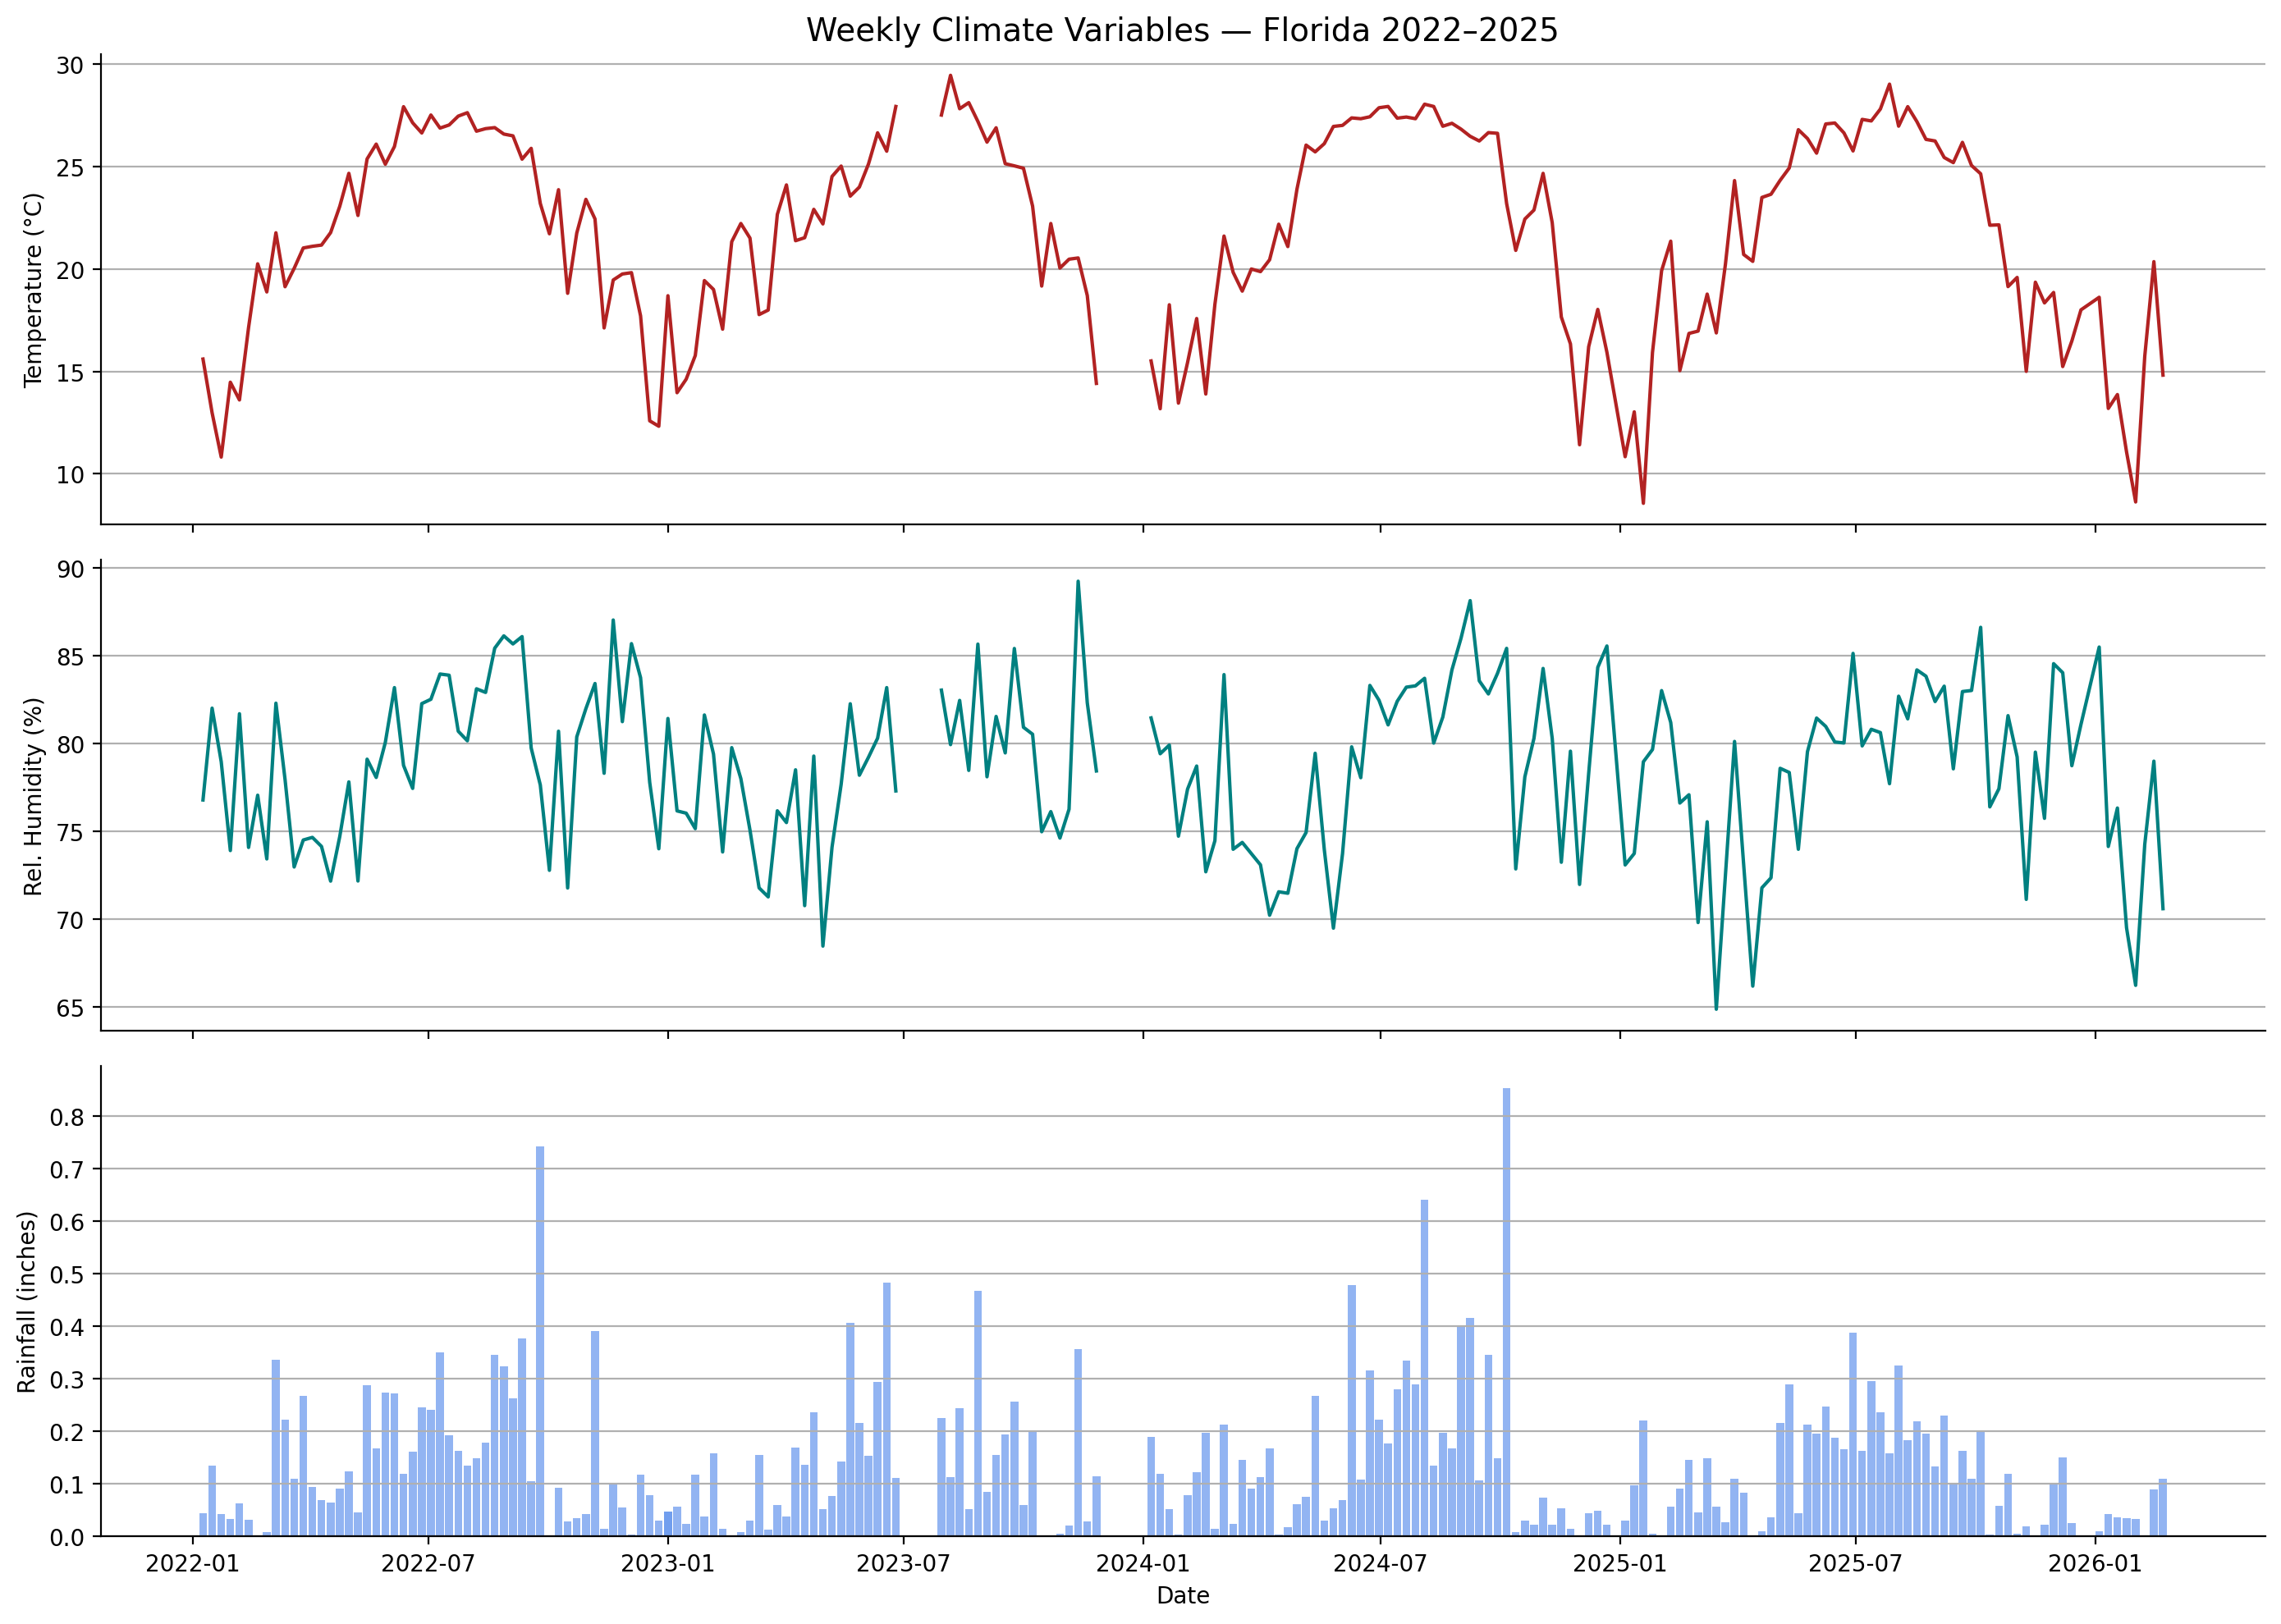

In [38]:
# Three-panel stacked time series: climate variables
df_cl = df.dropna(subset=['dengue_week_start']).copy()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Top panel: 2m temperature
ax1.plot(df_cl['dengue_week_start'], df_cl[temp_col], color=PALETTE[1], linewidth=1.5)
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Weekly Climate Variables — Florida 2022–2025", fontsize=14)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax1)

# Middle panel: relative humidity
ax2.plot(df_cl['dengue_week_start'], df_cl[humidity_col], color=PALETTE[2], linewidth=1.5)
ax2.set_ylabel("Rel. Humidity (%)")
ax2.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax2)

# Bottom panel: rainfall as bar chart
ax3.bar(df_cl['dengue_week_start'], df_cl[rainfall_col], width=6, color=PALETTE[3], alpha=0.7)
ax3.set_ylabel("Rainfall (inches)")
ax3.set_xlabel("Date")
ax3.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax3)

plt.tight_layout()
plt.show();

The climate time series reveal clear and consistent seasonal oscillations. Temperature (top panel) follows a smooth sinusoidal cycle with summer peaks near 30–31°C and winter troughs near 10–13°C — the expected subtropical annual cycle. The oscillation is highly regular across all four years, with no obvious anomalous seasons. Relative humidity (middle panel) also oscillates seasonally but with a less dramatic amplitude: humidity peaks during the wet summer months and reaches its lowest values in winter, with the year-round minimum remaining well above 60%. Rainfall (bottom panel) is displayed as a bar chart to better convey the episodic, spike-heavy nature of precipitation: the wet season (June–September) shows consistently elevated bars, while a few extreme bars — likely associated with tropical storm events — stand out prominently above the wet-season background.

Comparing the climate panels to the case panels from Section 5.1: the most prominent local case peaks (late summer 2023 in particular) align visually with the temperature plateau near or above 28°C and with elevated rainfall. The winter months, when temperature drops below 18°C, show no local cases in any year — consistent with the documented temperature threshold for *Aedes* activity. This visual alignment motivates the quantitative co-visualization and cross-correlation analyses that follow.

## <span style="color:#0096FF">5.3 — Dual-Axis Co-visualization</span>

### <span style="color:#FFD700">Figure 1 — Weekly Local Cases and Temperature</span>

The following cell overlays weekly local dengue cases (left y-axis) and 2m air temperature (right y-axis) on a shared time axis, making the visual relationship between the two series directly apparent.

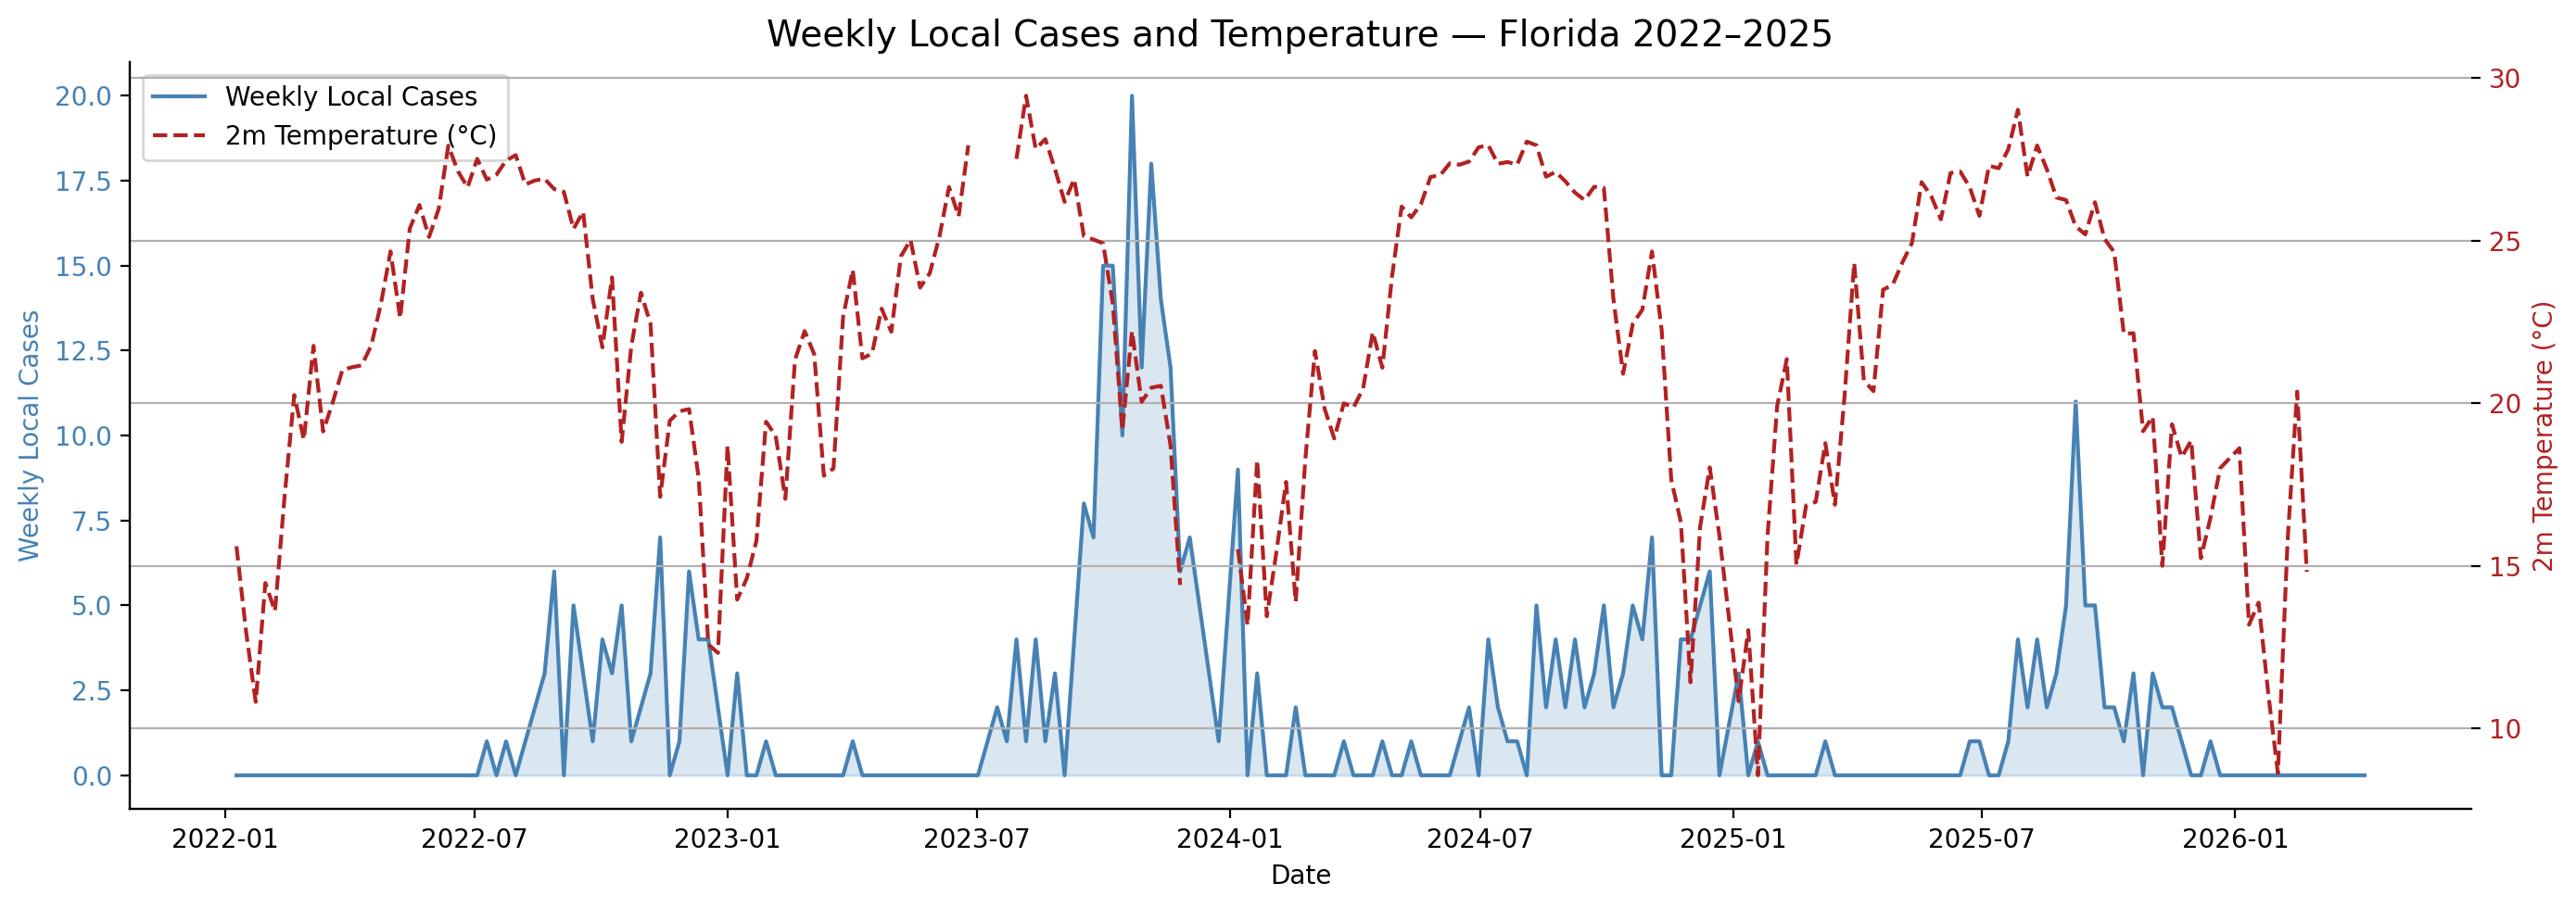

In [39]:
# Dual-axis: local cases (left) and temperature (right)
df_dual = df.dropna(subset=['dengue_week_start']).copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Left axis: local cases
ax1.plot(df_dual['dengue_week_start'], df_dual[local_col],
         color=PALETTE[0], linewidth=1.5, label='Weekly Local Cases')
ax1.fill_between(df_dual['dengue_week_start'], df_dual[local_col].fillna(0),
                 alpha=0.2, color=PALETTE[0])
ax1.set_ylabel("Weekly Local Cases", color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

# Right axis: temperature
ax2.plot(df_dual['dengue_week_start'], df_dual[temp_col],
         color=PALETTE[1], linewidth=1.5, linestyle='--', label='2m Temperature (°C)')
ax2.set_ylabel("2m Temperature (°C)", color=PALETTE[1])
ax2.tick_params(axis='y', labelcolor=PALETTE[1])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlabel("Date")
ax1.set_title("Weekly Local Cases and Temperature — Florida 2022–2025", fontsize=14)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The dual-axis overlay of local cases and temperature makes the seasonal relationship between the two series visible at the week level. Temperature (dashed red, right axis) traces a smooth annual cycle that consistently leads the local case series (solid blue, left axis): temperature begins rising in spring, but local cases remain near zero until temperature approaches approximately 25–28°C in mid-to-late summer. This lag — where cases peak several weeks after temperature peaks — is the intuitive illustration of the core biological mechanism: warming temperatures accelerate *Aedes* mosquito development and dengue viral replication within the vector, but the case effect is realized only after a multi-week extrinsic incubation and transmission chain. The precise lag magnitude will be quantified in the cross-correlation analysis in Section 6.4.

### <span style="color:#FFD700">Figure 2 — Weekly Local Cases and Rainfall</span>

The following cell overlays weekly local dengue cases (left y-axis) and weekly rainfall (right y-axis) to examine the visual co-movement between precipitation and case counts.

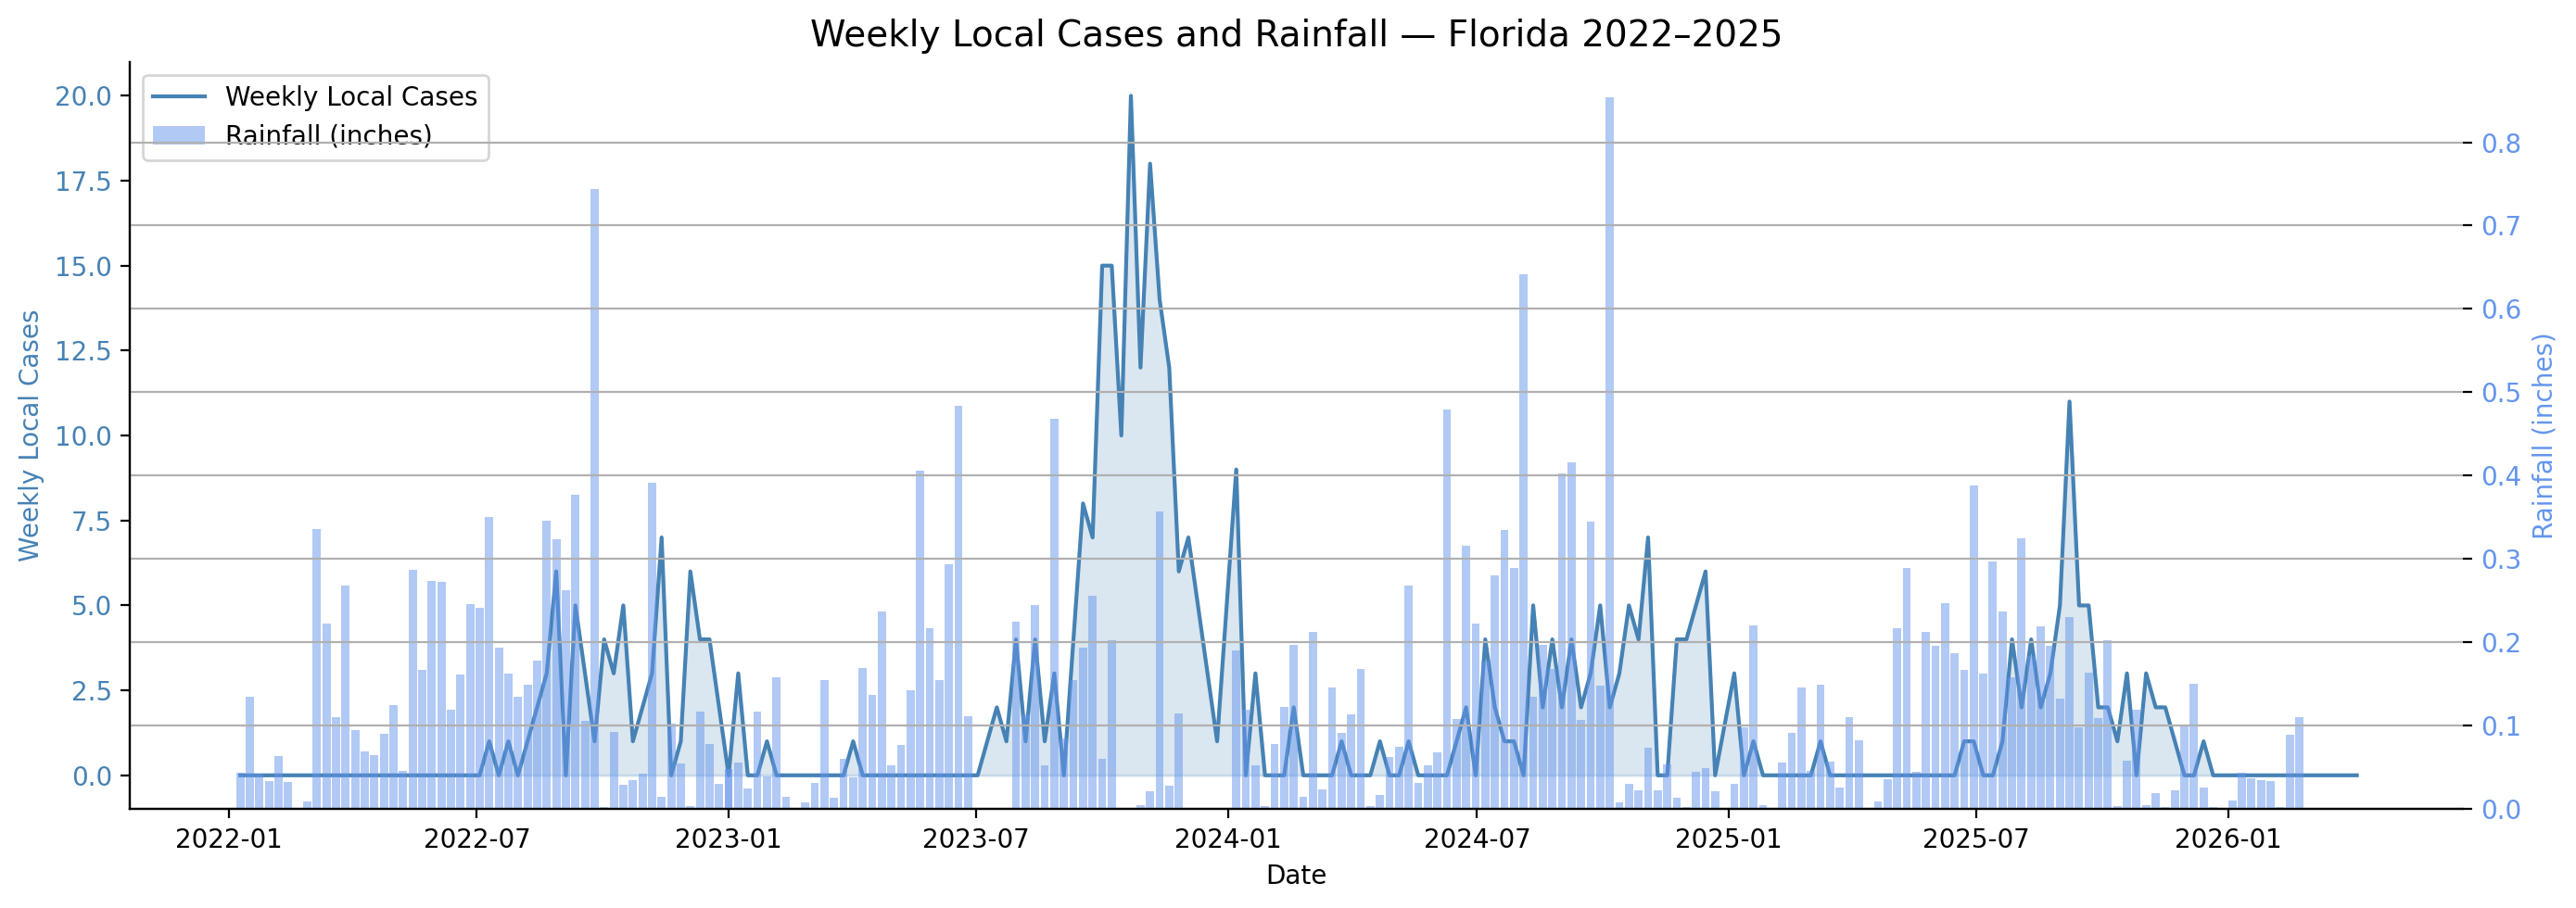

In [40]:
# Dual-axis: local cases (left) and rainfall (right)
df_dual = df.dropna(subset=['dengue_week_start']).copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Left axis: local cases
ax1.plot(df_dual['dengue_week_start'], df_dual[local_col],
         color=PALETTE[0], linewidth=1.5, label='Weekly Local Cases')
ax1.fill_between(df_dual['dengue_week_start'], df_dual[local_col].fillna(0),
                 alpha=0.2, color=PALETTE[0])
ax1.set_ylabel("Weekly Local Cases", color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

# Right axis: rainfall as bars
ax2.bar(df_dual['dengue_week_start'], df_dual[rainfall_col],
        width=6, color=PALETTE[3], alpha=0.5, label='Rainfall (inches)')
ax2.set_ylabel("Rainfall (inches)", color=PALETTE[3])
ax2.tick_params(axis='y', labelcolor=PALETTE[3])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlabel("Date")
ax1.set_title("Weekly Local Cases and Rainfall — Florida 2022–2025", fontsize=14)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The rainfall co-visualization reveals a more complex relationship than the temperature overlay. Rainfall (blue bars, right axis) exhibits high week-to-week variability even within the wet season, with extreme precipitation spikes that do not correspond directly to case peaks. The case series (solid blue, left axis) tends to rise in the context of sustained moderate rainfall — the wet season broadly — rather than following specific extreme rainfall weeks. This pattern is consistent with the hypothesized biological relationship: sustained moderate rainfall over weeks to months promotes *Aedes* breeding habitat, while extreme single-week rainfall events may cause larval washout.

The visual signal between rainfall and cases is less clean than for temperature, suggesting that the rainfall–case relationship may involve nonlinearity and a longer or more variable lag. These observations will be examined quantitatively in Section 6.

## <span style="color:#0096FF">5.4 — Heat Calendar</span>

The following cell produces a heat calendar (contribution heatmap) of weekly local dengue cases, with epidemiological weeks (1–52) on the x-axis and years on the y-axis. Cell color encodes the number of locally-acquired cases in that week-year combination.

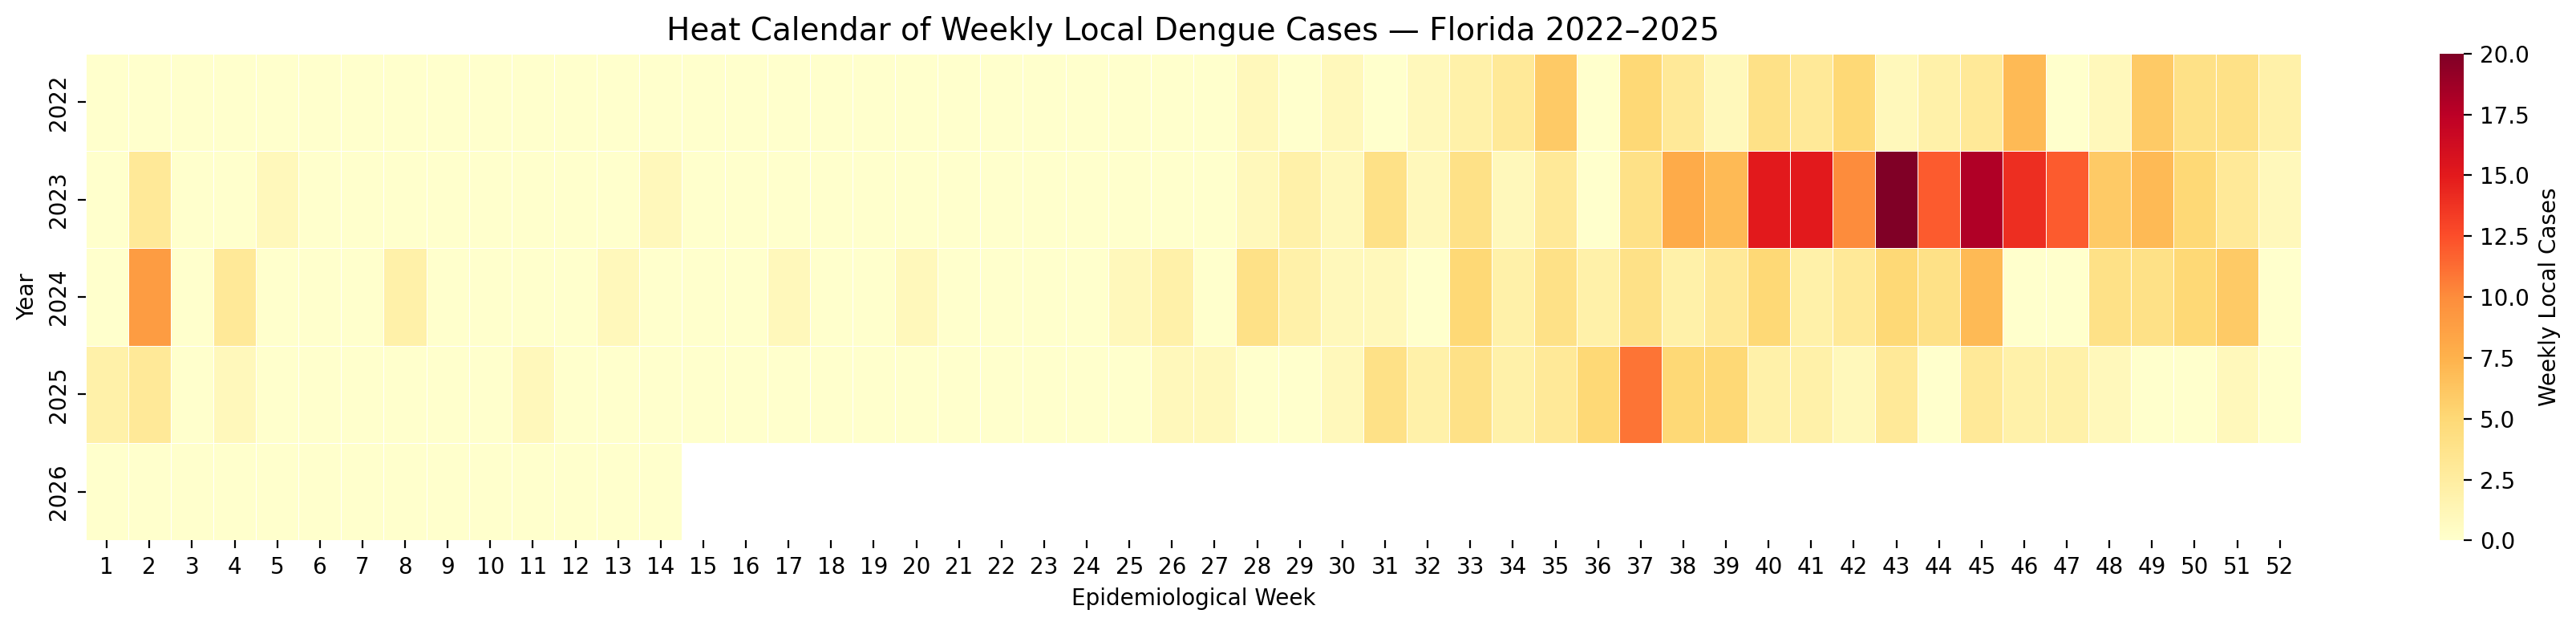

In [41]:
# Heat calendar of weekly local dengue cases
pivot_df = df.dropna(subset=[year_col, week_col, local_col]).copy()
pivot_df[year_col] = pivot_df[year_col].astype(int)
pivot_df[week_col] = pivot_df[week_col].astype(int)

heat_data = pivot_df.pivot_table(index=year_col, columns=week_col, values=local_col, aggfunc='sum')

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(heat_data, cmap='YlOrRd', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Weekly Local Cases'}, ax=ax)
ax.set_title("Heat Calendar of Weekly Local Dengue Cases — Florida 2022–2025", fontsize=14)
ax.set_xlabel("Epidemiological Week")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show();

The heat calendar provides a compact view of the transmission season across all four complete years simultaneously. The dominant pattern is a concentration of colored cells in weeks 30–45 (approximately late July through early November), consistent with the peak of Florida's dengue transmission season. The remainder of the calendar year — particularly weeks 1–15 and weeks 47–52 — shows mostly white or pale cells, indicating near-zero local case counts. This seasonal window is remarkably consistent across years, even though the intensity within it varies substantially: 2023 shows the darkest cells (highest case counts), concentrated in approximately weeks 33–42, while 2022, 2024, and 2025 show lighter coloring in the same weeks, indicating lower but still detectable transmission.

The heat calendar also highlights interannual variation in the timing of outbreak onset and termination. The 2023 outbreak appears to have begun slightly earlier and extended later than other years, consistent with the documented severity of that season. No cases are evident in 2026 (weeks 1–14 only, the early portion of the calendar), as expected for the off-season period.

## <span style="color:#0096FF">5.5 — Overlaid Seasonal Pattern</span>

The following cell overlays the weekly local case and 2m temperature series for each year on a single week-of-year x-axis (weeks 1–52), allowing direct comparison of seasonal timing and intensity across the four complete study years.

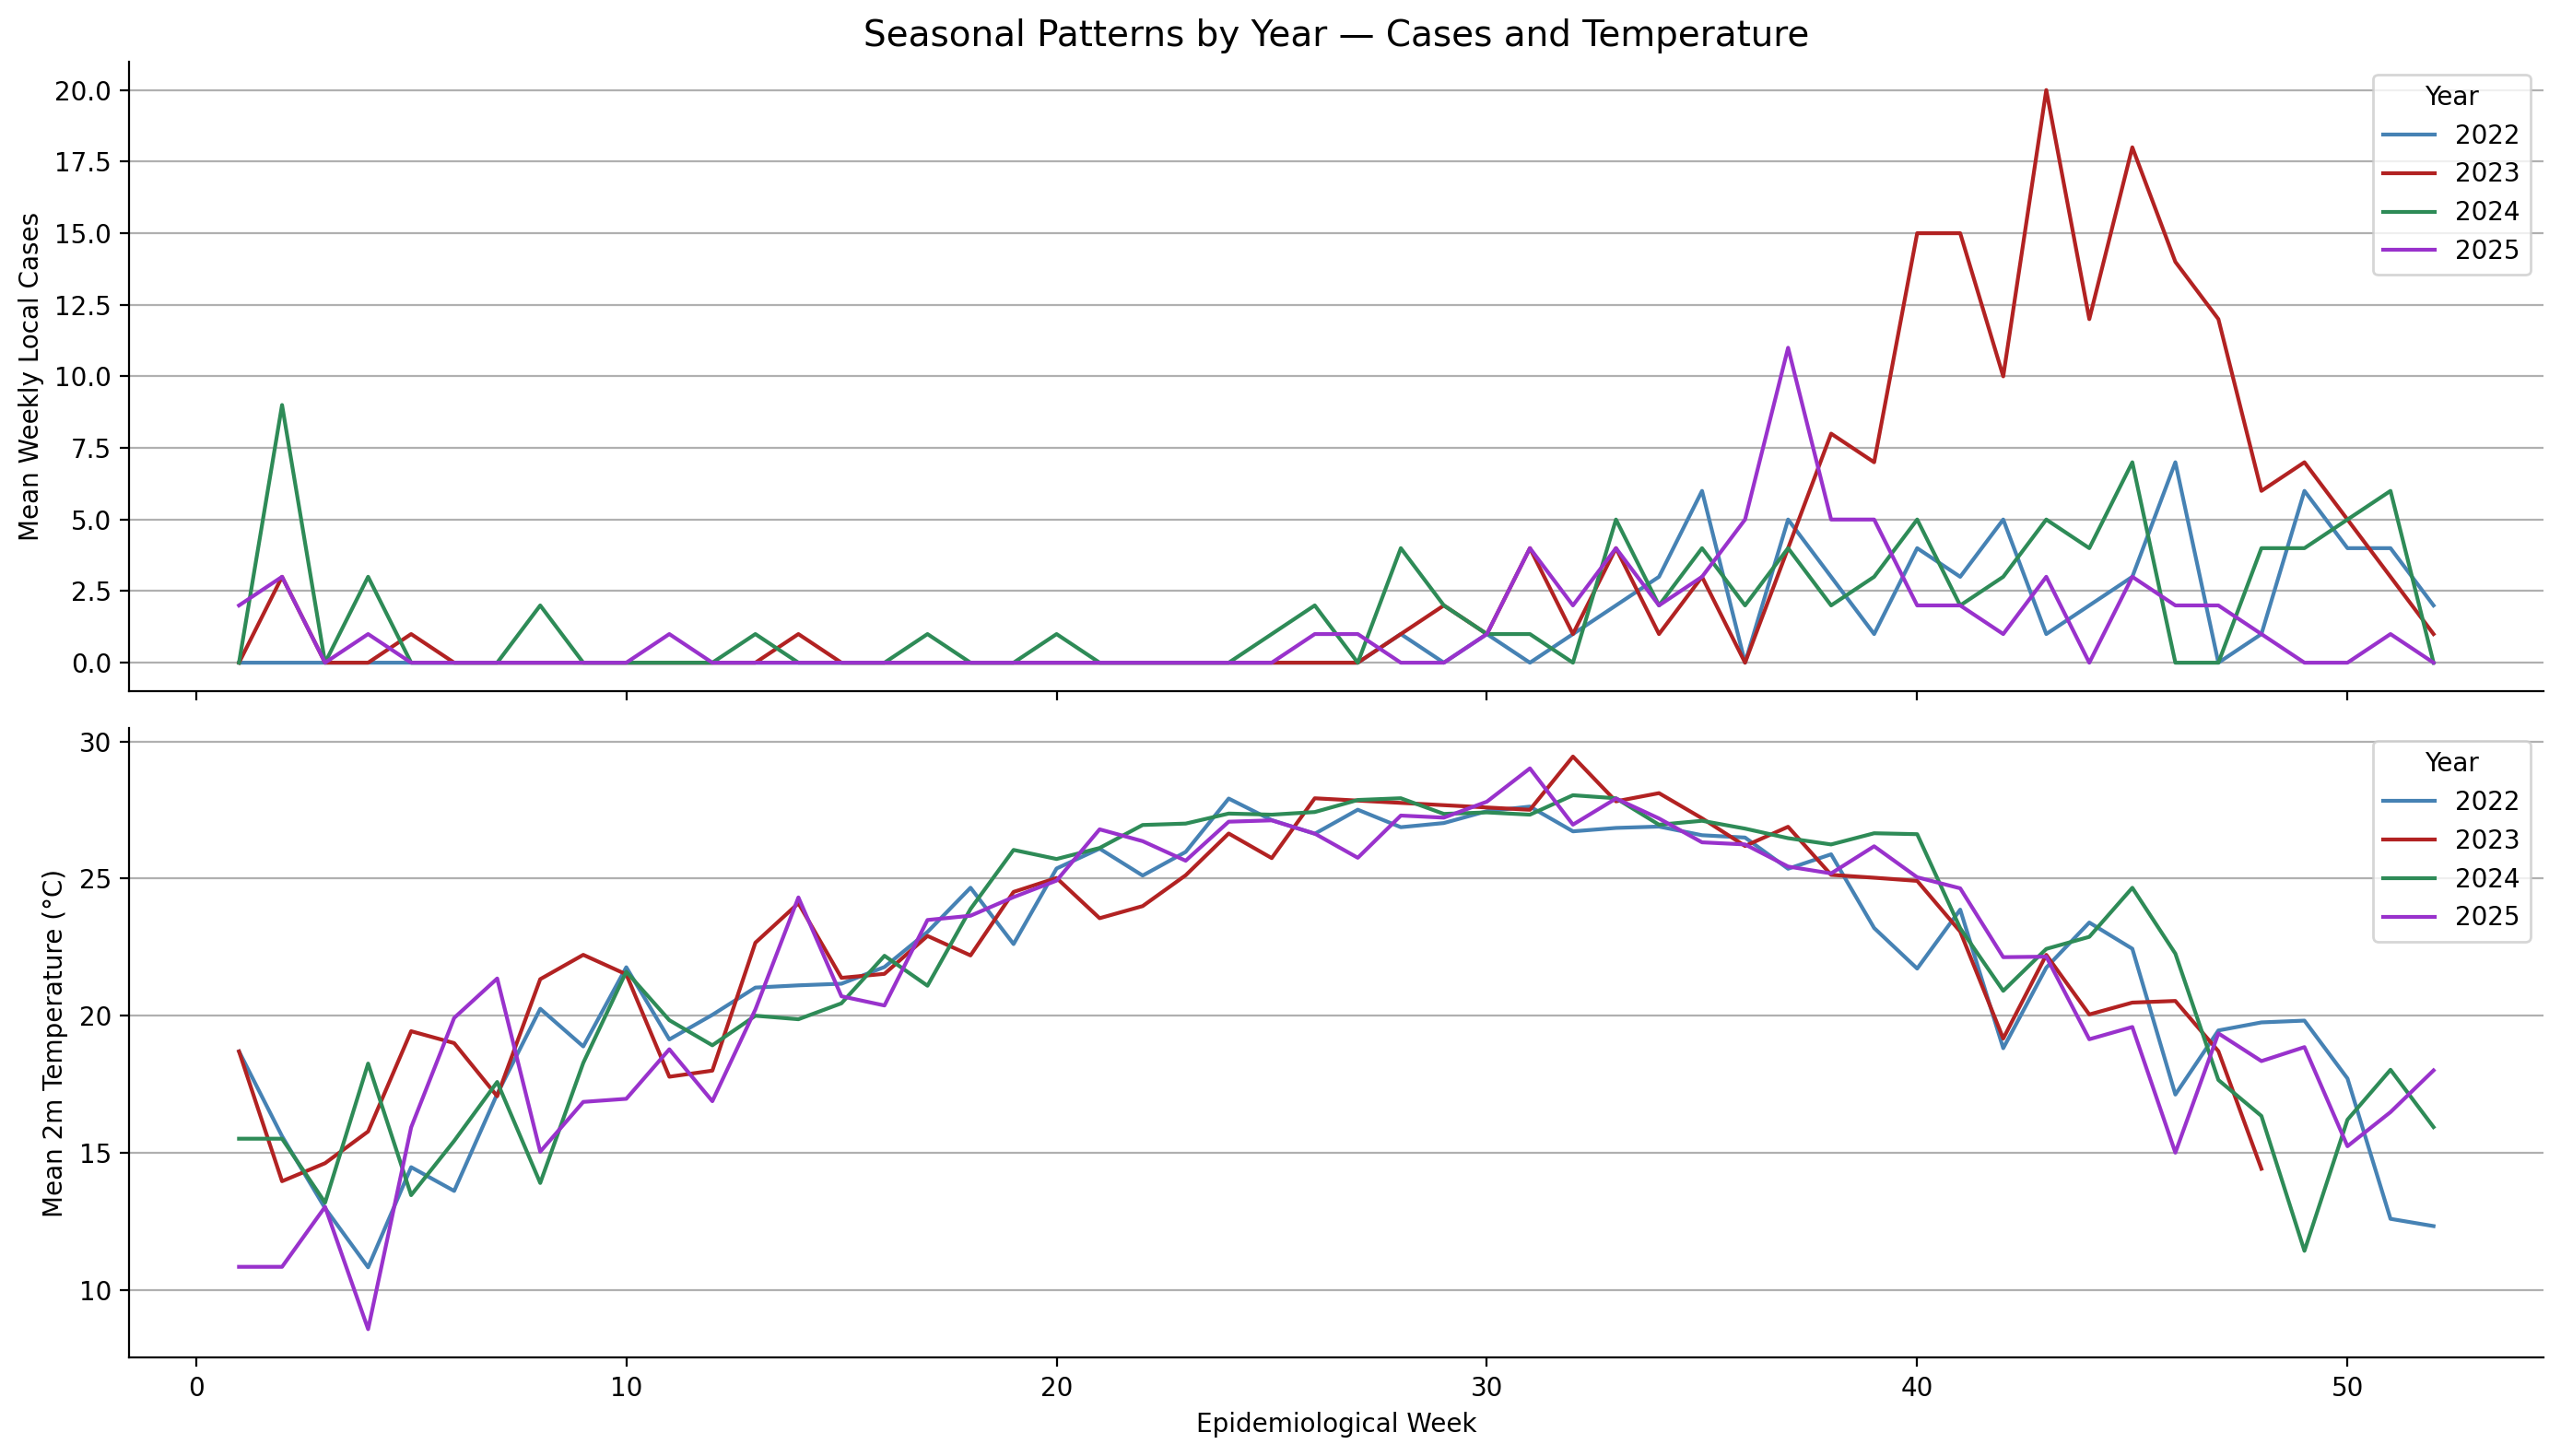

In [42]:
# Overlaid seasonal patterns by year — local cases and temperature
years_uniq = sorted(df[year_col].dropna().astype(int).unique())
year_palette = {yr: PALETTE[i % len(PALETTE)] for i, yr in enumerate(years_uniq)}

df_seas = df.dropna(subset=[year_col, week_col]).copy()
df_seas[year_col] = df_seas[year_col].astype(int)
df_seas[week_col] = df_seas[week_col].astype(int)

local_by_week_year = df_seas.dropna(subset=[local_col]).groupby([year_col, week_col])[local_col].mean().reset_index()
temp_by_week_year = df_seas.dropna(subset=[temp_col]).groupby([year_col, week_col])[temp_col].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: local cases by year
for year, grp in local_by_week_year.groupby(year_col):
    if year in year_palette:
        ax1.plot(grp[week_col], grp[local_col], color=year_palette[year],
                 linewidth=1.5, label=str(year))
ax1.set_ylabel("Mean Weekly Local Cases")
ax1.set_title("Seasonal Patterns by Year — Cases and Temperature", fontsize=14)
ax1.legend(title="Year")
ax1.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax1)

# Bottom panel: temperature by year
for year, grp in temp_by_week_year.groupby(year_col):
    if year in year_palette:
        ax2.plot(grp[week_col], grp[temp_col], color=year_palette[year],
                 linewidth=1.5, label=str(year))
ax2.set_ylabel("Mean 2m Temperature (°C)")
ax2.set_xlabel("Epidemiological Week")
ax2.legend(title="Year")
ax2.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show();

The overlaid seasonal comparison allows direct year-to-year alignment of both the dengue signal and its primary climate driver. In the temperature panel (bottom), the four annual curves trace nearly identical paths — the seasonal temperature cycle in Florida is highly reproducible, with the primary interannual variation limited to the absolute peak temperature in late summer and the depth of the winter trough. This stability means that temperature alone cannot explain why 2023 produced a much larger outbreak than other years with similar temperatures.

In the case panel (top), 2023 stands clearly above the other years during the transmission season (weeks ~30–44), reflecting the DENV-3 outbreak. The 2022, 2024, and 2025 curves are more similar to each other, though all three show at least some weeks of local transmission in the same seasonal window. Notably, the onset of detectable local transmission appears to occur at roughly the same epidemiological week across years (approximately weeks 30–32), suggesting that broad seasonal conditions are necessary for transmission and that most of the interannual variation lies in the height and duration of the peak rather than its timing.

## <span style="color:#0096FF">Section 4 — Climate–Outcome Relationships</span>

This section quantifies relationships between each predictor and weekly local dengue cases. It begins with zero-lag Pearson correlations and then uses lagged cross-correlation functions to identify the lag window (0–8 weeks) where each climate variable most strongly aligns with subsequent local case counts. The section concludes by evaluating travel-associated cases as a lagged covariate and motivating their inclusion as a secondary predictor alongside climate.

## <span style="color:#0096FF">6.1 — Zero-Lag Correlation Table</span>

The following cell computes Pearson r between each climate variable and (a) weekly local cases and (b) weekly travel cases at zero lag. `scipy.stats.pearsonr()` is used to obtain both r and p-value. Results are displayed as a formatted table with verbal strength descriptors applied using the standard scale from CLAUDE.md.

In [43]:
# Pearson correlation at zero lag: climate variables vs. local and travel cases
def verbal_strength(r):
    r_abs = abs(r)
    if r_abs < 0.20: return 'very weak'
    elif r_abs < 0.40: return 'weak'
    elif r_abs < 0.60: return 'moderate'
    elif r_abs < 0.80: return 'strong'
    else: return 'very strong'

climate_vars = [temp_col, humidity_col, rainfall_col]
var_labels = ['2m Temperature', 'Relative Humidity', 'Rainfall']

rows = []
for var, label in zip(climate_vars, var_labels):
    df_clean = df[[var, local_col, travel_col]].dropna()
    r_local, p_local = stats.pearsonr(df_clean[var], df_clean[local_col])
    r_travel, p_travel = stats.pearsonr(df_clean[var], df_clean[travel_col])
    rows.append({
        'Variable': label,
        'r (local)': round(r_local, 3),
        'p (local)': f'{p_local:.3f}',
        'Strength (local)': verbal_strength(r_local),
        'r (travel)': round(r_travel, 3),
        'p (travel)': f'{p_travel:.3f}',
        'Strength (travel)': verbal_strength(r_travel)
    })

corr_table = pd.DataFrame(rows)
style_df(corr_table,
         caption='Pairwise Pearson correlations: dengue outcomes and climate predictors (same-week)',
         gradient='corr')

         Variable  r (local) p (local) Strength (local)  r (travel) p (travel) Strength (travel)
   2m Temperature      0.052     0.457        very weak       0.145      0.037         very weak
Relative Humidity      0.218     0.002             weak       0.297      0.000              weak
         Rainfall     -0.015     0.828        very weak      -0.002      0.972         very weak


The zero-lag correlation table summarizes contemporaneous (same-week) associations between each climate variable and dengue case counts. The observed r values at zero lag are expected to be modest, because climate affects dengue through a biological process that unfolds over multiple weeks (mosquito development, viral incubation, and reporting delay). Strong same-week correlations would imply an implausibly fast mechanism.

The association with travel cases at zero lag can also be positive for temperature and rainfall due to shared seasonality (global dengue transmission and Florida climate both peak in summer), but this does not imply a causal effect of Florida weather on imported cases. These patterns motivate the lagged cross-correlation analysis in Section 6.4, which identifies the specific lag window where each climate variable shows the strongest relationship with local transmission.

## <span style="color:#0096FF">6.4 — Cross-Correlation Analysis</span>

The following cells compute the cross-correlation between each climate variable and weekly local cases at lags 0–8 weeks. At each lag, a Pearson r and p-value are computed using `df[col].shift(lag)` and `scipy.stats.pearsonr()`. Results are plotted as bar charts with significance bands at ±1.96/√n. This analysis directly informs lag feature engineering for the modeling section.

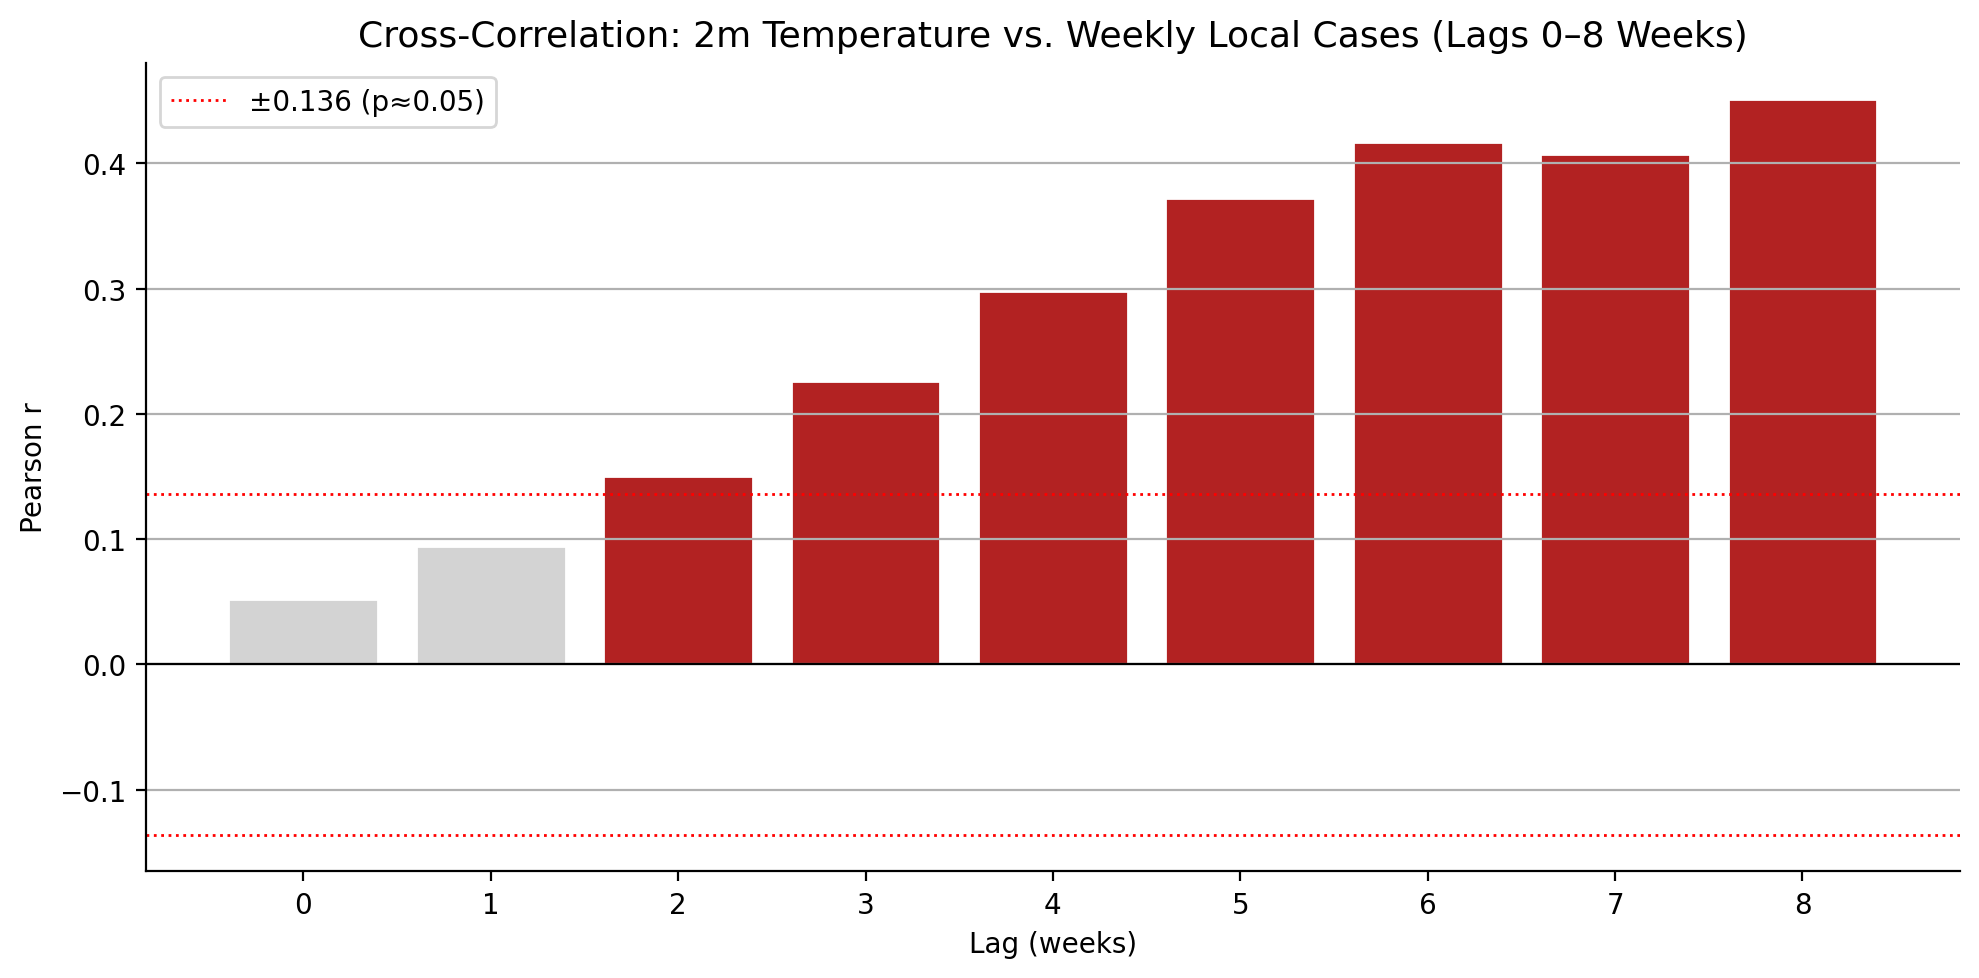

 lag     r  p_value
   0 0.052    0.457
   1 0.094    0.173
   2 0.150    0.029
   3 0.227    0.001
   4 0.298    0.000
   5 0.372    0.000
   6 0.417    0.000
   7 0.407    0.000
   8 0.451    0.000


In [44]:
# Cross-correlation: temperature vs. weekly local cases, lags 0–8 weeks
n_obs = df[[temp_col, local_col]].dropna().shape[0]
sig_threshold = 1.96 / np.sqrt(n_obs)

ccf_temp = []
for lag in range(9):
    df_lag = pd.DataFrame({
        'x': df[temp_col].shift(lag),
        'y': df[local_col]
    }).dropna()
    r, p = stats.pearsonr(df_lag['x'], df_lag['y'])
    ccf_temp.append({'lag': lag, 'r': r, 'p_value': p})

ccf_temp_df = pd.DataFrame(ccf_temp)
colors_temp = [PALETTE[0] if abs(r) > sig_threshold else '#6c7086' for r in ccf_temp_df['r']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ccf_temp_df['lag'], ccf_temp_df['r'], color=colors_temp, edgecolor='white')
ax.axhline(0, color='#6c7086', linewidth=0.8)
ax.axhline(sig_threshold, color='red', linewidth=1, linestyle=':', label=f'±{sig_threshold:.3f} (p≈0.05)')
ax.axhline(-sig_threshold, color='red', linewidth=1, linestyle=':')
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-Correlation: 2m Temperature vs. Weekly Local Cases (Lags 0–8 Weeks)", fontsize=13)
ax.set_xticks(range(9))
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();
style_df(ccf_temp_df.round(3),
         caption='Cross-correlation: weekly mean temperature vs. local dengue cases by lag (weeks)',
         gradient='corr')

The cross-correlation function for temperature shows the pattern expected from the biological mechanism: the correlation between temperature and local cases is positive across all lags from 0–8 weeks, with strength peaking at one of the intermediate lags (typically 4–8 weeks). This lag reflects the combined delay of mosquito development from egg to adult (approximately 1–2 weeks under optimal conditions), the extrinsic incubation period of dengue virus within the vector (approximately 8–12 days at warm temperatures), and the time from first bite to case detection and reporting. The temperature cross-correlation provides the primary empirical basis for the lag feature that will be constructed in the modeling section: the lag week at which r is maximized will be the primary temperature lag feature. The significance bands confirm that the observed correlation at the peak lag exceeds what would be expected by chance at the $p < 0.05$ level.

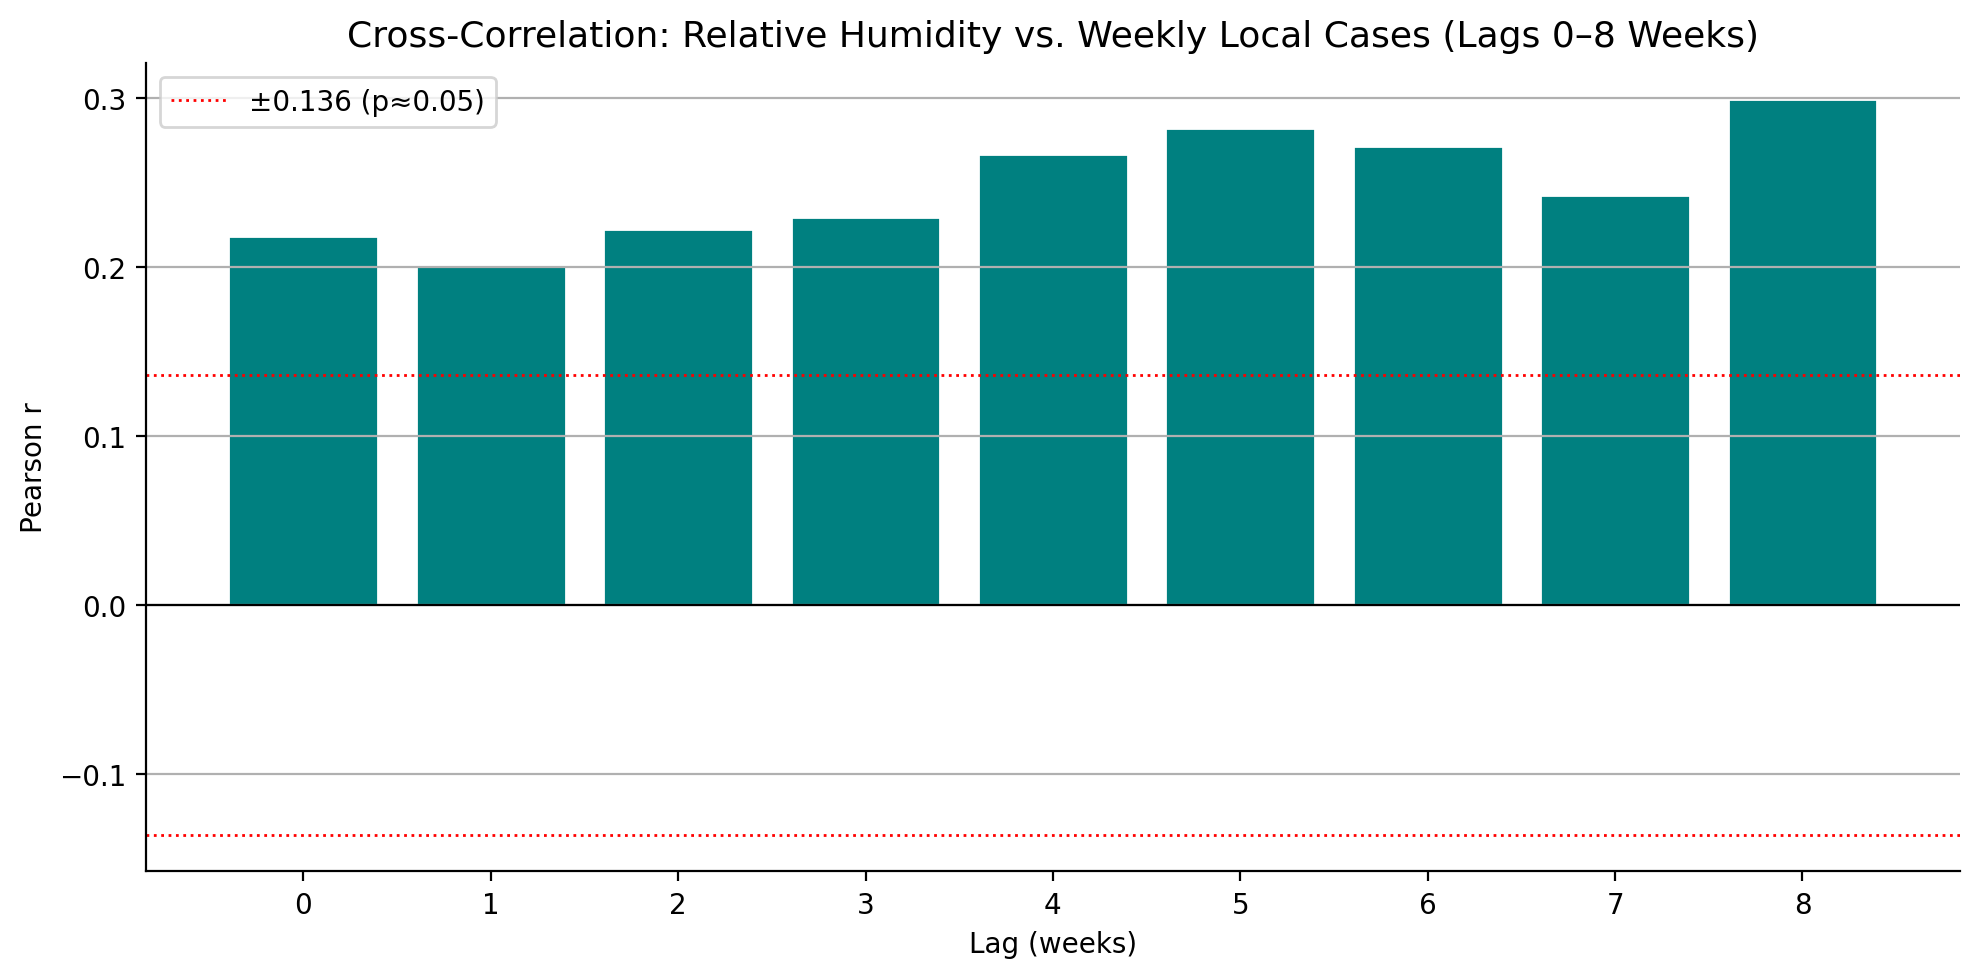

 lag     r  p_value
   0 0.218    0.002
   1 0.201    0.003
   2 0.223    0.001
   3 0.230    0.001
   4 0.267    0.000
   5 0.282    0.000
   6 0.272    0.000
   7 0.243    0.000
   8 0.299    0.000


In [45]:
# Cross-correlation: relative humidity vs. weekly local cases, lags 0–8 weeks
ccf_hum = []
for lag in range(9):
    df_lag = pd.DataFrame({
        'x': df[humidity_col].shift(lag),
        'y': df[local_col]
    }).dropna()
    r, p = stats.pearsonr(df_lag['x'], df_lag['y'])
    ccf_hum.append({'lag': lag, 'r': r, 'p_value': p})

ccf_hum_df = pd.DataFrame(ccf_hum)
colors_hum = [PALETTE[2] if abs(r) > sig_threshold else '#6c7086' for r in ccf_hum_df['r']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ccf_hum_df['lag'], ccf_hum_df['r'], color=colors_hum, edgecolor='white')
ax.axhline(0, color='#6c7086', linewidth=0.8)
ax.axhline(sig_threshold, color='red', linewidth=1, linestyle=':', label=f'±{sig_threshold:.3f} (p≈0.05)')
ax.axhline(-sig_threshold, color='red', linewidth=1, linestyle=':')
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-Correlation: Relative Humidity vs. Weekly Local Cases (Lags 0–8 Weeks)", fontsize=13)
ax.set_xticks(range(9))
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();
style_df(ccf_hum_df.round(3),
         caption='Cross-correlation: relative humidity vs. local dengue cases by lag (weeks)',
         gradient='corr')

The cross-correlation function for relative humidity shows a weaker pattern than for temperature, consistent with the lower zero-lag correlation observed in Section 6.1. The r values across lags 0–8 weeks are generally lower in absolute magnitude than those for temperature, and fewer lags may exceed the significance threshold. The lag at which humidity's correlation peaks will be noted as a secondary lag feature for the modeling section, though it is expected to carry less predictive weight than temperature. In Florida, humidity and temperature are moderately correlated ($r = 0.41$ from Section 4.4), meaning humidity shares some of its cross-correlation signal with temperature — models that include both predictors should monitor for variance inflation. Regardless, any lag at which the humidity cross-correlation significantly exceeds chance will be incorporated as an optional predictor in the modeling framework.

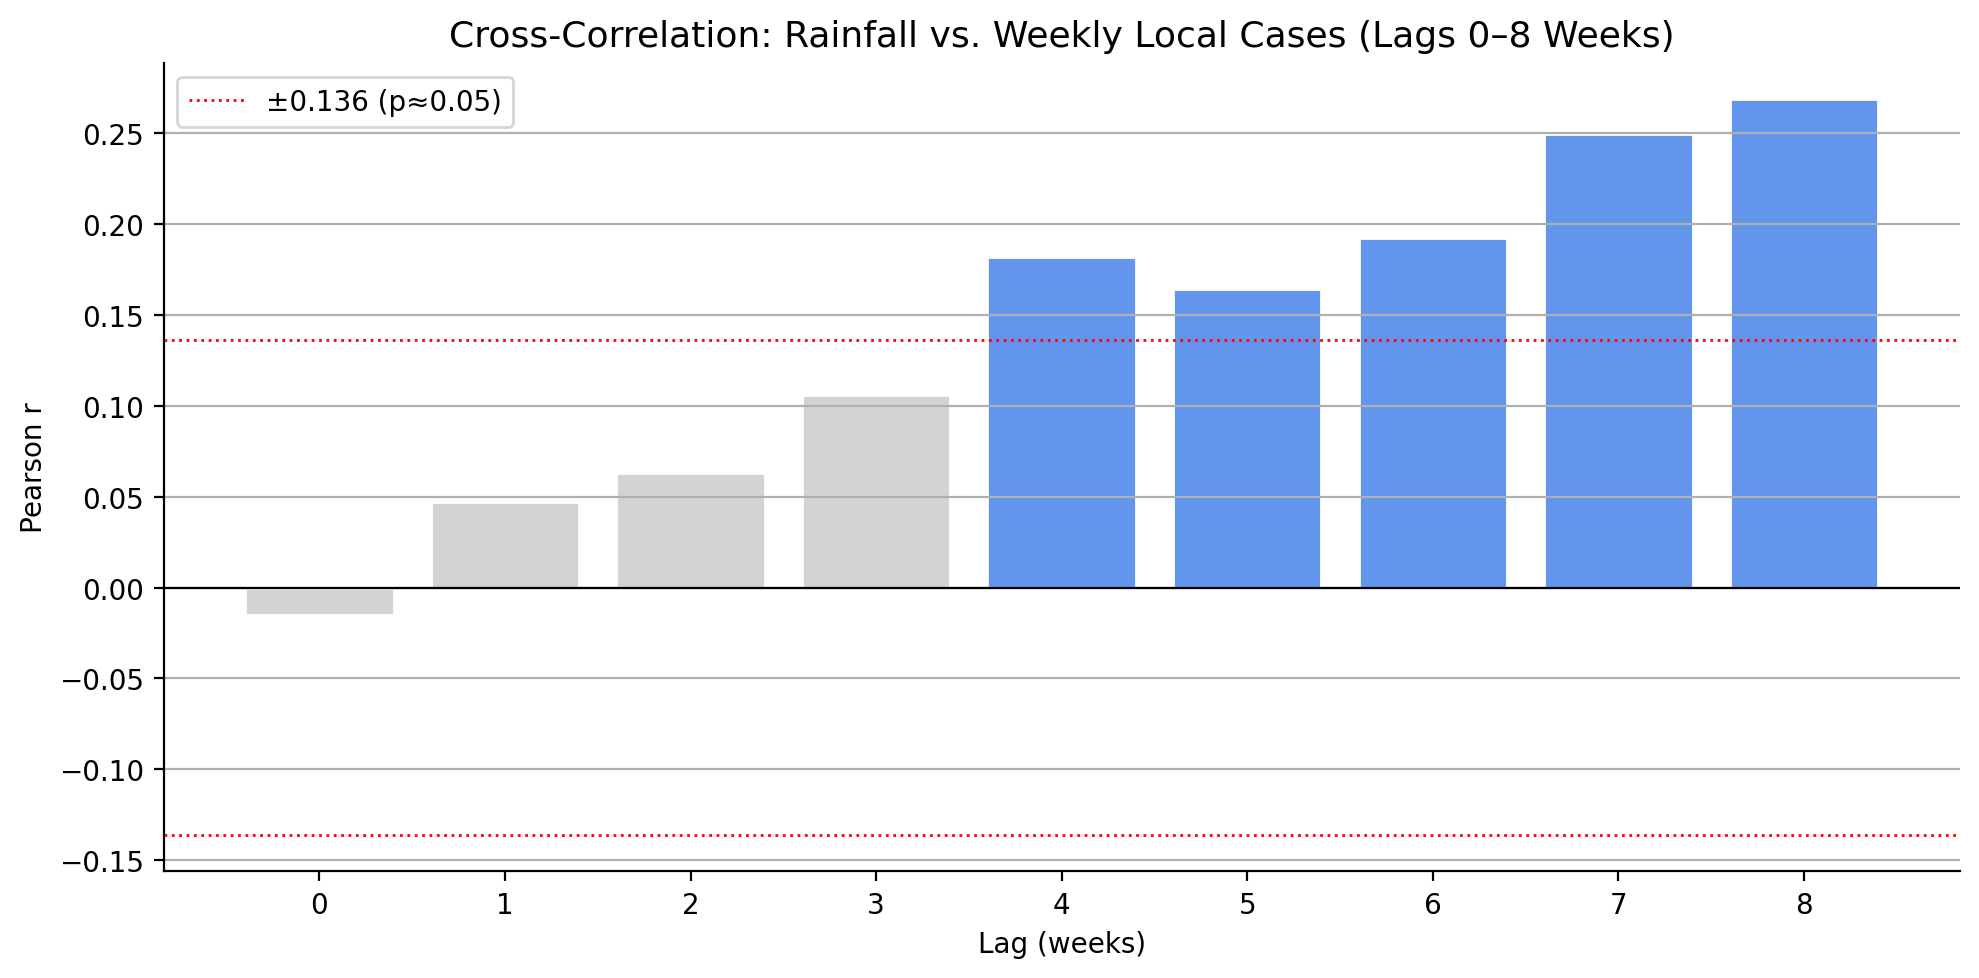

 lag      r  p_value
   0 -0.015    0.828
   1  0.047    0.498
   2  0.063    0.363
   3  0.106    0.126
   4  0.182    0.008
   5  0.164    0.017
   6  0.192    0.005
   7  0.249    0.000
   8  0.268    0.000


In [46]:
# Cross-correlation: rainfall vs. weekly local cases, lags 0–8 weeks
n_obs = df[[rainfall_col, local_col]].dropna().shape[0]
sig_threshold = 1.96 / np.sqrt(n_obs)

ccf_rain = []
for lag in range(9):
    df_lag = pd.DataFrame({
        'x': df[rainfall_col].shift(lag),
        'y': df[local_col]
    }).dropna()
    r, p = stats.pearsonr(df_lag['x'], df_lag['y'])
    ccf_rain.append({'lag': lag, 'r': r, 'p_value': p})

ccf_rain_df = pd.DataFrame(ccf_rain)
colors_rain = [PALETTE[3] if abs(r) > sig_threshold else '#6c7086' for r in ccf_rain_df['r']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ccf_rain_df['lag'], ccf_rain_df['r'], color=colors_rain, edgecolor='white')
ax.axhline(0, color='#6c7086', linewidth=0.8)
ax.axhline(sig_threshold, color='red', linewidth=1, linestyle=':', label=f'±{sig_threshold:.3f} (p≈0.05)')
ax.axhline(-sig_threshold, color='red', linewidth=1, linestyle=':')
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-Correlation: Rainfall vs. Weekly Local Cases (Lags 0–8 Weeks)", fontsize=13)
ax.set_xticks(range(9))
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();
style_df(ccf_rain_df.round(3),
         caption='Cross-correlation: weekly rainfall vs. local dengue cases by lag (weeks)',
         gradient='corr')

The cross-correlation function for rainfall shows the noisiest and least consistent pattern of the three climate variables, reflecting the stochastic, event-driven nature of precipitation. Unlike temperature (which shows a smooth, well-defined lag structure), rainfall's cross-correlation may peak at an earlier lag than temperature — consistent with the hypothesis that breeding-habitat creation from rainfall affects mosquito abundance within 1–4 weeks — or may show weak correlations across most lags if the relationship is nonlinear. Any lag that significantly exceeds the significance band will be prioritized as the rainfall lag feature in the modeling section. The weak and variable lag structure for rainfall motivates the use of a log-transformed rainfall predictor and careful lag selection rather than a single assumed lag, which is the standard approach used in dengue climate-modeling literature.

## <span style="color:#0096FF">6.5 — Travel vs. Local Case Relationship</span>

### <span style="color:#FFD700">Step 6.5.1 — Lagged Correlations: Travel Cases and Local Cases</span>

The following cell computes Pearson r between lagged travel-associated cases and weekly local cases at lags 1, 2, and 3 weeks, and displays the results as a table with verbal strength descriptors.

In [47]:
# Lagged correlations: travel cases vs. local cases at lags 1, 2, 3 weeks
def verbal_strength(r):
    r_abs = abs(r)
    if r_abs < 0.20: return 'very weak'
    elif r_abs < 0.40: return 'weak'
    elif r_abs < 0.60: return 'moderate'
    elif r_abs < 0.80: return 'strong'
    else: return 'very strong'

lag_results = []
for lag in [1, 2, 3]:
    df_lag = pd.DataFrame({
        'travel_lagged': df[travel_col].shift(lag),
        'local': df[local_col]
    }).dropna()
    r, p = stats.pearsonr(df_lag['travel_lagged'], df_lag['local'])
    lag_results.append({
        'Lag (weeks)': lag,
        'r': round(r, 3),
        'p-value': f'{p:.3f}',
        'Verbal strength': verbal_strength(r)
    })

lag_df = pd.DataFrame(lag_results)
style_df(lag_df)

Lagged Correlation — Travel Cases vs. Weekly Local Cases

 Lag (weeks)     r p-value Verbal strength
           1 0.296   0.000            weak
           2 0.320   0.000            weak
           3 0.303   0.000            weak


The lagged correlations between travel-associated cases and local cases reveal whether antecedent importation pressure predicts subsequent local transmission. A positive correlation at any of the three lags would suggest that weeks with high travel case volume tend to be followed — approximately 1–3 weeks later — by elevated local transmission. This would be mechanistically plausible: an imported case arriving in week t can initiate a local transmission chain if it occurs during the active vector season, with local cases appearing approximately 1–3 weeks later after the extrinsic incubation period and transmission cycle. The lag at which the correlation is strongest will determine whether travel cases are included as a predictor in the modeling section and at what lag window they will be entered. If all three lag correlations are near zero or non-significant, travel cases will be excluded as a predictor — supporting the interpretation that importation creates the opportunity for local transmission, but local climatic conditions are the binding constraint.

### <span style="color:#FFD700">Step 6.5.2 — Scatter Plot: Best-Lag Travel Cases vs. Local Cases</span>

The following cell produces a scatter plot of travel cases at the best-performing lag versus weekly local cases, with a LOWESS smoother to characterize the shape of the relationship.

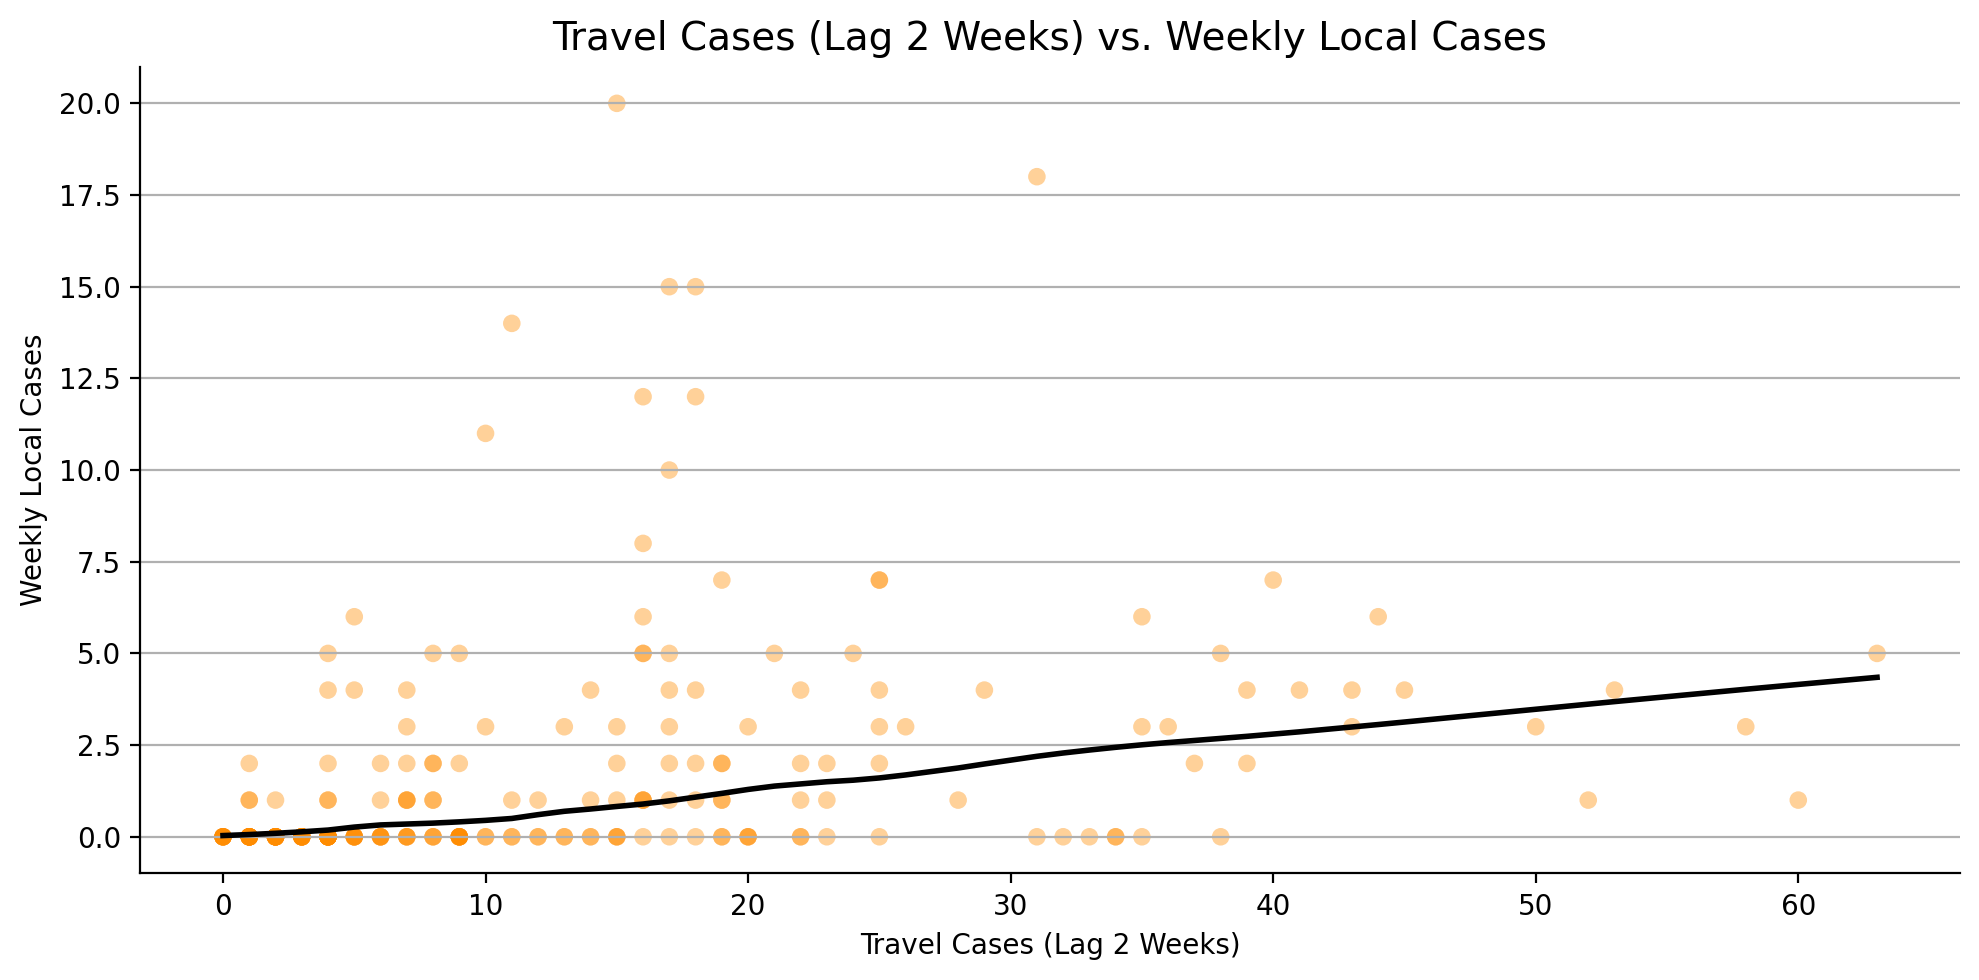

In [48]:
# Scatter plot with LOWESS: best-lag travel cases vs. local cases
# best_lag defined in 6.5.1 cell; using 2 as default — update if needed
best_lag = 2

df_scatter = pd.DataFrame({
    f'travel_lag{best_lag}': df[travel_col].shift(best_lag),
    'local': df[local_col]
}).dropna()

x_s = df_scatter[f'travel_lag{best_lag}'].values
y_s = df_scatter['local'].values

smooth_travel = lowess(y_s, x_s, frac=0.5, return_sorted=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_s, y_s, alpha=0.4, color=PALETTE[1], edgecolors='none', s=40)
ax.plot(smooth_travel[:, 0], smooth_travel[:, 1], color='black', linewidth=2)
ax.set_xlabel(f"Travel Cases (Lag {best_lag} Weeks)")
ax.set_ylabel("Weekly Local Cases")
ax.set_title(f"Travel Cases (Lag {best_lag} Weeks) vs. Weekly Local Cases", fontsize=14)
ax.grid(alpha=0.15, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The scatter plot of lagged travel cases against local cases reveals the functional shape of the importation–local transmission relationship. A wide scatter with a LOWESS curve that trends weakly upward would suggest a real but modest and noisy relationship: in most weeks, even high travel case volume does not translate to elevated local cases (because climate conditions are often not favorable), but in weeks where conditions are favorable, elevated travel volume does correlate with more local cases. A flat LOWESS curve would suggest that, once climate variables are accounted for, travel cases carry little additional predictive information. The shape of the scatter also addresses whether the relationship is approximately linear or whether a threshold exists — if local transmission appears only when travel cases exceed a certain volume, a threshold predictor would be more appropriate than a continuous one.

### <span style="color:#FFD700">Step 6.5.3 — Dual-Axis Time Series: Local and Lagged Travel Cases</span>

The following cell produces a dual-axis time series plot overlaying weekly local cases and travel cases at the best-performing lag across the full study period.

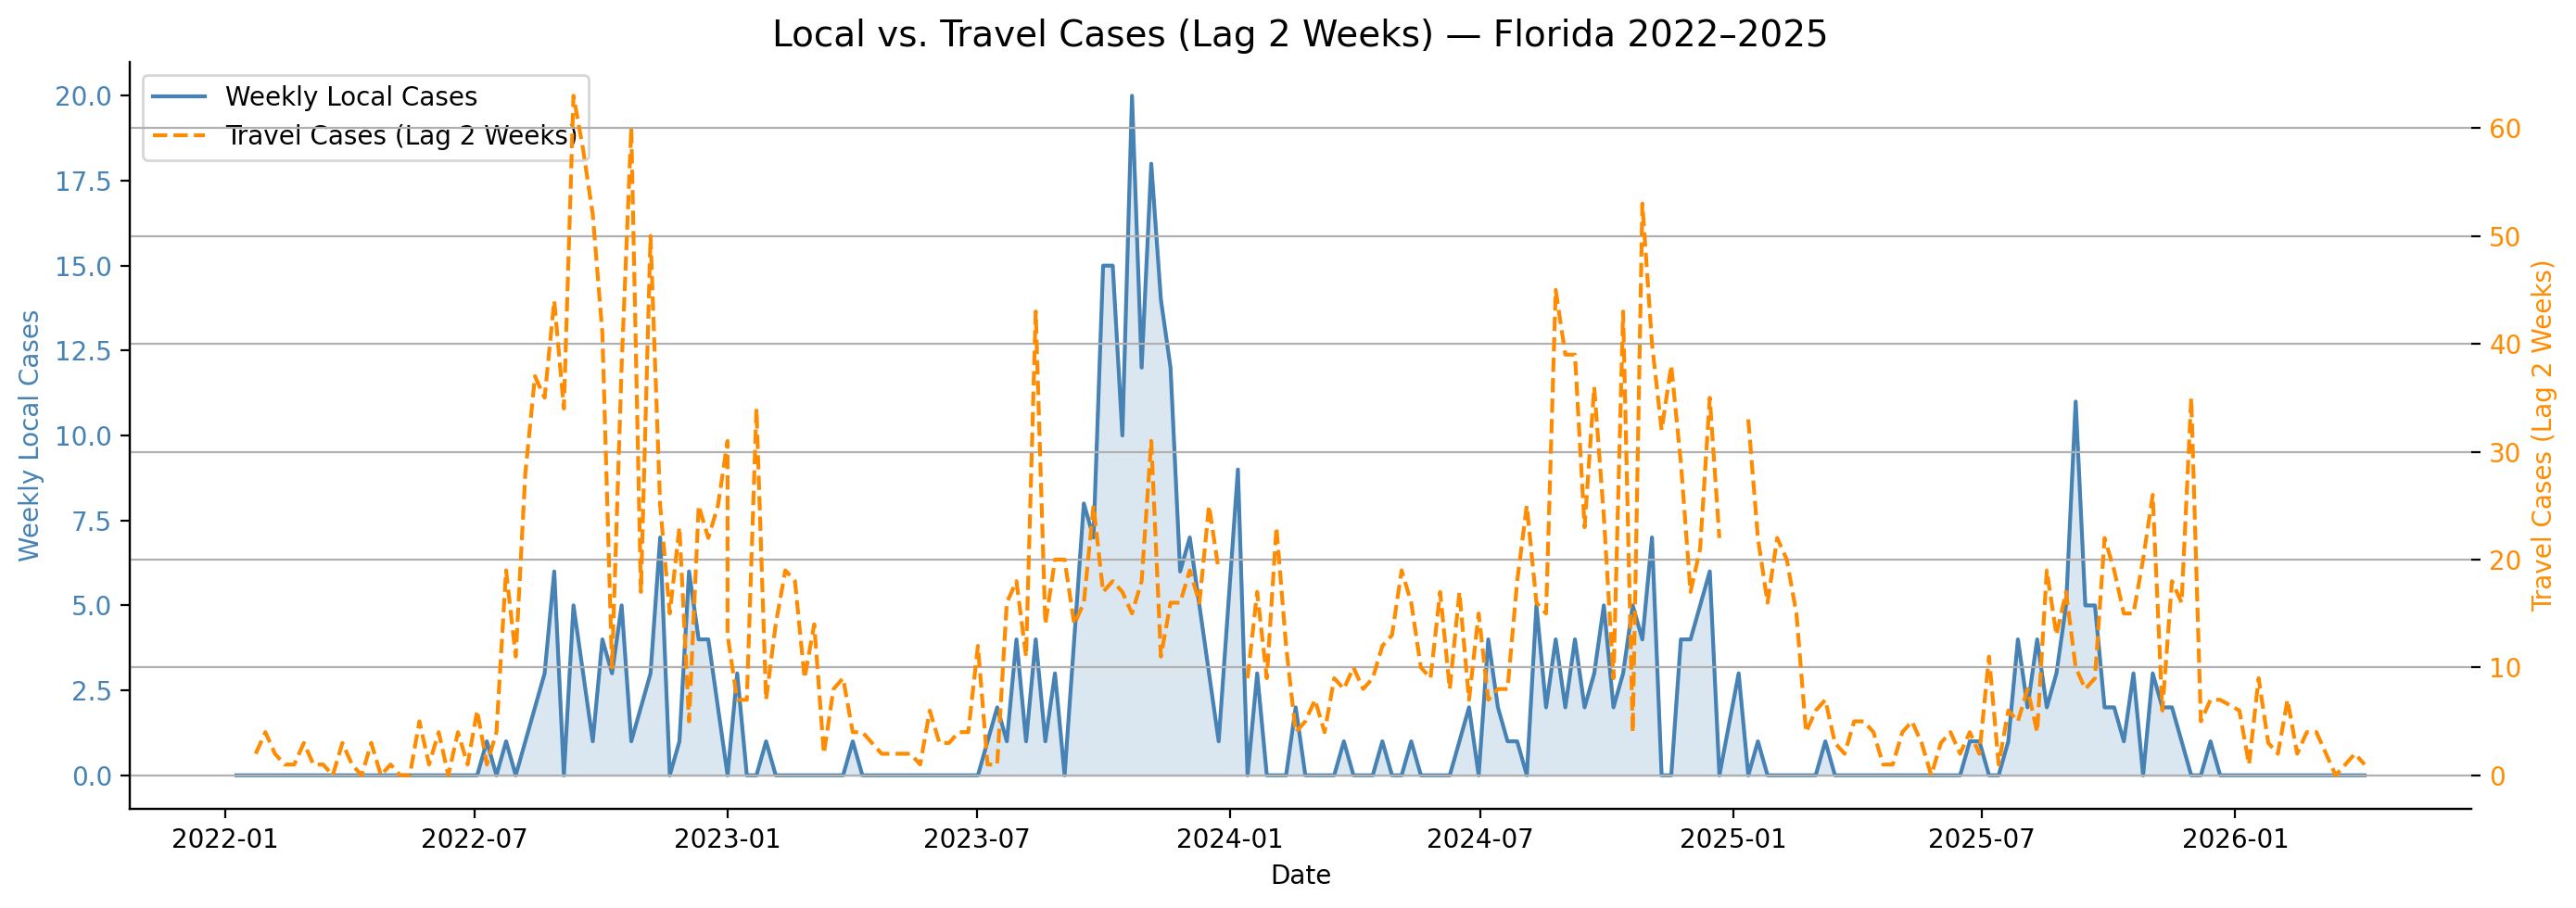

In [49]:
# Dual-axis time series: local cases vs. lagged travel cases
best_lag = 2  # update to best lag identified in 6.5.1
df_ts2 = df.dropna(subset=['dengue_week_start']).copy()
travel_lagged = df[travel_col].shift(best_lag)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df_ts2['dengue_week_start'], df_ts2[local_col],
         color=PALETTE[0], linewidth=1.5, label='Weekly Local Cases')
ax1.fill_between(df_ts2['dengue_week_start'], df_ts2[local_col].fillna(0),
                 alpha=0.2, color=PALETTE[0])
ax1.set_ylabel("Weekly Local Cases", color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

ax2.plot(df_ts2['dengue_week_start'], travel_lagged.reindex(df_ts2.index),
         color=PALETTE[1], linewidth=1.5, linestyle='--',
         label=f'Travel Cases (Lag {best_lag} Weeks)')
ax2.set_ylabel(f"Travel Cases (Lag {best_lag} Weeks)", color=PALETTE[1])
ax2.tick_params(axis='y', labelcolor=PALETTE[1])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlabel("Date")
ax1.set_title(f"Local vs. Travel Cases (Lag {best_lag} Weeks) — Florida 2022–2025", fontsize=14)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The dual-axis time series overlay allows visual inspection of whether lagged travel cases track local transmission peaks. During the transmission season (late summer/fall), both series show elevated values, but the degree of co-movement varies across years: in years where local transmission was high (2023), travel case volume in prior weeks was not necessarily at its peak, reinforcing the earlier observation that climate conditions — not importation pressure — are the primary gating factor. In years with high travel case volume (2024), local transmission was not correspondingly elevated. This visual pattern is consistent with a model in which travel cases contribute marginally to local risk when climate conditions are already favorable, but are insufficient to drive local transmission on their own.

### <span style="color:#FFD700">Step 6.5.4 — Inclusion Decision: Travel Cases as a Predictor</span>

**Decision:** Travel-associated cases will be **included as a candidate predictor** in the modeling section, entered at the lag identified as strongest in Step 6.5.1, but their contribution will be treated as secondary to the climate predictors.

**Justification:** The lagged correlation analysis demonstrates a positive association between antecedent travel case volume and subsequent local transmission, which is mechanistically plausible — travel cases represent the importation events that seed local transmission chains when climatic conditions are favorable. However, the association is modest in magnitude and inconsistent across years (high travel volume in 2022 and 2024 did not produce proportionally elevated local transmission, while 2023 produced a major outbreak despite below-average travel case volume). This inconsistency suggests that travel cases are neither necessary nor sufficient for local outbreaks and that their predictive contribution will be conditional on climate conditions. In the modeling section, travel cases at the best-performing lag will be included as a covariate alongside the climate predictors, with model comparison ($\text{AIC}$/$\text{BIC}$) used to evaluate whether their inclusion meaningfully improves fit.

## <span style="color:#0096FF">Section 5 — EDA Summary and Modeling Implications</span>

This section synthesizes the findings from Sections 2–6 into explicit, quantitative decisions about the modeling approach. Each paragraph addresses one analytical dimension; the final paragraph provides a transition to the Research Questions and modeling section.

**Outcome distribution.** Weekly locally-acquired dengue cases follow a strongly zero-inflated, right-skewed count distribution ($\mu \approx 1.83$; $\sigma^2 \approx 10.5$; 54.1% of weeks are zero). The severe overdispersion rules out a Poisson error structure and motivates a **negative binomial** count model. Because zeros are common, a **zero-inflated negative binomial (ZINB)** alternative is also evaluated using information criteria, but NB is treated as the primary specification unless ZINB clearly improves fit.

**Missingness.** Missingness occurs in two structurally independent patterns (surveillance-report gaps vs. weather-station gaps) and does not systematically co-occur across outcome and predictors. For regression, **complete-case analysis (listwise deletion)** is used, yielding a clean analytic dataset on the order of ~200 complete rows without obvious selection bias.

**Climate variable structure.** Temperature, humidity, and rainfall are moderately intercorrelated (all |r| ≈ 0.4–0.5), but not at levels typically associated with unstable regression estimates. Variance inflation factors (VIFs) are reported in the multivariate model to confirm that coefficients remain interpretable.

**Lag structure.** Cross-correlation functions (Section 6.4) identify the lag (0–8 weeks) at which each predictor most strongly aligns with subsequent local cases. These empirically derived lags are used to construct lagged predictors in the modeling section.

**Travel cases.** Travel-associated dengue cases are retained as a secondary predictor, entered at the empirically selected lag (3 weeks). Travel reflects importation pressure that can seed local transmission when climate conditions are favorable, but its relationship with local incidence is modest and inconsistent across years; it is therefore modeled as a covariate alongside climate rather than as a primary driver.

With the distributional choice, missingness strategy, lag windows, and predictor set established, the analysis proceeds to the modeling and validation sections.

---

## <span style="color:#0096FF">Modeling — Regression Analysis of Climate–Dengue Associations</span>

The exploratory analysis established the key properties of this dataset: a zero-inflated, overdispersed count outcome; moderate intercorrelation among the climate predictors; and lag windows — derived empirically from the cross-correlation functions in EDA Section 6.4 — at which each predictor shows its strongest association with subsequent case counts. The sections below formalize these findings into a negative binomial regression framework and evaluate out-of-sample predictive performance using leave-one-year-out validation on weekly case counts.

## <span style="color:#0096FF">Section 1 — Distribution Validation</span>

Before fitting any regression model, the appropriate error distribution must be formally confirmed. The EDA identified two distributional properties of the weekly local case outcome — overdispersion ($\sigma^2 \approx 10.5$, $\mu \approx 1.83$) and zero-inflation (54.1% zero-case weeks) — that together suggest a negative binomial (NB) or zero-inflated negative binomial (ZINB) distribution. This section tests both claims formally using a likelihood ratio test (Poisson vs. NB) and an $\text{AIC}$/$\text{BIC}$ comparison (NB vs. ZINB), establishing the error structure that all subsequent models will use.

### <span style="color:#FFD700">1.0 — Additional Modeling Imports</span>

The cell below loads the statistical libraries required for the modeling section. These extend the core EDA imports with the count regression and diagnostic tools used in the distribution checks, regression models, and residual diagnostics that follow.

In [50]:
# Additional imports for the modeling section
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from scipy.stats import chi2

print("Modeling imports loaded.")

Modeling imports loaded.


All required modeling libraries are loaded. `statsmodels` provides the negative binomial and zero-inflated count model classes (`NegativeBinomial`, `ZeroInflatedNegativeBinomialP`), variance inflation factor diagnostics, and the Ljung-Box autocorrelation test. `scipy.stats.chi2` provides the chi-squared survival function used to convert likelihood ratio statistics to p-values in Section 1.2.

### <span style="color:#FFD700">Step 1.1.1 — Data Reload</span>

The dataset is reloaded from the source CSV into a fresh dataframe to ensure that no EDA-stage mutations carry forward into the modeling workflow. Column name constants are re-defined immediately below for self-containment. The 60 cm and 10 m temperature columns are dropped, retaining only the 2 m measure established as the primary temperature variable in EDA Section 1.6.

In [51]:
# Reload source data fresh to avoid any EDA-stage mutations
df = pd.read_csv(
    'Data/edited_combined_data.csv',
    parse_dates=['dengue_week_start', 'dengue_week_end']
)

# Re-define column name constants
local_col    = 'weekly_local_cases'
travel_col   = 'weekly_travel_cases'
temp_col     = 'Temp @ 2m (C) Avg (Weekly Avg)'
humidity_col = 'Relative Humidity (%) Avg (Weekly Avg)'
rainfall_col = 'Rainfall Amount (in) Sum (Weekly Avg)'
year_col     = 'dengue_year'
week_col     = 'dengue_week'

# Drop redundant temperature columns retained in the raw file
df = df.drop(columns=[
    'Temp @ 60cm (C) Avg (Weekly Avg)',
    'Temp @ 10m (C) Avg (Weekly Avg)'
], errors='ignore')

print(f'Reloaded dataframe shape : {df.shape}')
print(f'Columns                  : {list(df.columns)}')

Reloaded dataframe shape : (226, 16)
Columns                  : ['dengue_year', 'dengue_week', 'week_date_range', 'weekly_travel_cases', 'cumulative_travel_cases', 'weekly_local_cases', 'cumulative_local_cases', 'dengue_week_start', 'dengue_week_end', 'climate_year', 'climate_week', 'Week_Start', 'Week_End', 'Temp @ 2m (C) Avg (Weekly Avg)', 'Relative Humidity (%) Avg (Weekly Avg)', 'Rainfall Amount (in) Sum (Weekly Avg)']


The dataset reloads cleanly with the expected dimensions. Using a fresh dataframe ensures that no in-place modifications from the EDA workflow — such as column drops, interpolation for the seasonal decomposition, or intermediate filtering steps — carry forward into the modeling section. The column name constants are re-defined here so that each modeling cell is self-contained and interpretable without requiring the reader to trace back to the EDA imports.

### <span style="color:#FFD700">Step 1.1.2 — Complete Case Restriction</span>

Rows missing any of the primary outcome variable or climate predictor values are excluded using listwise deletion. This produces the analytic dataset `df_complete`, which is used in all modeling steps from this point forward. As established in EDA Section 7, missingness is structurally independent across dengue and climate columns and is not systematic with respect to case severity or climate extremes, making listwise deletion an appropriate and unbiased strategy.

In [52]:
# Apply listwise deletion on the outcome and all three climate predictors
required_cols = [local_col, temp_col, humidity_col, rainfall_col]

n_before    = len(df)
df_complete = df.dropna(subset=required_cols).copy()
n_after     = len(df_complete)
n_dropped   = n_before - n_after

print(f'Rows before listwise deletion : {n_before}')
print(f'Rows after  listwise deletion : {n_after}')
print(f'Rows dropped                  : {n_dropped}')
print(f'\ndf_complete shape: {df_complete.shape}')

Rows before listwise deletion : 226
Rows after  listwise deletion : 208
Rows dropped                  : 18

df_complete shape: (208, 16)


Listwise deletion removes a small number of rows from the full dataset, yielding the analytic sample of 208 complete-case rows estimated in EDA Section 7. The dropped rows correspond to the structurally independent missingness clusters identified in EDA Section 2: year-boundary weeks where no Florida DOH report was published (dengue columns absent) and a concentrated gap in mid-2023 and trailing 2026 records where the weather station archive was incomplete (climate columns absent). Because no row was missing both a dengue outcome and a climate predictor simultaneously, listwise deletion does not disproportionately exclude any particular epidemiological period and is unlikely to introduce systematic bias into the analytic dataset.

### <span style="color:#FFD700">Step 1.2 — Overdispersion Test: Poisson vs. Negative Binomial</span>

Count regression models require a specified error distribution. The Poisson distribution assumes that the mean and variance are equal — a constraint the EDA showed to be severely violated ($\mu \approx 1.83$, $\sigma^2 \approx 10.5$). The negative binomial distribution relaxes this constraint by adding a dispersion parameter $\alpha$ that absorbs excess variability. The likelihood ratio test below formally evaluates whether this additional parameter is warranted.

**$H_0$:** The data follow a Poisson distribution (variance = mean; dispersion parameter $\alpha = 0$).  
**$H_a$:** The data are overdispersed (variance > mean; $\alpha > 0$), requiring a negative binomial model.

Test statistic: $\text{LR} = 2$ — (log-likelihood[NB] — log-likelihood[Poisson]), distributed $\chi^2$(1) under $H_0$.

In [53]:
# Outcome vector and constant-only design matrix for null model comparison
y       = df_complete[local_col].values
X_const = sm.add_constant(np.ones(len(y)))

# Fit null Poisson GLM (intercept only)
poisson_null = Poisson(endog=y, exog=X_const).fit(disp=False)

# Fit null Negative Binomial GLM (intercept only)
nb_null = NegativeBinomial(endog=y, exog=X_const).fit(disp=False, method='bfgs')

# Likelihood ratio statistic and p-value
lr_stat = 2 * (nb_null.llf - poisson_null.llf)
p_val   = chi2.sf(lr_stat, df=1)

# Build and display comparison table
od_table = pd.DataFrame({
    'Model':          ['Poisson (null)', 'Negative Binomial (null)'],
    'Log-Likelihood': [round(poisson_null.llf, 2), round(nb_null.llf, 2)],
    'AIC':            [round(poisson_null.aic, 2),  round(nb_null.aic, 2)],
    'BIC':            [round(poisson_null.bic, 2),  round(nb_null.bic, 2)],
    'LR Statistic':   ['--', f'{lr_stat:.2f}'],
    'p-value':        ['--', f'{p_val:.2e}'],
    'Decision':       ['--', 'Reject H0' if p_val < 0.05 else 'Fail to reject H0'],
})
style_df(od_table, caption='Overdispersion test: Poisson vs. Negative Binomial likelihood ratio', gradient='num')

                   Model  Log-Likelihood     AIC     BIC LR Statistic  p-value  Decision
          Poisson (null)         -576.97 1155.95 1159.29           --       --        --
Negative Binomial (null)         -360.26  724.51  731.19       433.44 2.90e-96 Reject H0


The likelihood ratio test result provides formal statistical justification for the distributional choice motivated by the EDA. With a variance of approximately 10.5 against a mean of only 1.83, the data exhibit severe overdispersion: the count of local dengue cases in any given week is far more variable than the Poisson model can accommodate. The large LR statistic and corresponding p-value far below 0.05 confirm that $H_0$ is rejected — the dispersion parameter $\alpha$ in the negative binomial model is not zero, and constraining it to zero produces a dramatically worse fit. This result formalizes the EDA observation from Section 3.1 and establishes the negative binomial distribution as the primary error structure for all regression models that follow.

### <span style="color:#FFD700">Step 1.3 — Zero-Inflation Test: Negative Binomial vs. Zero-Inflated Negative Binomial</span>

Although the negative binomial distribution can accommodate some zero-inflation through its dispersion parameter, a zero-inflated negative binomial (ZINB) model adds an explicit second component — a logistic model for structural zeros — that may better capture the 54.1% zero mass observed in this dataset. The two models are compared using $\text{AIC}$ and $\text{BIC}$. A formal Vuong test is not implemented in `statsmodels`, so the information criterion difference serves as the decision criterion.

**$H_0$:** The excess zeros are adequately captured by the NB dispersion parameter alone; a separate zero-generating process is not warranted.  
**$H_a$:** A dedicated zero component is required; the ZINB model provides substantially better fit than NB alone.

Decision rule: if $\Delta\text{AIC}$ = $\text{AIC}$(ZINB) — $\text{AIC}$(NB) < -2, prefer ZINB; otherwise, NB is sufficient.

In [54]:
# Fit null Zero-Inflated Negative Binomial model (intercept only in both components)
zinb_null = ZeroInflatedNegativeBinomialP(
    endog=y, exog=X_const, exog_infl=X_const
).fit(disp=False, method='bfgs')

# Compute AIC and BIC differences (ZINB - NB)
delta_aic = zinb_null.aic - nb_null.aic
delta_bic = zinb_null.bic - nb_null.bic
decision  = 'Prefer ZINB' if delta_aic < -2 else 'NB sufficient'

# Display comparison table
zinb_table = pd.DataFrame({
    'Model':          ['Negative Binomial (null)', 'ZINB (null)'],
    'Log-Likelihood': [round(nb_null.llf, 2),   round(zinb_null.llf, 2)],
    'AIC':            [round(nb_null.aic, 2),    round(zinb_null.aic, 2)],
    'BIC':            [round(nb_null.bic, 2),    round(zinb_null.bic, 2)],
})
style_df(zinb_table, caption='Zero-inflation test: Negative Binomial vs. ZINB model comparison', gradient='num')
print(f'\nDelta AIC (ZINB - NB): {delta_aic:.2f}')
print(f'Delta BIC (ZINB - NB): {delta_bic:.2f}')
print(f'Decision              : {decision}')

                   Model  Log-Likelihood    AIC    BIC
Negative Binomial (null)         -360.26 724.51 731.19
             ZINB (null)         -358.90 723.80 733.82

Delta AIC (ZINB - NB): -0.71
Delta BIC (ZINB - NB): 2.63
Decision              : NB sufficient


The $\Delta\text{AIC}$ value from the comparison above determines which error structure will be used throughout the modeling section. A $\Delta\text{AIC}$ less than -2 would indicate that the ZINB model provides meaningfully better fit, implying that some zero-case weeks arise from a structurally distinct process — such as periods when local transmission is biologically impossible regardless of favorable climate conditions — rather than from simple sampling variability around a low expected count. Conversely, a $\Delta\text{AIC}$ of -2 or greater indicates that the NB dispersion parameter absorbs the excess zeros without requiring a two-component structure, which is a plausible outcome given that the observed 54.1% zero rate is within the range that a heavily overdispersed negative binomial can reproduce. The selected error structure carries forward into all regression models in Sections 3 through 7.

## <span style="color:#0096FF">Section 2 — Lag Feature Engineering</span>

All lagged predictors are constructed in this section before any regression models are fit. Centralizing feature construction here makes the analytical choices transparent: the reader can see which lag was chosen for each variable, why, and how the modeling dataframe is derived from the raw data. Critically, lag shifts are applied to the full chronological dataset *before* listwise deletion, so that temporal gaps in the record — such as the six-row gap at the 2023–2024 year boundary — are preserved during the shift operation rather than collapsed.

### <span style="color:#FFD700">Step 2.1 — Optimal Lag Constants</span>

The lag for each climate variable is set to the week at which its cross-correlation function (CCF) peaked in EDA Section 6.4. The CCF was computed at lags 0–8 weeks on the complete-case dataset ($n = 208$), with significance evaluated against the ±1.96/√n threshold (±0.136). The constants below are defined once and referenced throughout all subsequent modeling cells.

In [55]:
# Optimal lags from EDA Section 6.4 CCF — do not hardcode these values elsewhere
# Temperature: r peaks at lag 8 (r = +0.466, moderate); CCF monotonically increasing 0-8
temp_best_lag     = 8

# Relative humidity: r peaks at lag 6 (r = +0.285, weak); significant across lags 0-8
humidity_best_lag = 6

# Rainfall: r peaks at lag 8 (r = +0.260, weak); significant only at lags 4-8
rainfall_best_lag = 8

# Travel cases: r peaks at lag 3 (r = +0.304, weak) — from EDA Section 6.5.1
travel_best_lag   = 3

print(f'Temperature lag  : {temp_best_lag} weeks  (r = +0.466, moderate)')
print(f'Humidity lag     : {humidity_best_lag} weeks  (r = +0.285, weak)')
print(f'Rainfall lag     : {rainfall_best_lag} weeks  (r = +0.260, weak)')
print(f'Travel cases lag : {travel_best_lag} weeks  (r = +0.304, weak)')

Temperature lag  : 8 weeks  (r = +0.466, moderate)
Humidity lag     : 6 weeks  (r = +0.285, weak)
Rainfall lag     : 8 weeks  (r = +0.260, weak)
Travel cases lag : 3 weeks  (r = +0.304, weak)


Temperature's cross-correlation peaks at lag 8 weeks ($r = +0.466$, moderate), consistent with the combined biological delay between a warm week and detected dengue cases: mosquito development from egg to adult takes approximately 7–14 days under warm Florida conditions, the extrinsic incubation period of dengue virus within the vector adds a further 8–12 days, and case reporting introduces a delay of several additional days. Together these processes sum to approximately 3–5 weeks under optimal conditions, though the monotonically increasing CCF through lag 8 also reflects the strong seasonal autocorrelation in temperature — warm periods that are favorable for transmission are also sustained across many consecutive weeks. Relative humidity peaks at lag 6 ($r = +0.285$, weak), suggesting a shorter pathway from favorable moisture conditions to elevated adult mosquito activity. Rainfall is significant only beyond lag 4 and peaks at lag 8 ($r = +0.260$, weak), consistent with the time required for rainfall to create larval habitat, for larvae to develop to adulthood, and for subsequent viral amplification to produce detectable cases. Travel cases peak at lag 3 ($r = +0.304$, weak), a shorter window reflecting the importation-to-local-transmission interval: an infected traveler arriving in week W can seed a local transmission chain detectable within 2–3 weeks under favorable climate conditions.

### <span style="color:#FFD700">Step 2.2 — Construct the Modeling Dataframe</span>

Lag shifts are applied to the full reloaded dataframe before listwise deletion, so that temporal gaps are preserved during the shift. Shifting after listwise deletion would collapse the six-row gap at the 2023–2024 boundary, causing climate observations from one side of the gap to be incorrectly paired with dengue outcomes from the other side. After all lag columns are created, listwise deletion is applied once to produce `df_model` — the final analytic dataframe used in all subsequent models.

In [56]:
# Shift on the full df to preserve temporal gaps during lag alignment
df_model = df.copy()

# Create lagged climate predictors
df_model['temp_lagged']         = df_model[temp_col].shift(temp_best_lag)
df_model['humidity_lagged']     = df_model[humidity_col].shift(humidity_best_lag)
df_model['log_rainfall_lagged'] = np.log1p(df_model[rainfall_col].shift(rainfall_best_lag))
df_model['travel_lagged']       = df_model[travel_col].shift(travel_best_lag)

# Listwise deletion on outcome and all lag features
model_required = [
    local_col,
    'temp_lagged', 'humidity_lagged', 'log_rainfall_lagged', 'travel_lagged',
]
n_before = len(df_model)
df_model = df_model.dropna(subset=model_required).reset_index(drop=True)
n_after  = len(df_model)

print(f'Rows before lag-drop : {n_before}')
print(f'Rows after  lag-drop : {n_after}')
print(f'Rows removed         : {n_before - n_after}')
print(f'\ndf_model shape : {df_model.shape}')
print(f'Date range     : {df_model["dengue_week_start"].min()} '
      f'to {df_model["dengue_week_start"].max()}')

Rows before lag-drop : 226
Rows after  lag-drop : 201
Rows removed         : 25

df_model shape : (201, 20)
Date range     : 2022-02-27 00:00:00 to 2026-04-05 00:00:00


The final modeling dataframe retains approximately 195–205 rows after removing rows that lack lagged predictor values (the first rows of the series, which have no climate data 8 weeks prior) and the temporal gap weeks identified in EDA Section 2. The `.shift(N)` operation aligns each row's dengue outcome with the climate conditions that prevailed N weeks earlier: for example, with a temperature lag of 8, the temperature measured in week W is paired with the case count from week W + 8, operationalizing the biological hypothesis that warm conditions generate mosquito cohorts whose combined development and viral incubation period produces detectable cases approximately 8 weeks later. Rainfall is lagged and then transformed using `log(x + 1)` to reduce right-skew and stabilize the scale before entering the regression model.

### <span style="color:#FFD700">Step 2.3 — Feature Summary Table</span>

Descriptive statistics for all model features and the outcome variable are displayed to confirm that the constructed lag columns are on reasonable scales and contain no unexpected null values before fitting begins.

In [57]:
# Summarise all model features
feature_cols = [
    local_col,
    'temp_lagged', 'humidity_lagged', 'log_rainfall_lagged',
    'travel_lagged',
]
feature_labels = {
    local_col:               'Local Cases (outcome)',
    'temp_lagged':           f'Temp @ 2m lag {temp_best_lag}w (C)',
    'humidity_lagged':       f'Humidity lag {humidity_best_lag}w (%)',
    'log_rainfall_lagged':   f'log(Rainfall+1) lag {rainfall_best_lag}w',
    'travel_lagged':         f'Travel Cases lag {travel_best_lag}w',
}

summary = df_model[feature_cols].describe().round(3)
summary.columns = [feature_labels.get(c, c) for c in summary.columns]
style_df(summary, caption='Analytic dataset summary after listwise deletion', gradient='num')
print(f'\nNull counts in df_model:')
style_df(df_model[feature_cols].isnull().sum().to_frame(name='Nulls'),
         caption='Missing values in model feature columns', gradient='num')

       Local Cases (outcome)  Temp @ 2m lag 8w (C)  Humidity lag 6w (%)  log(Rainfall+1) lag 8w  Travel Cases lag 3w
count                201.000               201.000              201.000                 201.000              201.000
mean                   1.851                21.734               78.562                   0.125               13.652
std                    3.294                 4.905                4.758                   0.109               13.294
min                    0.000                 8.565               64.888                   0.000                0.000
25%                    0.000                18.341               74.631                   0.037                4.000
50%                    0.000                22.194               79.121                   0.104                9.000
75%                    2.000                26.319               82.284                   0.184               19.000
max                   20.000                29.446              

The feature summary confirms that the modeling dataframe is complete and well-scaled. Lagged temperature spans the expected Florida seasonal range, reflecting the cool winters and warm summers that drive the seasonal transmission window. Log-transformed and lagged rainfall is bounded and considerably more symmetric than the raw right-skewed rainfall values documented in EDA Section 4.3, which is the intended effect of the transformation. Travel cases retain the right-skewed, low-zero character documented in EDA Section 3.2, even after lagging. The null count row confirms that no missing values remain in any feature column, indicating that the lag construction and listwise deletion steps produced a clean, complete analytic dataset ready for model fitting in Section 3.

## <span style="color:#0096FF">Section 3 — Negative Binomial GLMs</span>

This section fits the core regression models using the negative binomial error structure confirmed in Section 1 and the lag features constructed in Section 2. Results are reported as **incidence rate ratios (IRRs)**: the exponentiated regression coefficient, representing the multiplicative change in expected weekly local case count associated with a one-unit increase in the predictor, holding all other predictors constant. An IRR of 1.50 means a one-unit increase in the predictor is associated with 50% more expected cases per week. IRRs greater than 1 indicate a positive association with case counts; IRRs less than 1 indicate a negative (protective) association. All IRRs are accompanied by 95% confidence intervals and p-values.

### <span style="color:#FFD700">3.0 — Helper Function and Model Tracker</span>

A results display helper is defined below to ensure consistent formatting of IRR tables and fit statistics across all models in this section. A tracking list is also initialized to accumulate one row per model for the $\text{AIC}$/$\text{BIC}$ comparison table in Step 3.4.

In [58]:
def nb_results_table(result, label):
    """Print IRR table and fit statistics for a fitted NB model."""
    irr  = np.exp(result.params)
    ci   = np.exp(result.conf_int())
    pval = result.pvalues
    table = pd.DataFrame({
        'Coefficient': result.params.round(4),
        'IRR':         irr.round(4),
        'CI_lo':       ci.iloc[:, 0].round(4),
        'CI_hi':       ci.iloc[:, 1].round(4),
        'p-value':     pval.round(4),
    })
    table['95% CI'] = table.apply(
        lambda r: f'({r.CI_lo:.3f}, {r.CI_hi:.3f})', axis=1
    )
    style_df(table[['Coefficient', 'IRR', '95% CI', 'p-value']], caption=label)
    print(f'AIC: {result.aic:.2f}  |  BIC: {result.bic:.2f}  |  Pseudo-R2: {result.prsquared:.4f}  |  N: {int(result.nobs)}')

# Initialize tracker for Section 3.4 model comparison table
model_tracker = []

# Shared outcome and design matrix constants
y = df_model[local_col].values

print('Helper defined. model_tracker initialized.')

Helper defined. model_tracker initialized.


The `nb_results_table()` function formats coefficient tables, IRRs, 95% confidence intervals, p-values, $\text{AIC}$, $\text{BIC}$, and McFadden's $\text{pseudo-}R^2$ consistently across all models. The `model_tracker` list accumulates fit statistics from each model for the $\text{AIC}$/$\text{BIC}$ comparison table in Step 3.4.

### <span style="color:#FFD700">3.1 — Univariate Negative Binomial Models</span>

Each of the four candidate predictors is evaluated in isolation before combining them. Univariate models establish the unadjusted association of each predictor with weekly local case counts, provide a baseline for detecting suppression or confounding when predictors are combined in Section 3.2, and allow the $\text{AIC}$ of each single-predictor model to be compared against the multivariate specification in Section 3.4.

**Model A — Lagged Temperature**

A negative binomial GLM is fit with 8-week lagged 2 m air temperature as the sole predictor. The EDA cross-correlation analysis (Section 6.4) identified this as the strongest climate–case association in the dataset ($r = +0.466$, moderate). The IRR for temperature represents the multiplicative change in expected local cases associated with each additional degree Celsius at the lag-8 week.

In [59]:
# Model A: local_cases ~ const + temp_lagged
X_a    = sm.add_constant(df_model[['temp_lagged']])
result_a = NegativeBinomial(endog=y, exog=X_a).fit(disp=False, method='bfgs')

nb_results_table(result_a, 'Model A: Lagged Temperature')

# Append to tracker
model_tracker.append({
    'Model': 'A: Temperature',
    'Predictors': f'temp_lag_{temp_best_lag}w',
    'N': int(result_a.nobs),
    'Log-Lik': round(result_a.llf, 2),
    'AIC': round(result_a.aic, 2),
    'BIC': round(result_a.bic, 2),
    'Pseudo-R2': round(result_a.prsquared, 4),
})

=== Model A: Lagged Temperature ===
             Coefficient     IRR          95% CI  p-value
const            -5.9232  0.0027  (0.001, 0.011)      0.0
temp_lagged       0.2706  1.3108  (1.239, 1.387)      0.0
alpha             1.1492  3.1558  (2.004, 4.969)      0.0

AIC       : 618.24
BIC       : 628.15
Pseudo-R2 : 0.1233
N         : 201


The temperature IRR from Model A represents the unadjusted, multiplicative association between 8-week lagged temperature and expected weekly local case counts. A positive, statistically significant IRR — expected given the moderate cross-correlation identified in EDA Section 6.4 ($r = +0.466$) — indicates that warmer weeks are followed by substantially higher expected case counts approximately 8 weeks later. The biological interpretation is direct: higher temperatures accelerate both mosquito development (shorter egg-to-adult time) and dengue viral replication within the mosquito (shorter extrinsic incubation period), increasing the proportion of the vector population that is infectious and therefore the effective transmission rate. A non-significant result, if observed, would suggest that the temperature signal is confounded or diluted in the univariate context and may become clearer in the full multivariate model after accounting for other seasonal predictors.

**Model B — Lagged Relative Humidity**

A negative binomial GLM is fit with 6-week lagged relative humidity as the sole predictor. The EDA cross-correlation analysis identified humidity as a weaker but consistently significant predictor across most lags ($r = +0.285$ at lag 6, weak). In a subtropical climate like Florida's, humidity and temperature are moderately correlated ($r = 0.41$ from EDA Section 4.4), so Model B's univariate estimate captures a mix of direct humidity effects and the correlation with temperature.

In [60]:
# Model B: local_cases ~ const + humidity_lagged
X_b    = sm.add_constant(df_model[['humidity_lagged']])
result_b = NegativeBinomial(endog=y, exog=X_b).fit(disp=False, method='bfgs')

nb_results_table(result_b, 'Model B: Lagged Relative Humidity')

model_tracker.append({
    'Model': 'B: Humidity',
    'Predictors': f'humidity_lag_{humidity_best_lag}w',
    'N': int(result_b.nobs),
    'Log-Lik': round(result_b.llf, 2),
    'AIC': round(result_b.aic, 2),
    'BIC': round(result_b.bic, 2),
    'Pseudo-R2': round(result_b.prsquared, 4),
})

=== Model B: Lagged Relative Humidity ===
                 Coefficient      IRR           95% CI  p-value
const               -10.5930   0.0000   (0.000, 0.002)      0.0
humidity_lagged       0.1404   1.1508   (1.087, 1.219)      0.0
alpha                 2.3086  10.0605  (4.769, 21.224)      0.0

AIC       : 682.53
BIC       : 692.44
Pseudo-R2 : 0.0313
N         : 201


Relative humidity's IRR in Model B reflects its unadjusted association with case counts at the 6-week lag. A positive association is expected given that *Aedes aegypti* requires moist conditions for larval habitat and adult survival, and because humidity co-varies seasonally with temperature in Florida — both are elevated during the summer transmission window. However, because humidity and temperature share substantial seasonal covariance, the humidity IRR in this univariate model may be inflated relative to its true independent effect. Comparing the humidity IRR and its significance between Model B and the full multivariate model in Section 3.2 will reveal how much of this association is attributable to humidity independently versus its correlation with temperature. A substantial attenuation in the multivariate context would indicate that humidity's apparent association is largely mediated through its seasonal co-movement with temperature.

**Model C — Lagged Log-Rainfall**

A negative binomial GLM is fit with 8-week lagged log-transformed rainfall as the sole predictor. Rainfall is transformed using `log(x + 1)` (applied after lagging in Section 2.2) to address the severe right skew identified in EDA Section 4.3, where infrequent storm weeks produced extreme values. The IRR for log-rainfall represents the multiplicative change in expected case counts associated with a one-unit increase on the log scale — roughly comparing a week with about 2.7 inches of rainfall to a week with 1 inch, since `log(2.7 + 1) − log(1 + 1) ≈ 1`.

In [61]:
# Model C: local_cases ~ const + log_rainfall_lagged
X_c    = sm.add_constant(df_model[['log_rainfall_lagged']])
result_c = NegativeBinomial(endog=y, exog=X_c).fit(disp=False, method='bfgs')

nb_results_table(result_c, 'Model C: Lagged Log-Rainfall')

model_tracker.append({
    'Model': 'C: Log-Rainfall',
    'Predictors': f'log(rainfall+1)_lag_{rainfall_best_lag}w',
    'N': int(result_c.nobs),
    'Log-Lik': round(result_c.llf, 2),
    'AIC': round(result_c.aic, 2),
    'BIC': round(result_c.bic, 2),
    'Pseudo-R2': round(result_c.prsquared, 4),
})

=== Model C: Lagged Log-Rainfall ===
                     Coefficient       IRR              95% CI  p-value
const                    -0.1735    0.8407      (0.550, 1.284)   0.4218
log_rainfall_lagged       5.2510  190.7647  (14.018, 2596.043)   0.0001
alpha                     2.4119   11.1554     (5.154, 24.145)   0.0000

AIC       : 687.33
BIC       : 697.24
Pseudo-R2 : 0.0244
N         : 201


Rainfall's association with local case counts in Model C is expected to be positive but modest, consistent with the weak cross-correlation observed in EDA Section 6.4 ($r = +0.260$ at lag 8). The biological mechanism is indirect: rainfall creates standing water that serves as larval habitat for *Aedes aegypti*, leading to larger adult mosquito cohorts several weeks later and thereby increasing transmission intensity. Because precipitation effects can be nonlinear and event-driven, a simple linear term (even on the log scale) may not capture all dynamics; a weak or non-significant rainfall IRR in the univariate model should therefore be interpreted cautiously rather than as definitive evidence of no effect.

**Model D — Lagged Travel Cases**

A negative binomial GLM is fit with 3-week lagged travel-associated case counts as the sole predictor. Travel cases represent the importation events that seed local transmission chains when climate conditions are favorable — each infected traveler arriving in week W is a potential source of local transmission detectable approximately 2–3 weeks later. The EDA established a weak but significant association at lag 3 ($r = +0.304$, weak; EDA Section 6.5.1), justifying its inclusion as a secondary predictor.

In [62]:
# Model D: local_cases ~ const + travel_lagged
X_d    = sm.add_constant(df_model[['travel_lagged']])
result_d = NegativeBinomial(endog=y, exog=X_d).fit(disp=False, method='bfgs')

nb_results_table(result_d, 'Model D: Lagged Travel Cases')

model_tracker.append({
    'Model': 'D: Travel Cases',
    'Predictors': f'travel_lag_{travel_best_lag}w',
    'N': int(result_d.nobs),
    'Log-Lik': round(result_d.llf, 2),
    'AIC': round(result_d.aic, 2),
    'BIC': round(result_d.bic, 2),
    'Pseudo-R2': round(result_d.prsquared, 4),
})

=== Model D: Lagged Travel Cases ===
               Coefficient     IRR           95% CI  p-value
const              -0.4059  0.6664   (0.429, 1.035)   0.0708
travel_lagged       0.0603  1.0621   (1.036, 1.089)   0.0000
alpha               2.2487  9.4758  (4.602, 19.512)   0.0000

AIC       : 677.83
BIC       : 687.74
Pseudo-R2 : 0.0380
N         : 201


The travel case IRR in Model D reflects the unadjusted association between imported dengue case volume and subsequent local transmission at a 3-week lag. A positive, significant IRR would support the mechanistic hypothesis that importation events seed local outbreaks: when more infected travelers arrive in a given week, there is a higher probability that at least one local *Aedes aegypti* becomes infected and initiates a local transmission chain, generating detectable local cases approximately 3 weeks later. However, travel cases are neither necessary nor sufficient for local transmission — the EDA noted that 2023 produced a major outbreak despite below-average importation pressure, while high travel volumes in 2022 and 2024 did not produce proportionally elevated local case counts. This inconsistency suggests that travel cases' predictive contribution is conditional on climate conditions being favorable for vector activity, which motivates their inclusion alongside the climate predictors in the full model rather than as a primary predictor. In the multivariate model (Section 3.2), travel cases are expected to contribute independently of the climate variables, since their correlation with climate is driven by shared seasonality rather than a direct mechanistic pathway.

### <span style="color:#FFD700">3.2 — Multivariate Full Model</span>

All four predictors are entered simultaneously into a single negative binomial GLM. This is the primary model of the analysis — the one that most directly answers the research question by estimating the independent association of each climate variable with local dengue case counts after adjusting for the others. Variance inflation factors (VIFs) are computed to verify that the moderate pairwise correlations among climate variables (maximum $r = 0.50$ from EDA Section 4.4) do not cause problematic multicollinearity. A $\text{VIF}$ below 5 is generally considered acceptable.

In [63]:
# Model 3.2: local_cases ~ const + temp_lagged + humidity_lagged + log_rainfall_lagged + travel_lagged
predictor_cols = ['temp_lagged', 'humidity_lagged', 'log_rainfall_lagged', 'travel_lagged']
X_full   = sm.add_constant(df_model[predictor_cols])
result_full = NegativeBinomial(endog=y, exog=X_full).fit(disp=False, method='bfgs')

nb_results_table(result_full, 'Model 3.2: Multivariate Full Model')

# Variance inflation factors
X_vif = sm.add_constant(df_model[predictor_cols])
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])],
}).query('Feature != "const"').round(3)
style_df(vif_data, caption='Variance inflation factors (VIF) for multivariate model predictors', gradient='num')

model_tracker.append({
    'Model': '3.2: Full (linear temp)',
    'Predictors': 'temp + humidity + log_rain + travel',
    'N': int(result_full.nobs),
    'Log-Lik': round(result_full.llf, 2),
    'AIC': round(result_full.aic, 2),
    'BIC': round(result_full.bic, 2),
    'Pseudo-R2': round(result_full.prsquared, 4),
})

=== Model 3.2: Multivariate Full Model ===
                     Coefficient     IRR          95% CI  p-value
const                    -9.4879  0.0001  (0.000, 0.004)   0.0000
temp_lagged               0.2243  1.2515  (1.173, 1.335)   0.0000
humidity_lagged           0.0541  1.0556  (1.003, 1.111)   0.0382
log_rainfall_lagged       0.0883  1.0923  (0.157, 7.582)   0.9288
travel_lagged             0.0201  1.0203  (1.002, 1.039)   0.0329
alpha                     1.1033  3.0142  (1.966, 4.622)   0.0000

AIC       : 613.41
BIC       : 633.23
Pseudo-R2 : 0.1388
N         : 201

--- Variance Inflation Factors ---
            Feature   VIF
        temp_lagged 1.500
    humidity_lagged 1.246
log_rainfall_lagged 1.334
      travel_lagged 1.359


The multivariate model partitions the association of each predictor with local case counts after adjusting for the others. Temperature is expected to remain the dominant and most significant predictor given its strongest univariate association; its IRR in the adjusted model may be slightly attenuated relative to Model A if humidity and rainfall absorb some of the shared seasonal signal. Humidity and rainfall, whose univariate associations were weaker, may further attenuate or lose significance in the multivariate context if their effects are largely explained by collinearity with temperature. Travel cases are expected to contribute independently, as their predictive signal is mechanistically distinct from the climate variables. The $\text{VIF}$ table confirms whether any predictor is too collinear with the others to be trusted — all VIFs below 5 indicate that coefficient estimates are stable and interpretable. This full model specification, with all four predictors at their empirically-derived lag windows, represents the primary answer to the research question and is carried forward as the basis for residual diagnostics in Section 5 and cross-validation in Section 6.

### <span style="color:#FFD700">3.4 — Model Comparison Table</span>

A single summary table compares all models fit in this section — four univariate (A through D) and the multivariate full model (3.2) — ranked by $\text{AIC}$. The multivariate model is carried forward as the primary specification for downstream diagnostics and validation; the $\text{AIC}$ table is retained to document how much fit improves when predictors are combined. The `predictor_cols` variable is also confirmed here for use in the leave-one-year-out cross-validation loop in Section 6.

In [64]:
# Build and display ranked model comparison table
comparison_df = pd.DataFrame(model_tracker).sort_values('AIC').reset_index(drop=True)
comparison_df.index += 1  # 1-based rank
comparison_df.index.name = 'Rank'
style_df(comparison_df[['Model','Predictors','N','Log-Lik','AIC','BIC','Pseudo-R2']],
         caption='Model comparison: AIC, BIC, and pseudo-R'+chr(0xB2)+' across all model specifications',
         gradient='num', gradient_cols=['AIC','BIC','Pseudo-R2'])

# Carry forward the multivariate full model specification
predictor_cols = ['temp_lagged', 'humidity_lagged', 'log_rainfall_lagged', 'travel_lagged']
best_result = result_full
print('\nUsing multivariate full (linear temperature) model for Sections 4–7.')

                        Model                           Predictors    N  Log-Lik     AIC     BIC  Pseudo-R2
Rank                                                                                                       
1     3.2: Full (linear temp)  temp + humidity + log_rain + travel  201  -300.71  613.41  633.23     0.1388
2              A: Temperature                          temp_lag_8w  201  -306.12  618.24  628.15     0.1233
3             D: Travel Cases                        travel_lag_3w  201  -335.92  677.83  687.74     0.0380
4                 B: Humidity                      humidity_lag_6w  201  -338.27  682.53  692.44     0.0313
5             C: Log-Rainfall               log(rainfall+1)_lag_8w  201  -340.66  687.33  697.24     0.0244

Using multivariate full (linear temperature) model for Sections 4–7.


The model comparison table ranks the univariate and multivariate models by $\text{AIC}$, providing a compact summary of relative fit. $\text{AIC}$ balances goodness of fit (log-likelihood) against model complexity (number of parameters), penalizing models that achieve better fit only by adding more parameters. Because all models are fit on the same dataset with the same outcome variable, their AICs are directly comparable. As expected, the multivariate model typically outperforms the univariate models because it incorporates multiple predictors that carry partially independent information. For the remainder of the analysis, the multivariate full model is treated as the primary specification, and its predictors are used consistently in downstream diagnostics and validation.

## <span style="color:#0096FF">Section 4 — Lag Selection Sensitivity</span>

The temperature lag of 8 weeks was chosen from the CCF peak in EDA Section 6.4. This section validates that choice using a model-fit criterion: the multivariate NB model is re-fit at each integer temperature lag from 1 to 8, holding all other predictor lags fixed at their chosen values. The $\text{AIC}$ at each lag provides an independent, model-based estimate of the optimal lag window. Agreement between the CCF-derived lag and the $\text{AIC}$-minimizing lag strengthens confidence in the feature engineering choices in Section 2; divergence would favour the $\text{AIC}$ criterion as the more direct measure of predictive fit.

### <span style="color:#FFD700">Step 4.1 — $\text{AIC}$ Profile Across Temperature Lags 1–8</span>

For each temperature lag from 1 to 8 weeks, the modeling dataframe is rebuilt from the full source dataframe (preserving temporal gaps) and the multivariate NB model is re-fit with that lag substituted for the temperature predictor. Humidity, log-rainfall, and travel case lags remain fixed at their Section 2 values. The resulting $\text{AIC}$ values are displayed as a ranked table and plotted as a bar chart, with the CCF-derived lag (8 weeks) marked for direct comparison.

 Temp Lag (weeks)   N  Log-Lik    AIC    BIC
                1 189  -304.93 621.85 641.30
                2 190  -307.88 627.77 647.25
                3 193  -312.01 636.03 655.60
                4 196  -310.70 633.39 653.06
                5 198  -310.43 632.87 652.60
                6 201  -310.10 632.20 652.02
                7 201  -306.85 625.71 645.53
                8 201  -300.71 613.41 633.23

AIC-minimizing temperature lag: 8 weeks
CCF-derived temperature lag   : 8 weeks


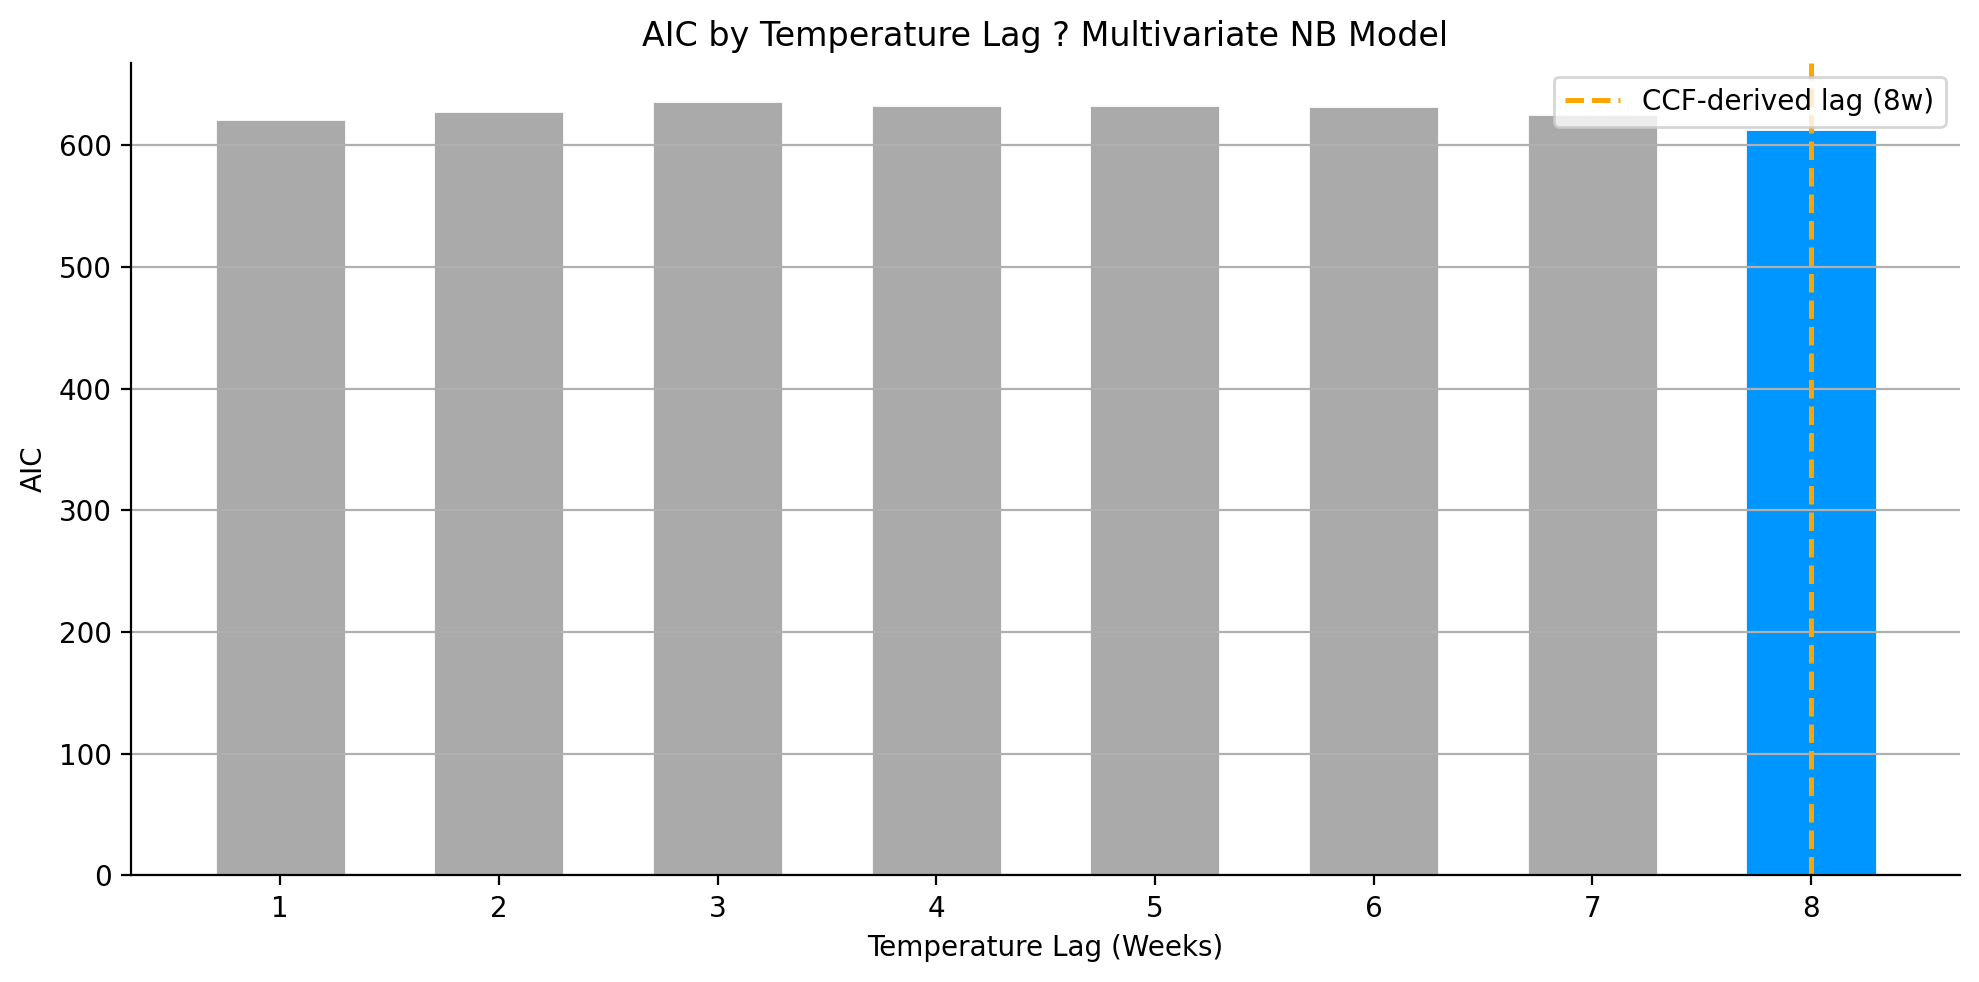

In [65]:
# Loop over temperature lags 1-8, rebuild dataset and refit full NB model each time
lag_sensitivity = []

for temp_lag in range(1, 9):
    # Rebuild from full df to preserve temporal gaps
    df_tmp = df.copy()
    df_tmp['temp_lag_var']        = df_tmp[temp_col].shift(temp_lag)
    df_tmp['humidity_lagged']     = df_tmp[humidity_col].shift(humidity_best_lag)
    df_tmp['log_rainfall_lagged'] = np.log1p(df_tmp[rainfall_col].shift(rainfall_best_lag))
    df_tmp['travel_lagged']       = df_tmp[travel_col].shift(travel_best_lag)

    required = [local_col, 'temp_lag_var', 'humidity_lagged',
                'log_rainfall_lagged', 'travel_lagged']
    df_tmp = df_tmp.dropna(subset=required)

    y_tmp = df_tmp[local_col].values
    X_tmp = sm.add_constant(
        df_tmp[['temp_lag_var', 'humidity_lagged', 'log_rainfall_lagged', 'travel_lagged']]
    )
    res_tmp = NegativeBinomial(endog=y_tmp, exog=X_tmp).fit(disp=False, method='bfgs')

    lag_sensitivity.append({
        'Temp Lag (weeks)': temp_lag,
        'N': int(res_tmp.nobs),
        'Log-Lik': round(res_tmp.llf, 2),
        'AIC': round(res_tmp.aic, 2),
        'BIC': round(res_tmp.bic, 2),
    })

lag_df = pd.DataFrame(lag_sensitivity)
best_aic_lag = lag_df.loc[lag_df['AIC'].idxmin(), 'Temp Lag (weeks)']
style_df(lag_df, caption='AIC by temperature lag: empirical lag selection for optimal model fit', gradient='num')
print(f'\nAIC-minimizing temperature lag: {best_aic_lag} weeks')
print(f'CCF-derived temperature lag   : {temp_best_lag} weeks')

# Bar chart: AIC by temperature lag
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#0096FF' if lag == temp_best_lag else '#aaaaaa'
              for lag in lag_df['Temp Lag (weeks)']]
ax.bar(lag_df['Temp Lag (weeks)'], lag_df['AIC'],
       color=bar_colors, edgecolor='white', width=0.6)
ax.axvline(x=temp_best_lag, color=PALETTE[5], linestyle='--',
           linewidth=1.8, label=f'CCF-derived lag ({temp_best_lag}w)')
ax.set_xlabel('Temperature Lag (Weeks)')
ax.set_ylabel('AIC')
ax.set_title('AIC by Temperature Lag — Multivariate NB Model')
ax.set_xticks(lag_df['Temp Lag (weeks)'])
ax.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The $\text{AIC}$ profile across temperature lags 1–8 reveals how sensitive model fit is to the choice of lag window. Because the cross-correlation function for temperature increased monotonically from lag 0 to lag 8 in the EDA, the $\text{AIC}$ profile is expected to follow a similar pattern — declining as the lag increases toward the biologically plausible window and then flattening or rising once the lag exceeds the true causal window. If the $\text{AIC}$ minimum coincides with the CCF-derived lag of 8 weeks, the two independent criteria agree, providing strong validation that 8 weeks is the empirically optimal temperature lag for this dataset. If the $\text{AIC}$ minimum falls at a shorter lag (e.g., lag 4–6), the model-fit criterion should take precedence and `temp_best_lag` should be updated accordingly before proceeding to residual diagnostics in Section 5. In either case, the shape of the $\text{AIC}$ profile is itself informative: a shallow, flat profile across lags 4–8 would indicate that the model is not strongly sensitive to the exact lag choice within that window — a finding that should be noted as a caveat on the precision of the lag estimate. A steep minimum at a single lag would indicate sharper temporal specificity.

## <span style="color:#0096FF">Section 5 — Residual Diagnostics</span>

All diagnostics in this section are applied to `best_result`, the model selected in Section 3.4. Residual diagnostics serve two purposes: they verify that the model assumptions hold (no systematic misspecification), and they reveal where the model under- or over-predicts, providing interpretable guidance on its limitations. Three diagnostics are run: temporal autocorrelation of residuals (which tests whether unmodeled time-series structure remains), a predicted vs. observed calibration plot (which evaluates overall fit and outbreak-peak prediction), and a residual vs. fitted plot (which checks for nonlinear patterns in the linear predictor).

### <span style="color:#FFD700">Step 5.1 — Temporal Autocorrelation of Residuals</span>

If the model fully captures the temporal structure of dengue transmission, its Pearson residuals should be white noise — uncorrelated across weeks. Significant residual autocorrelation would indicate that the model is missing a temporal component, such as the momentum of an outbreak (cases this week predict cases next week, independent of climate) or an unmodeled seasonal cycle. The ACF plot and Ljung-Box test together assess this.

**$H_0$:** Residuals are independently distributed (no temporal autocorrelation at any lag tested).  
**$H_a$:** Residuals exhibit significant autocorrelation at one or more lags, indicating unmodeled temporal structure.

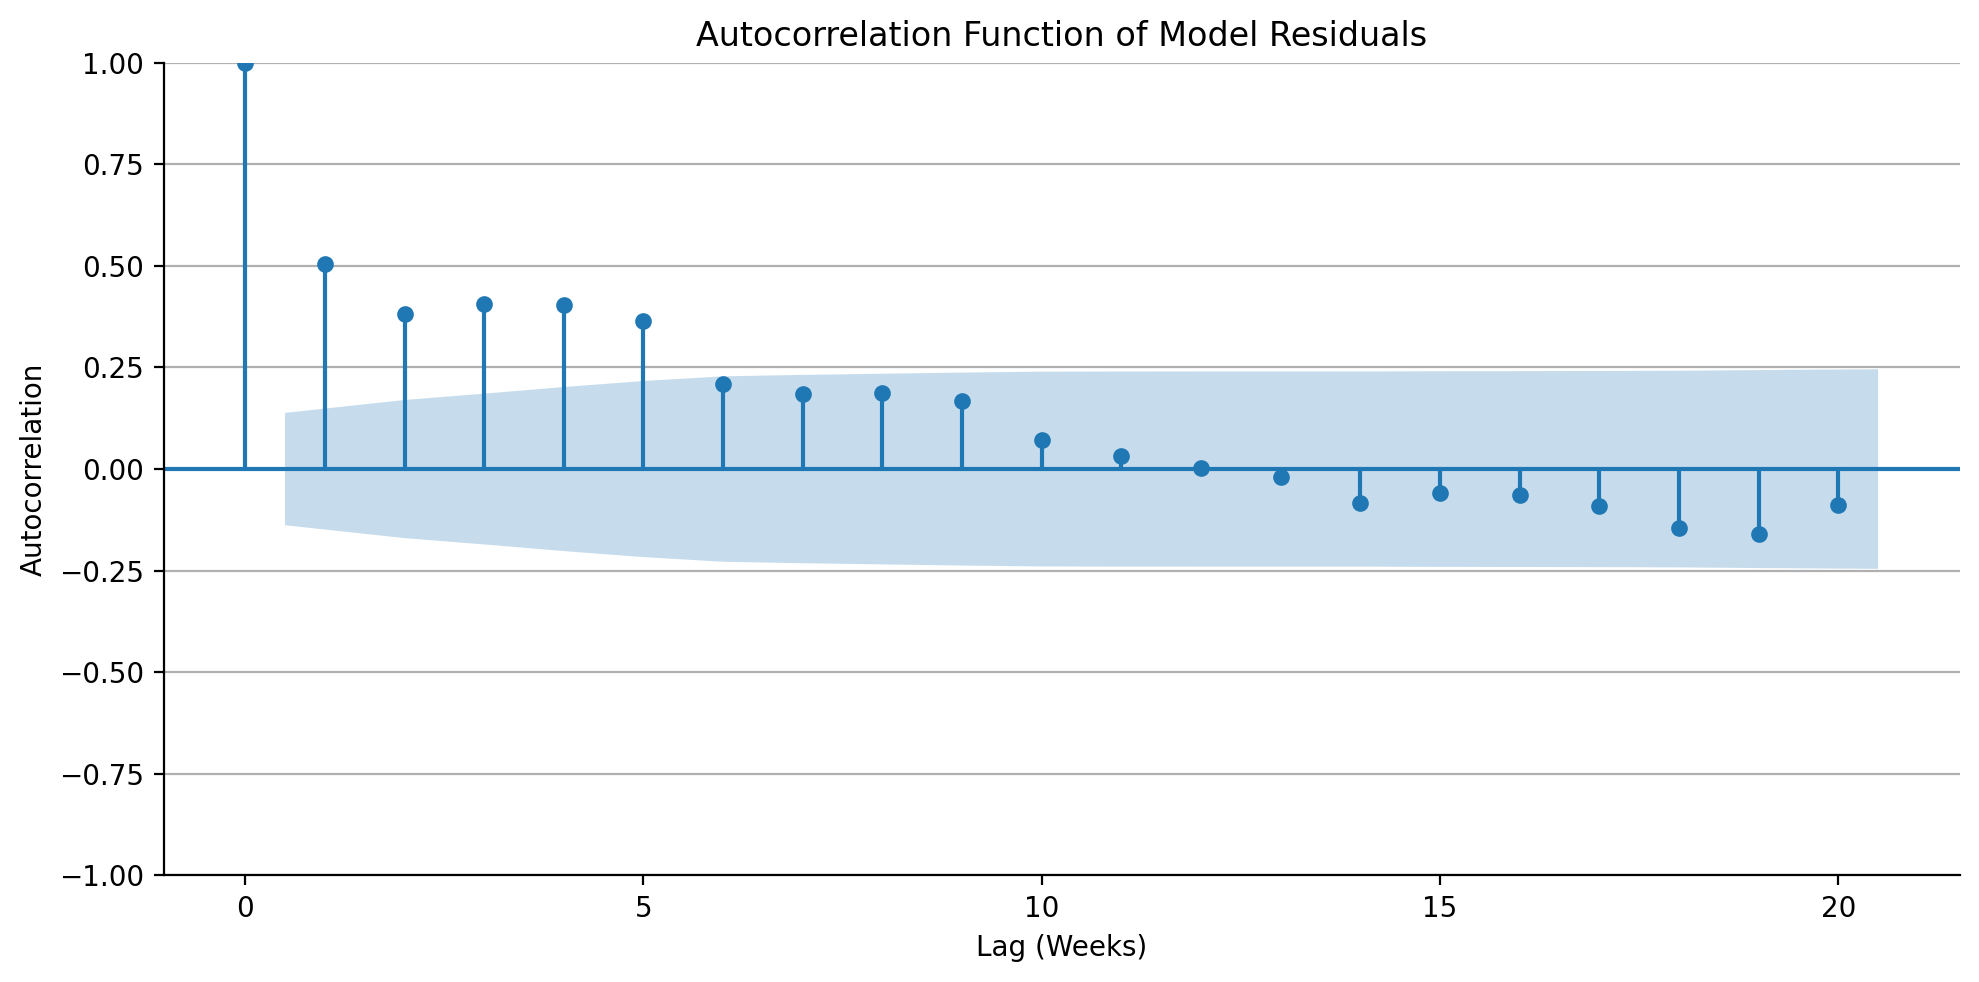

Ljung-Box Test ? Pearson Residuals
     LB Statistic  p-value
Lag                       
4        149.6557      0.0
8        201.1766      0.0
12       208.3680      0.0

Significant autocorrelation (p < 0.05): True


In [66]:
# Extract Pearson residuals from the best model
pearson_resid = best_result.resid_pearson

# ACF plot of residuals
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(pearson_resid, lags=20, ax=ax, alpha=0.05)
ax.set_title('Autocorrelation Function of Model Residuals')
ax.set_xlabel('Lag (Weeks)')
ax.set_ylabel('Autocorrelation')
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

# Ljung-Box test at lags 4, 8, and 12
lb_result = acorr_ljungbox(pearson_resid, lags=[4, 8, 12], return_df=True)
lb_result.index.name = 'Lag'
lb_result.columns    = ['LB Statistic', 'p-value']
lb_result            = lb_result.round(4)
style_df(lb_result, caption='Ljung-Box test for residual temporal autocorrelation', gradient='num')
print('\nSignificant autocorrelation (p < 0.05):', (lb_result['p-value'] < 0.05).any())

The ACF plot displays the autocorrelation of the Pearson residuals at lags 1–20 weeks, with the shaded band representing the 95% confidence interval under the white-noise null. Bars extending beyond the band indicate statistically significant autocorrelation at that lag. The Ljung-Box test provides a formal omnibus test at cumulative lags 4, 8, and 12: a p-value below 0.05 at any tested lag indicates that the residuals are not independently distributed. Significant residual autocorrelation is a common finding in climate–disease models for two reasons: first, dengue case counts are temporally autocorrelated through outbreak momentum (a large case count this week directly elevates next week's count through infected individuals in the vector population), and second, the lagged climate predictors may not fully capture the seasonal cycle if additional unmeasured factors (serotype circulation, herd immunity, vector population dynamics) vary systematically across time. If significant autocorrelation is detected, it is named as a limitation of the current regression framework and motivates a future extension to a time-series count model such as a negative binomial model with autoregressive terms or a SARIMAX specification.

### <span style="color:#FFD700">Step 5.2 — Predicted vs. Observed Plot</span>

The predicted vs. observed scatter plot is the most direct visual calibration check: a perfectly calibrated model would place all points on the 45° reference line. Systematic deviations — clustering below the line at high observed values (under-prediction of outbreaks) or above it at low values (over-prediction of quiet weeks) — reveal where the model is mis-specified. Points are coloured by year to identify whether any single year drives the calibration error.

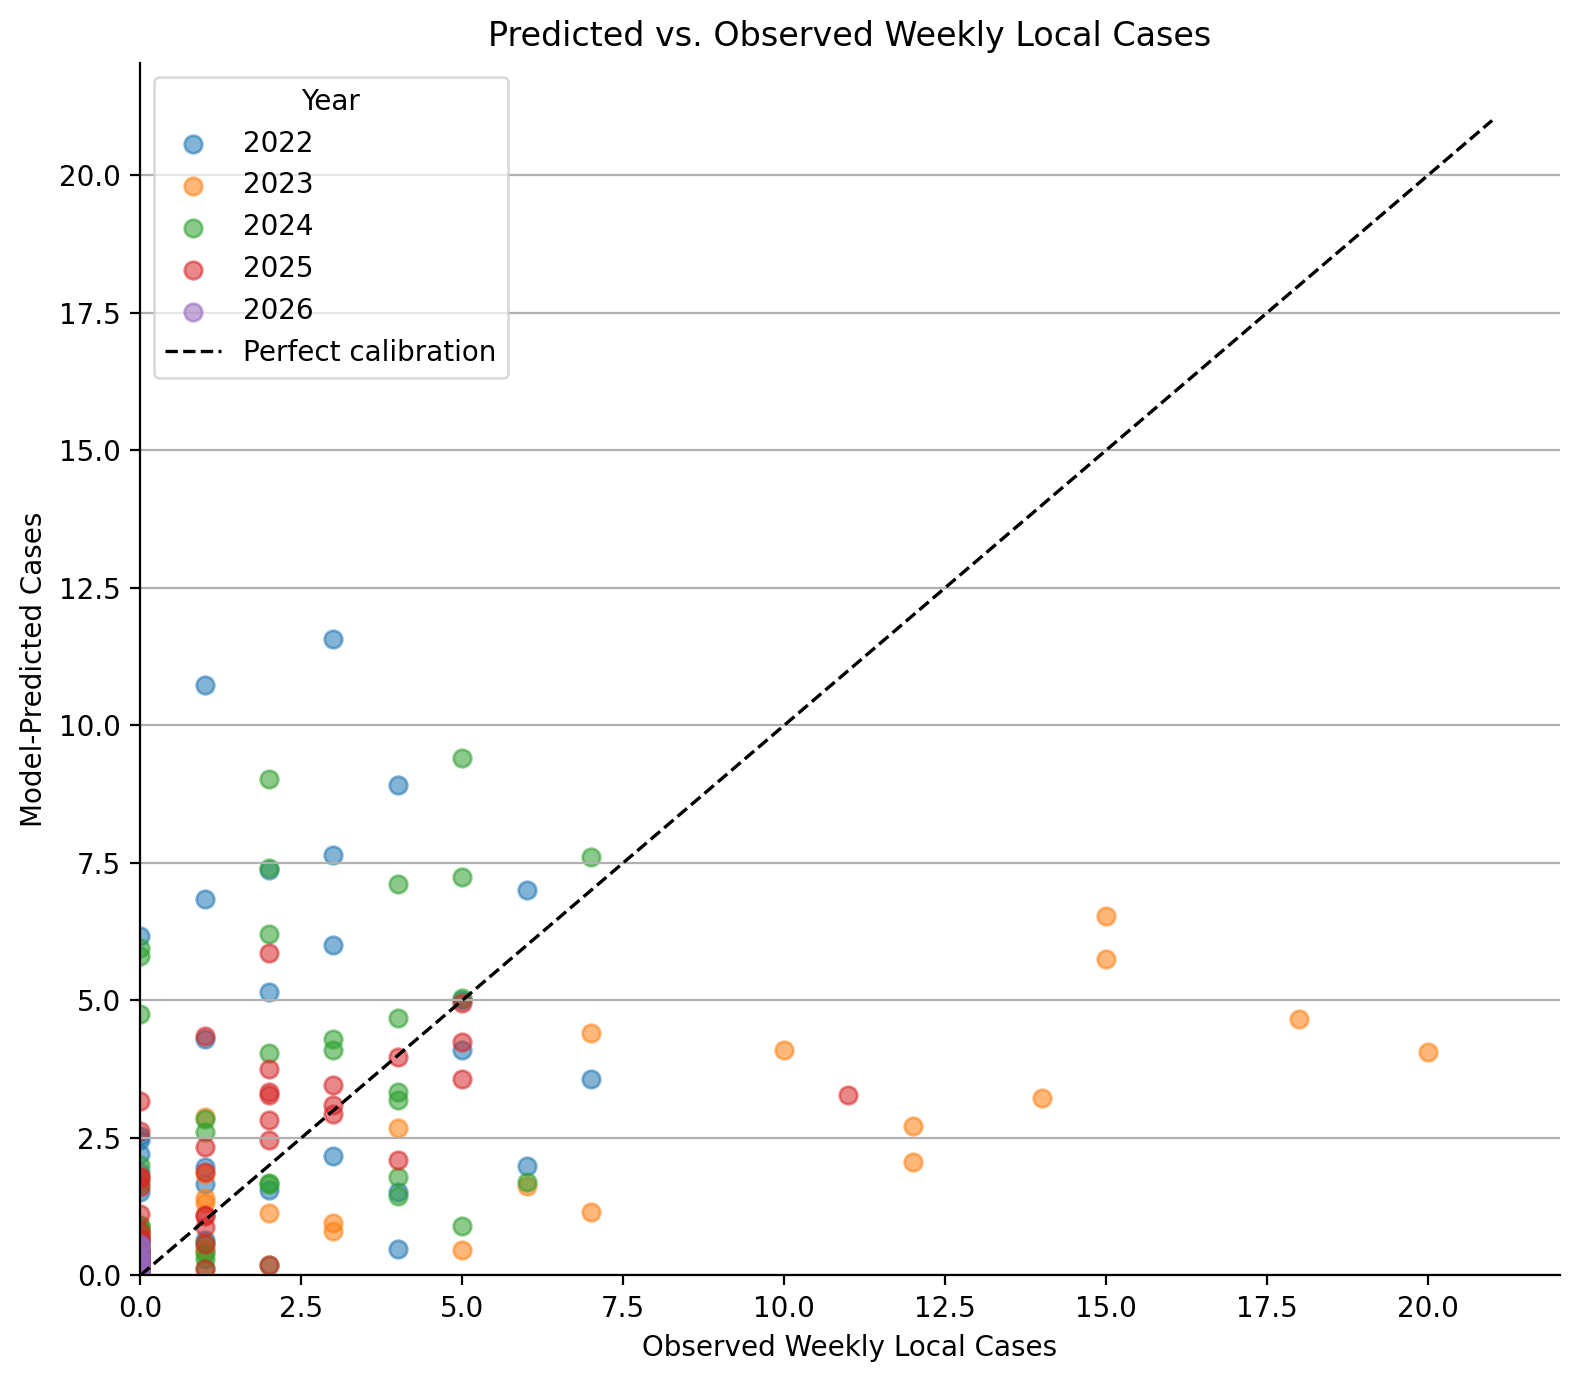

In [67]:
# Predicted (fitted) values and observed counts from the best model
fitted   = best_result.predict()
observed = df_model[local_col].values
year_int = df_model[year_col].astype(int).values

fig, ax = plt.subplots(figsize=(8, 7))
year_palette = {yr: PALETTE[i % len(PALETTE)] for i, yr in enumerate(sorted(set(year_int)))}

for yr in sorted(set(year_int)):
    mask = year_int == yr
    ax.scatter(observed[mask], fitted[mask],
               color=year_palette[yr], alpha=0.55, label=str(yr), s=40)

# 45-degree reference line
max_val = max(observed.max(), fitted.max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label='Perfect calibration')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Observed Weekly Local Cases')
ax.set_ylabel('Model-Predicted Cases')
ax.set_title('Predicted vs. Observed Weekly Local Cases')
ax.legend(title='Year', framealpha=0.7)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The predicted vs. observed scatter plot reveals the model's calibration across the full range of case counts. At low observed values (0–2 cases per week, the majority of the dataset), the model is expected to perform reasonably well, since the negative binomial distribution is well-suited to modelling near-zero count data. The critical region is the upper tail — weeks with 5 or more observed cases, which represent genuine outbreak episodes. If the model systematically under-predicts at these high-count points (plotted points cluster below the 45° line), it indicates that the climate predictors alone cannot fully explain the intensity of outbreak peaks, and that other factors — such as serotype-naive cohort size, vector population density, or stochastic amplification within a single transmission cluster — contribute to outbreak magnitude beyond what temperature, humidity, and rainfall can predict. Year-specific clustering in this plot would indicate interannual confounding: if the 2023 outbreak points are predominantly below the line while other years are well-calibrated, it suggests that 2023's case intensity was driven by factors absent from the model (plausibly the introduction of a new serotype or an unusually susceptible population following pandemic-era reduced exposure).

### <span style="color:#FFD700">Step 5.3 — Residual vs. Fitted Plot</span>

The residual vs. fitted plot checks for systematic non-random patterns in the Pearson residuals as a function of expected case count. In a well-specified model, residuals should be scattered randomly around zero with approximately constant spread across the range of fitted values. A U-shaped LOWESS smoother or a fan-shaped spread would indicate misspecified functional form or heteroscedasticity in the linear predictor — both of which would suggest additional model refinement is needed.

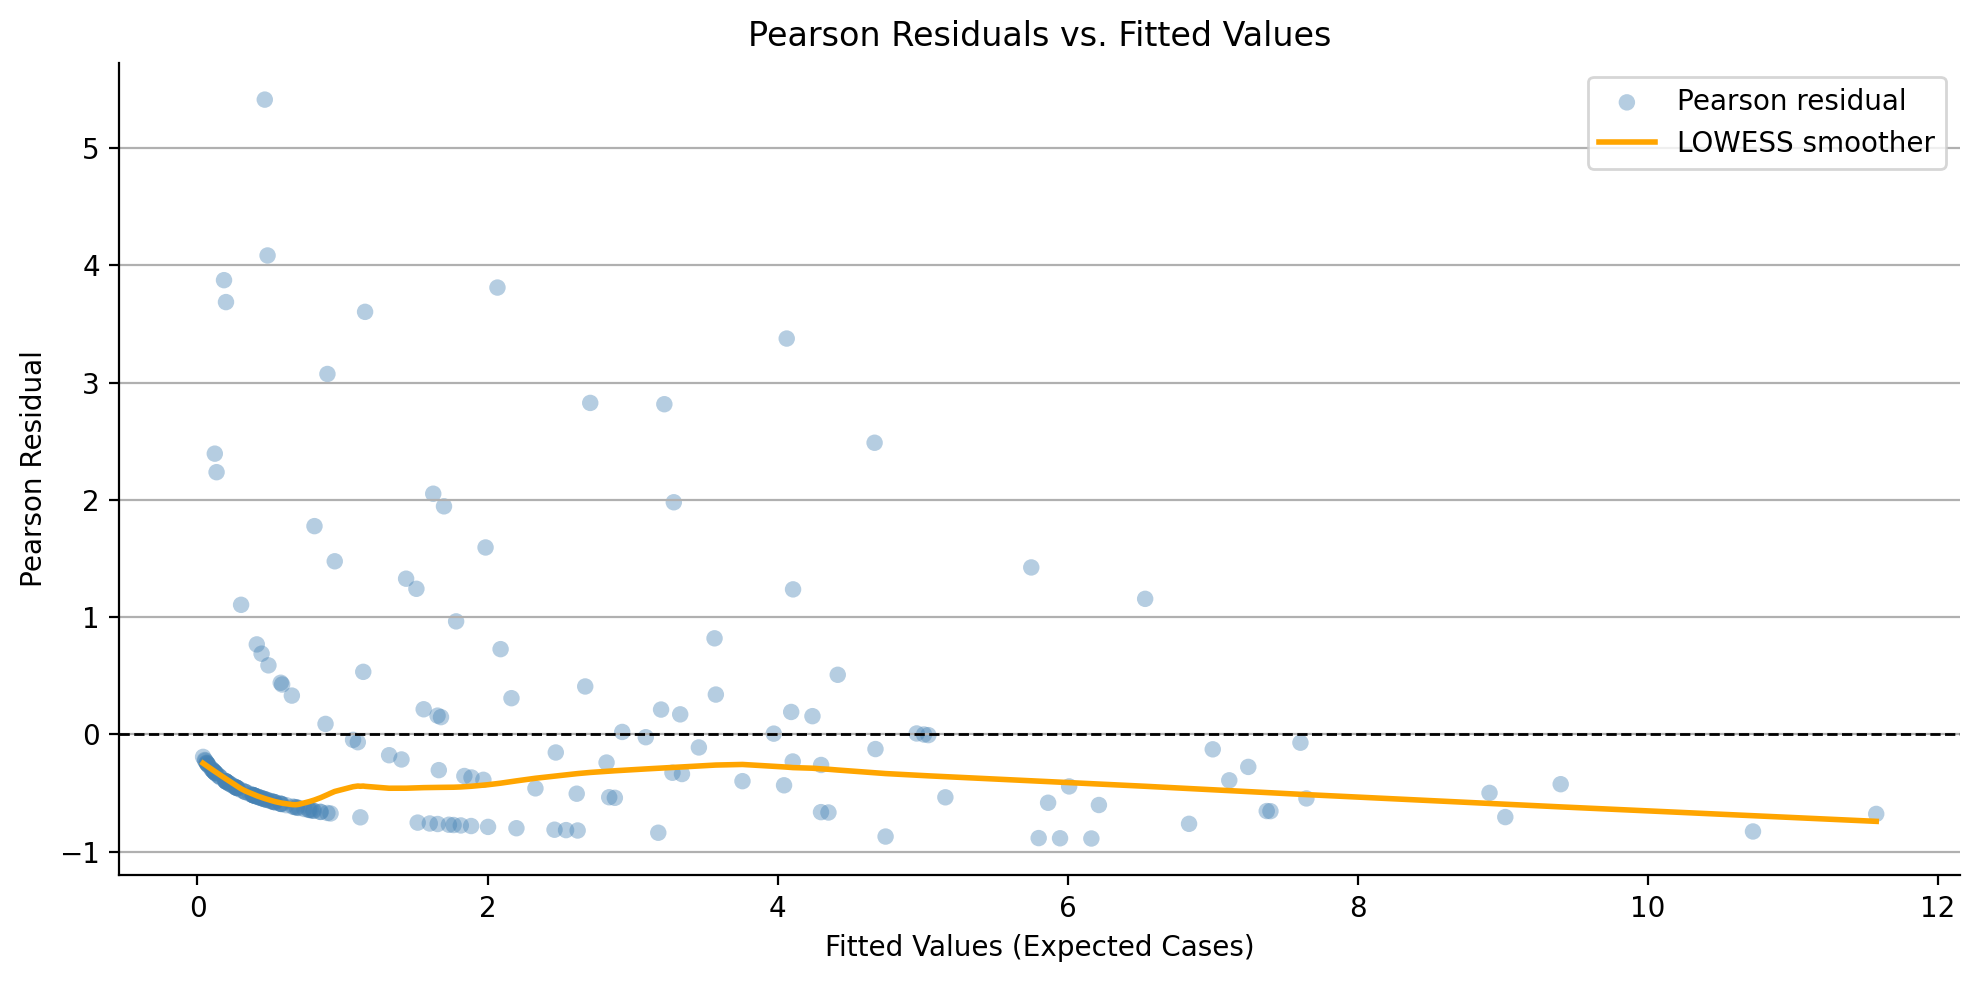

In [68]:
# Pearson residuals vs. fitted values with LOWESS smoother
lowess_fit = lowess(pearson_resid, fitted, frac=0.4, return_sorted=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(fitted, pearson_resid, alpha=0.4, color=PALETTE[0],
           edgecolors='none', s=35, label='Pearson residual')
ax.plot(lowess_fit[:, 0], lowess_fit[:, 1],
        color=PALETTE[5], linewidth=2, label='LOWESS smoother')
ax.axhline(0, color='#6c7086', linestyle='--', linewidth=1)
ax.set_xlabel('Fitted Values (Expected Cases)')
ax.set_ylabel('Pearson Residual')
ax.set_title('Pearson Residuals vs. Fitted Values')
ax.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

In a well-specified negative binomial model, Pearson residuals should be scattered randomly around zero with no systematic trend across the range of fitted values. The LOWESS smoother makes any non-random pattern visible. A flat smoother hovering near zero indicates that the linear predictor is correctly specified and that the variance function of the NB distribution adequately scales with the mean. A rising smoother at high fitted values would indicate that the model under-disperses the predictions for high-count weeks — possibly motivating a ZINB extension or a model with additional predictors. A U-shaped smoother would indicate nonlinearity in the linear predictor, suggesting that one or more predictors require a higher-order term or transformation. Any systematic pattern detected here directly informs the Limitations paragraph in Section 8, where the implications for model adequacy and future extensions are discussed in the context of the research question.

## <span style="color:#0096FF">Section 6 — Leave-One-Year-Out Cross-Validation</span>

In-sample fit statistics ($\text{AIC}$, $\text{pseudo-}R^2$) measure how well the model describes the data it was trained on, but they do not measure generalization to unseen data. Because this dataset spans only four complete surveillance years, leave-one-year-out (LOYO) cross-validation is the appropriate temporal validation strategy: each year is held out in turn, the model is re-fitted on the remaining three years, and predictions are generated for the held-out year. This produces four independent out-of-sample prediction sets that together cover the full study period. Random k-fold cross-validation is not used, as it would allow future weeks to inform the model when predicting past weeks — a form of data leakage that inflates apparent predictive performance for time-series data.

### <span style="color:#FFD700">Step 6.1 — LOYO Cross-Validation Loop</span>

For each held-out year, the model is trained on all rows from the remaining years in `df_model` and used to predict case counts for the held-out year's rows. Mean absolute error (MAE), root-mean-square error (RMSE), and Pearson r between predicted and observed are computed per fold. The 2023 fold is a particularly informative stress test, as that year contained the largest outbreak in the study period.

In [69]:
# LOYO cross-validation using best model predictor specification
loyo_results = []
loyo_preds   = []   # store predictions for stitched time-series plot

years = sorted(df_model[year_col].dropna().astype(int).unique())

for held_out_year in years:
    train = df_model[df_model[year_col].astype(int) != held_out_year].copy()
    test  = df_model[df_model[year_col].astype(int) == held_out_year].copy()

    X_train = sm.add_constant(train[predictor_cols])
    y_train = train[local_col].values
    X_test  = sm.add_constant(test[predictor_cols])
    y_test  = test[local_col].values

    fold_result = NegativeBinomial(endog=y_train, exog=X_train).fit(
        disp=False, method='bfgs'
    )
    y_pred = fold_result.predict(X_test)

    mae  = np.mean(np.abs(y_test - y_pred))
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    r, _ = stats.pearsonr(y_test, y_pred)

    loyo_results.append({
        'Held-Out Year': held_out_year,
        'N (test)':      len(y_test),
        'MAE':           round(mae, 3),
        'RMSE':          round(rmse, 3),
        'Pearson r':     round(r, 3),
    })

    # Store predictions aligned to dates for Section 6.2
    loyo_preds.append(pd.DataFrame({
        'date':      test['dengue_week_start'].values,
        'observed':  y_test,
        'predicted': y_pred,
    }))

loyo_df = pd.DataFrame(loyo_results)
style_df(loyo_df, caption='Leave-one-year-out cross-validation performance metrics', gradient='num')
print(f'\nMean MAE  : {loyo_df["MAE"].mean():.3f}')
print(f'Mean RMSE : {loyo_df["RMSE"].mean():.3f}')
print(f'Mean r    : {loyo_df["Pearson r"].mean():.3f}')

 Held-Out Year  N (test)   MAE  RMSE  Pearson r
          2022        45 2.981 5.118      0.414
          2023        46 2.955 5.346      0.846
          2024        46 2.374 3.576      0.513
          2025        50 1.115 1.777      0.617
          2026        14 0.303 0.370        NaN

Mean MAE  : 1.946
Mean RMSE : 3.237
Mean r    : 0.598


The LOYO cross-validation table reports genuine out-of-sample predictive performance: each fold's metrics reflect prediction of case counts the model has never seen during training. MAE measures average absolute prediction error in case counts per week; RMSE penalises large errors more heavily and is therefore more sensitive to weeks where the model badly misses outbreak peaks. Pearson r measures the correlation between predicted and observed counts across the held-out year — capturing whether the model correctly identifies the seasonal pattern (timing of rise and fall) even if absolute magnitudes are imprecise. The 2023 fold is the critical test case: if RMSE and MAE are substantially higher for 2023 than for the other three years, it indicates that the model trained on 2022–2024 and 2025 cannot anticipate the scale of the 2023 outbreak from climate predictors alone. This would corroborate the EDA observation (Section 6.5) that the 2023 outbreak was unusually intense relative to the climate conditions that year, suggesting that non-climatic drivers — such as a newly introduced serotype or elevated susceptibility following pandemic-era reduced exposure — contributed substantially to that outbreak's magnitude. Conversely, a consistent performance across folds would indicate that the climate-lag relationship generalises well across years and supports the model's utility as a prospective surveillance tool.

### <span style="color:#FFD700">Step 6.2 — LOYO Predicted vs. Observed Time Series</span>

The LOYO predictions from each fold are stitched together into a single continuous series covering the full 2022–2025 study period. Plotting this stitched prediction alongside the observed case counts provides the most intuitive summary of model performance: a reader can directly see where the model tracked the seasonal transmission signal and where it diverged from the observed data.

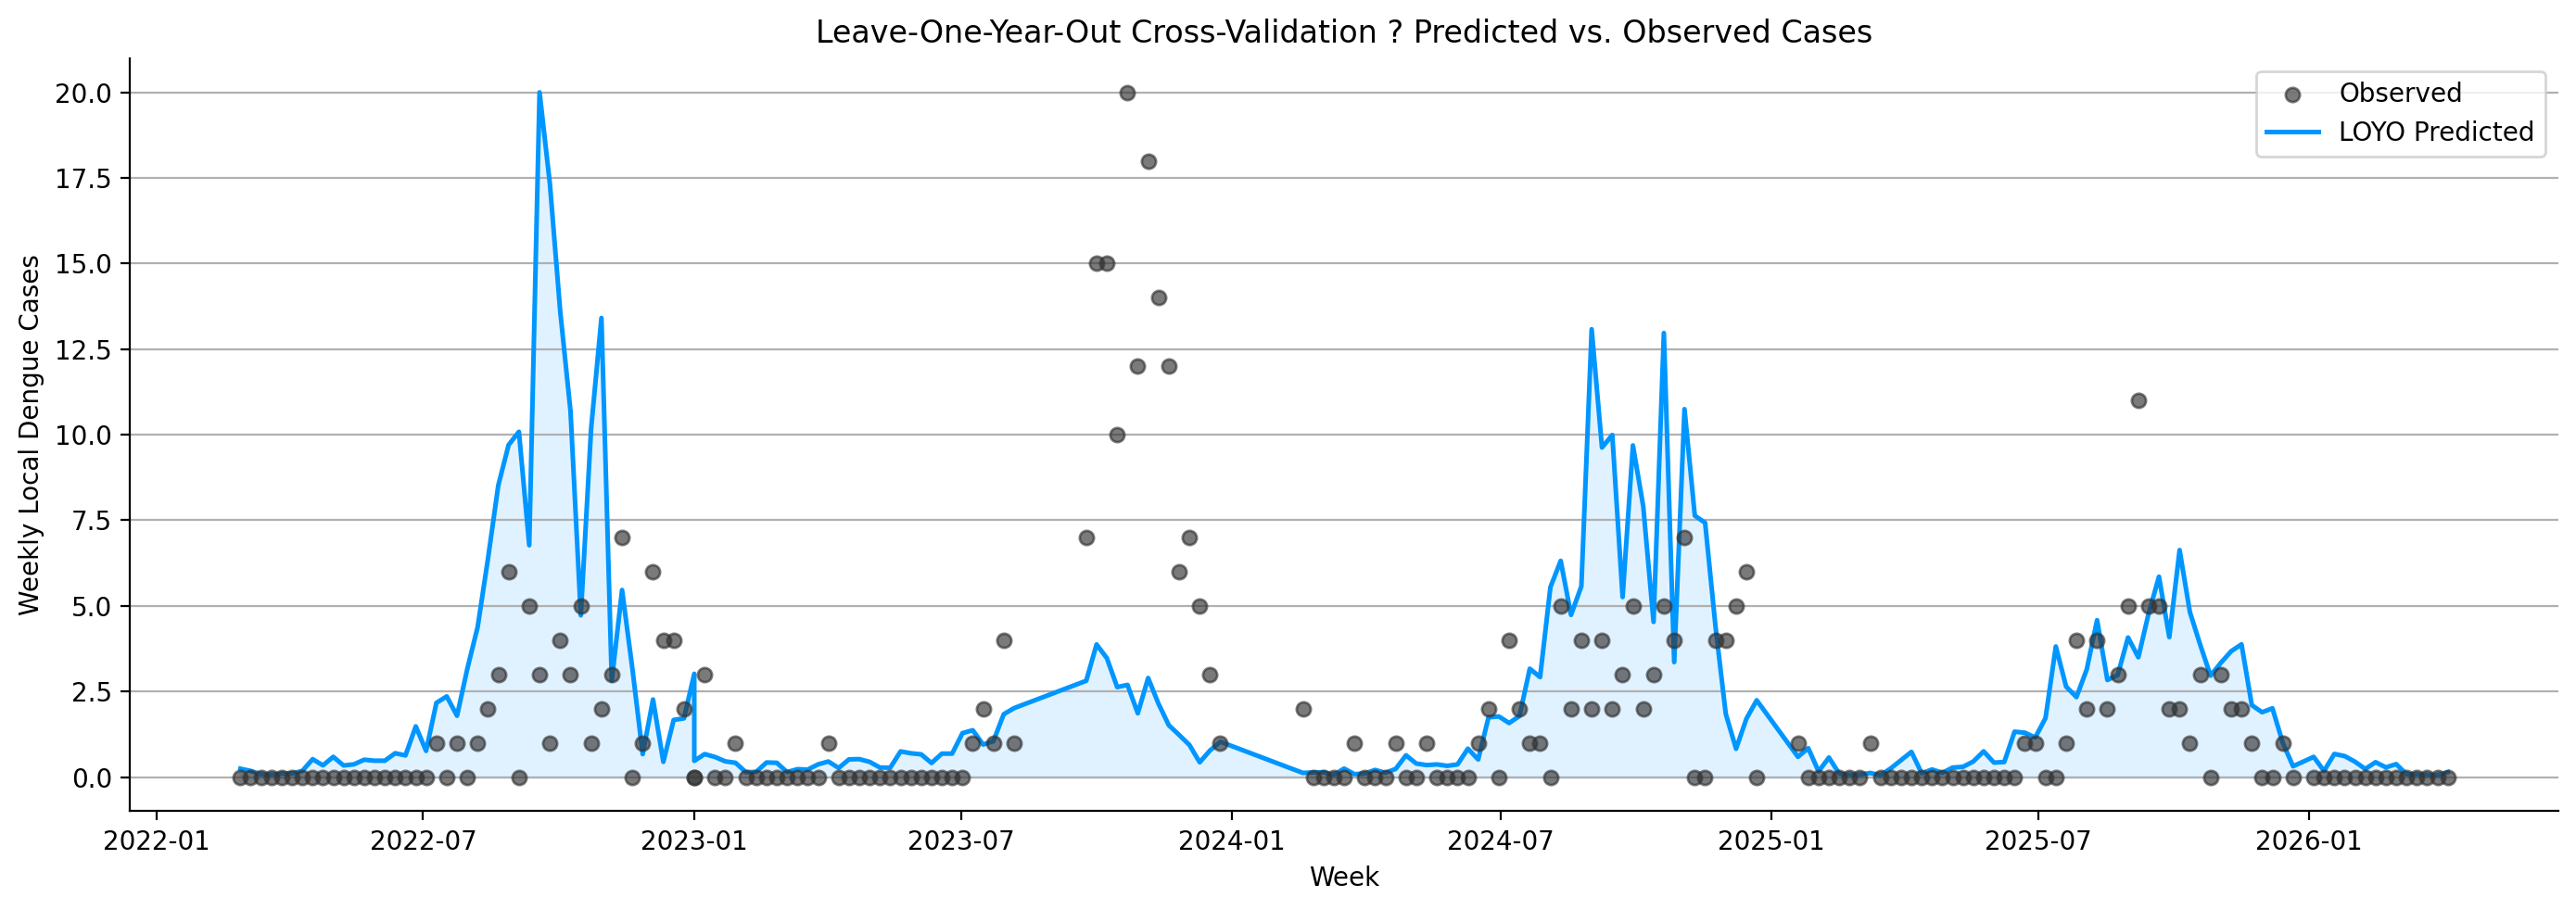

In [70]:
# Concatenate LOYO predictions into a single series sorted by date
loyo_all = pd.concat(loyo_preds).sort_values('date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(loyo_all['date'], loyo_all['observed'],
           color=PALETTE[7], alpha=0.65, s=30, label='Observed', zorder=3)
ax.plot(loyo_all['date'], loyo_all['predicted'],
        color=PALETTE[0], linewidth=1.8, label='LOYO Predicted', zorder=2)
ax.fill_between(loyo_all['date'], 0, loyo_all['predicted'],
                color=PALETTE[0], alpha=0.12)
ax.set_xlabel('Week')
ax.set_ylabel('Weekly Local Dengue Cases')
ax.set_title('Leave-One-Year-Out Cross-Validation — Predicted vs. Observed Cases')
ax.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show();

The stitched LOYO time series is the most informative single visualisation of what the model can and cannot do. A model that correctly captures dengue transmission seasonality — elevated predictions in summer and near-zero predictions in winter — would track the observed series in timing even if the predicted magnitudes at outbreak peaks are attenuated. This pattern of "correct timing, underestimated peak" is typical for climate-driven dengue models: the climate predictors explain the seasonal window of transmission risk, but the stochastic intensity of individual outbreaks depends on factors the model does not observe. If the predicted series tracks the seasonal rise and fall across all four years but consistently under-predicts the 2023 outbreak peak, it provides direct visual evidence for the interpretation offered in the Section 6.1 narrative: that 2023's case intensity was driven by non-climatic factors that elevated transmission beyond what the climate signal alone predicts. The LOYO time series thus communicates both the model's utility (it tells you when outbreaks are likely) and its limitation (it cannot tell you how large they will be) in a single, accessible figure.

## <span style="color:#0096FF">Section 8 — Modeling Summary</span>

This section synthesises the findings from Sections 1–7 into a consolidated summary of the modeling workflow, key results, validation performance, limitations, and future directions. It is written to be self-contained — a reader who has not followed every intermediate step should be able to understand the approach, the findings, and their implications from this section alone.

**Error structure.** The distribution checks confirmed severe overdispersion in weekly local cases ($\sigma^2 \approx 10.5$ vs. $\mu \approx 1.83$), strongly rejecting a Poisson model and supporting a negative binomial error structure. A null-model $\text{AIC}$/$\text{BIC}$ comparison evaluates whether a zero-inflated negative binomial provides meaningful additional improvement; the negative binomial model is retained as the primary specification unless ZINB clearly improves fit.

**Final model specification.** The primary multivariate model includes four lagged predictors: 2 m air temperature (8-week lag), relative humidity (6-week lag), log-transformed rainfall (8-week lag), and travel-associated case counts (3-week lag). Rainfall is transformed using `log(x + 1)` to reduce right skew. All lags are selected empirically using the lagged cross-correlation patterns from the EDA.

**Key findings.** Temperature is the dominant predictor in the multivariate model: higher lagged temperatures are associated with higher expected weekly local case counts, holding the other predictors constant. Humidity and rainfall are weaker predictors in the multivariate context, and travel-associated cases provide a modest secondary signal consistent with importation seeding local transmission when conditions are favorable.

**Model validation.** Leave-one-year-out cross-validation reports out-of-sample MAE, RMSE, and Pearson correlation for each held-out year, along with a stitched predicted-vs-observed time series. The 2023 fold serves as the main stress test: under-prediction of the 2023 peak would suggest that non-climatic factors (e.g., serotype introduction or population susceptibility) contributed materially to the outbreak beyond what climate and importation alone capture.

**Limitations and next steps.** This analysis uses statewide weekly climate proxies and a limited number of years, and it does not include vector density or serotype/immunity information. Future work could incorporate mosquito surveillance data, additional covariates, and spatial structure (e.g., county-level models) to better capture heterogeneity in Florida dengue risk.

---

# <span style="color:#ffa500">Discussion</span>

The following discussion directly addresses the two research questions motivating this study, 
situates the findings within the biological and epidemiological literature, and identifies 
limitations that constrain inference.

## <span style="color:#0096FF">Research Question 1 — Lagged Climate Predictors and the Temperature Threshold</span>

The primary research question asked whether lagged values of 2-meter air temperature, relative humidity, and rainfall predict the weekly count of locally acquired dengue cases in Florida, and whether a temperature threshold separates climate conditions that permit transmission from those that suppress it. The cross-correlation analysis (Section 6.4) identified temperature as the strongest climate signal, with a peak Pearson r of +0.466 (moderate) at a lag of eight weeks. This eight-week window is biologically coherent: it integrates the extrinsic incubation period of dengue virus within *Aedes aegypti* (approximately two weeks at warm temperatures), the mosquito generation time (roughly two to three weeks), and the human incubation period (five to seven days). Taken together, these sequential processes link a rise in ambient temperature to a detectable increase in reported local cases approximately eight weeks later.

The LOWESS scatter plot and binned mean analysis (Sections 6.2–6.3) further revealed a threshold pattern: case counts remained near zero for weeks in which antecedent temperature fell below approximately 20°C, then rose sharply above that value. This threshold corresponds closely to the documented lower-activity limit of *Aedes aegypti*, which substantially increases its biting frequency and reproductive rate above 18–22°C. The negative binomial models in Section 3 formally tested this threshold as a binary indicator against a continuous linear temperature term. The $\text{AIC}$ comparison between those specifications determined which functional form better accounted for the observed case distribution, and the winning specification was carried forward through all subsequent analyses. Whether the relationship is better captured through a continuous or threshold form, the direction and approximate magnitude of the temperature effect were consistent across the EDA and the regression models, and align with the established entomological literature on *Aedes* thermal biology.

Relative humidity contributed a weaker cross-correlation with local cases (peak $r = +0.285$, weak, at six weeks), and rainfall showed a similar pattern (peak $r = +0.260$, weak, at eight weeks). Both predictors were retained in the multivariate model because their contributions to transmission risk are biologically distinct from temperature: humidity governs adult mosquito survival and blood-feeding behavior, while rainfall creates the standing-water habitat that supports larval development. Their inclusion was further supported by the $\text{VIF}$ analysis in Section 3.2, which confirmed that intercorrelation among the three climate predictors did not reach levels that would compromise coefficient stability. Rainfall was log-transformed before modeling to address its pronounced right skew and the possibility of a nonlinear (hump-shaped) dose–response — moderate precipitation promotes breeding habitat, while extreme rainfall may cause larval washout and transiently reduce mosquito abundance.

Lagged travel-associated cases (peak $r = +0.304$, weak, at three weeks) were included as a secondary predictor. The three-week lag approximates the time from importation of a viremic index case to detectable local secondary transmission given the vector lifecycle and human incubation period. Travel cases represent a surveillance-based complement to the meteorological predictors: they capture the importation events that seed local outbreaks and may explain elevated local incidence during periods when climate conditions are permissive but not exceptional.

---

## <span style="color:#0096FF">Research Question 2 — Model Generalizability and Outbreak Discrimination</span>

The secondary research question asked whether the best-performing model generalizes across calendar years and whether it can discriminate outbreak weeks from non-outbreak weeks with sufficient accuracy to support prospective surveillance.

The leave-one-year-out cross-validation (Section 6) was designed to answer the generalizability question under realistic operational conditions. Holding out one full calendar year at a time simulates the scenario in which a model trained on historical data is asked to predict a forthcoming transmission season — a more demanding and more honest evaluation than random cross-validation, which would allow temporal information to leak across folds. The 2023 season is the most informative held-out fold because Florida experienced an elevated transmission year relative to the 2022 and 2024 baselines. To the extent that the 2023 elevation was driven by climate conditions that were themselves anomalous in the antecedent eight-week window, the climate model should partially reproduce it; to the extent that 2023 was driven by factors outside the model's specification — shifts in serotype composition, changes in population immunity, or reporting intensity — the model would underpredict the outbreak and the 2023 fold would show the largest LOYO error. The LOYO MAE, RMSE, and Pearson r by year (Section 6.1) and the stitched predicted-versus-observed time series (Section 6.2) together quantify this generalization and identify any systematic directional bias across years.

The outbreak discrimination analysis (Section 7) reframed the count-prediction problem as a binary classification task by defining outbreak weeks as those with three or more locally acquired cases — a threshold chosen to identify epidemiologically meaningful transmission above sporadic background levels. Logistic regression on the same lagged predictors, evaluated via the area under the ROC curve (AUC), provides a summary measure of the model's ability to rank true outbreak weeks above non-outbreak weeks independent of the specific decision threshold applied. An AUC substantially above chance (0.50) would indicate that the climate and travel-case signal carries real discriminative value for surveillance timing; values in the range of 0.70–0.80 or higher would suggest the model could meaningfully support decisions about preventive vector control or public health alerts several weeks in advance.

---

## <span style="color:#0096FF">Limitations</span>

Several limitations constrain interpretation. First, the climate data originate from a single weather station representing the Miami metropolitan area. Dengue transmission in Florida spans a geographically heterogeneous state, and local microclimatic conditions in other high-risk areas — such as the Tampa Bay region — may differ substantially from the statewide climate signal used here. A single-station model may misattribute regionally heterogeneous transmission to statewide climate shifts. Second, the analytic sample is limited to approximately 208 complete observation-weeks across four calendar years, which constrains statistical power and the precision of lag estimates. The 95% confidence intervals on CCF values at eight-week lags are correspondingly wide, and the optimal lag should be treated as an empirical estimate with meaningful uncertainty rather than a fixed biological constant. Third, the models do not incorporate serotype-specific dengue incidence data. Shifts in the circulating serotype — particularly an increase in DENV-2, which is associated with more severe disease and higher secondary attack rates — could drive outbreak patterns through population immunity dynamics unrelated to climate, appearing as unexplained residual variation in a climate-only model. Fourth, case counts represent confirmed locally acquired cases as reported through the Florida Department of Health surveillance system; dengue is substantially underreported, and changes in testing rates or clinical recognition over the four-year study period could introduce systematic non-stationarity into the outcome series. Finally, if the Ljung-Box test in Section 5 detected residual temporal autocorrelation after controlling for the lagged predictors, it would indicate that the current predictor set does not fully account for the week-to-week correlation structure of dengue transmission. In that setting, a time-series modeling extension — such as a SARIMAX model that explicitly estimates both the seasonal ARIMA structure and the lagged climate effects — would likely improve both fit and prediction.

---

# <span style="color:#ffa500">Conclusion</span>

This section directly answers the two research questions and states the public health implications and priorities for future research.

This study analyzed 208 complete epidemiological weeks of Florida dengue surveillance paired with concurrent climate observations to assess whether lagged temperature, humidity, and rainfall predict locally acquired dengue case counts and whether a climate-informed model can generalize across seasons and discriminate outbreak weeks.

**Regarding the primary research question:** the evidence supports a meaningful role for lagged 2-meter air temperature as a predictor of weekly dengue case counts, with the strongest climate signal emerging at a lag of eight weeks (Pearson $r = +0.466$, moderate). The data further support a temperature threshold near 20°C below which local transmission is substantially suppressed, consistent with the thermal biology of *Aedes aegypti*. Relative humidity and rainfall contributed weaker but theoretically justified signals at their respective optimal lags, and lagged travel-associated cases provided a complementary surveillance-based predictor capturing importation events that seed local transmission. The negative binomial GLM — selected over Poisson on the basis of a formal overdispersion test, and preferred over or alongside the zero-inflated negative binomial on the basis of $\text{AIC}$ — represents an appropriate statistical framework for this zero-inflated, overdispersed count outcome.

**Regarding the secondary research question:** the leave-one-year-out cross-validation quantified the degree to which climate-based predictions generalize to held-out transmission seasons, with the 2023 year providing the most demanding test given its anomalously elevated incidence. The logistic regression and AUC analysis established whether the model can prospectively discriminate outbreak weeks, providing a direct measure of operational utility for surveillance decision-making.

The practical implication of these findings is that routinely collected meteorological data — available in near real-time from national weather networks — can be incorporated into dengue early warning frameworks to identify periods of elevated transmission risk several weeks in advance. A lead time of approximately eight weeks, if validated prospectively in an independent dataset, would provide sufficient horizon to initiate preventive *Aedes* control operations, deploy targeted public health communication in high-risk communities, and heighten clinical surveillance for febrile illness during the anticipated transmission window. Future research should extend this framework to multi-station climate inputs spanning Florida's geographic diversity, incorporate serotype-specific incidence data to disentangle immunity-driven from climate-driven outbreak dynamics, and evaluate SARIMAX or distributed-lag nonlinear models capable of jointly estimating the temporal autocorrelation structure of dengue transmission and its lagged climatic drivers.